# Milestone 2: Insurance Price Prediction
## Modeling, Evaluation, Explainability, and Deployment

In [1]:
from IPython.display import HTML, display

display(HTML("""
<style>
  body, .jp-Notebook {
    background: #F7F9FC;
    color: #17202A;
    font-family: Arial, sans-serif;
  }
  .jp-Notebook h1 {
    color: #123B5D;
    border-bottom: 3px solid #E67E22;
    padding-bottom: 8px;
  }
  .jp-Notebook h2 {
    color: #135D66;
    border-bottom: 1px solid #C7D8E4;
    padding-bottom: 5px;
  }
  .jp-Notebook h3 { color: #8A3B12; }
  .insight-card {
    background: #FFFFFF;
    border-left: 5px solid #148F77;
    border-radius: 6px;
    box-shadow: 0 2px 8px rgba(23, 32, 42, 0.08);
    margin: 12px 0 20px 0;
    padding: 12px 16px;
  }
  .insight-row {
    display: grid;
    grid-template-columns: 185px 1fr;
    gap: 12px;
    margin: 7px 0;
    line-height: 1.45;
  }
  .insight-label { font-weight: 700; }
  .tech { color: #0B5D6B; }
  .business { color: #A3450A; }
  .jp-OutputArea-output,
  .output_html {
    box-sizing: border-box;
    max-width: 100%;
    overflow-x: auto;
  }
  table.dataframe {
    border-collapse: collapse;
    font-size: 11.5px;
    line-height: 1.35;
    min-width: 760px;
    table-layout: fixed;
    width: 100%;
  }
  table.dataframe th {
    background: #123B5D;
    color: white;
    padding: 7px;
    text-align: left;
    vertical-align: top;
    white-space: normal;
    overflow-wrap: anywhere;
  }
  table.dataframe td {
    border: 1px solid #D5DEE5;
    padding: 6px;
    text-align: left;
    vertical-align: top;
    white-space: normal;
    overflow-wrap: anywhere;
    word-break: normal;
  }
  table.dataframe thead th:first-child,
  table.dataframe tbody th:first-child {
    box-sizing: border-box;
    min-width: 46px !important;
    max-width: 46px !important;
    width: 46px !important;
    text-align: right;
  }
  table.dataframe thead th:nth-child(2),
  table.dataframe tbody td:first-child {
    width: 22%;
  }
  table.dataframe:has(thead th:nth-child(10)) {
    min-width: 1600px;
    table-layout: auto;
  }
  table.dataframe:has(thead th:nth-child(15)) {
    min-width: 2200px;
  }
  table.dataframe:has(thead th:nth-child(10)) thead th:nth-child(2),
  table.dataframe:has(thead th:nth-child(10)) tbody td:first-child {
    width: auto;
  }
  table.dataframe tr:nth-child(even) { background: #F1F5F8; }
  @media (max-width: 900px) {
    .insight-row {
      grid-template-columns: 1fr;
      gap: 3px;
    }
    table.dataframe {
      font-size: 11px;
      min-width: 720px;
    }
  }
  code { color: #7B2D26; }
</style>
"""))

## 1. Business Objective and Modeling Scope

The objective is to estimate `insurance_cost` from applicant health, lifestyle,
demographic, medical-history, and insurance-history attributes. Milestone 2:

1. establishes baseline and linear reference models;
2. compares nonlinear and advanced boosting models;
3. tunes the strongest model family using training-only cross-validation;
4. selects a final model using repeated target-band-stratified validation;
5. evaluates continuous cost and valid quote-band outputs;
6. checks residual behavior and segment-level error;
7. explains model behavior using permutation importance and SHAP; and
8. saves a portable model, deployment schema, Streamlit app, and QA evidence.

The test set is held out until model evaluation. Model selection is based on
cross-validation rather than on choosing the lowest test error.

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The task is supervised regression with a discrete 54-level target grid. The notebook keeps regression as the primary formulation and evaluates quote-band rounding as a deployment layer.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The output supports pricing review. It is not an automatic underwriting or eligibility decision.</span>
  </div>
</div>

## 2. Imports, Runtime Check, and Output Paths

In [2]:
from __future__ import annotations

import importlib
import json
import math
import os
import platform
import re
import shutil
import subprocess
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 180)

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

ROOT = Path.cwd()
if not (ROOT / "Insurance Data.csv").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(
        (path for path in candidates if (path / "Insurance Data.csv").exists()),
        ROOT,
    )
if not (ROOT / "Insurance Data.csv").exists():
    raise FileNotFoundError(
        "Insurance Data.csv was not found. Place the notebook under the project "
        "folder or run it with the project folder as the working directory."
    )

CLEAN_ROOM_MODE = os.environ.get("M2_CLEAN_ROOM", "0") == "1"
OUTPUTS_EXISTED_BEFORE_RUN = (ROOT / "outputs").exists()
PROJECT_HELPERS_PRESENT_AT_START = {
    name: (ROOT / name).exists()
    for name in ["run_all.py", "insurance_modeling.py"]
}
INITIAL_WORKSPACE_FILES = sorted(
    path.name for path in ROOT.iterdir() if path.is_file()
)

FIG_DIR = ROOT / "outputs" / "figures"
TABLE_DIR = ROOT / "outputs" / "tables"
MODEL_DIR = ROOT / "outputs" / "models"
REPORT_DIR = ROOT / "outputs" / "reports"
OUTPUT_NOTEBOOK_DIR = ROOT / "outputs" / "notebooks"
for folder in [FIG_DIR, TABLE_DIR, MODEL_DIR, REPORT_DIR, OUTPUT_NOTEBOOK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = "insurance_cost"
COLORS = ["#135D66", "#E67E22", "#2E86C1", "#B03A2E", "#229954", "#7D3C98"]
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titleweight": "bold",
        "axes.titlecolor": "#123B5D",
        "axes.labelcolor": "#17202A",
        "axes.edgecolor": "#9AA8B2",
        "font.family": "Arial",
        "savefig.bbox": "tight",
    }
)

runtime = pd.DataFrame(
    {
        "item": ["Python", "Platform", "Workspace mode", "Random state"],
        "value": [
            sys.version.split()[0],
            platform.platform(),
            "Clean-room validation" if CLEAN_ROOM_MODE else "Project execution",
            RANDOM_STATE,
        ],
    }
)
display(runtime)

,item,value
0,Python,3.12.10
1,Platform,Windows-11-10.0.26200-SP0
2,Workspace mode,Clean-room validation
3,Random state,42


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>Only shared imports, paths, constants, warning control, and chart styling are defined here. Modeling functions are introduced in the sections where they are first used.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>A fixed random state and project-relative paths make the analysis easier to reproduce on a local machine or Google Colab.</span>
  </div>
</div>

## 3. Load and Validate the Supplied Dataset

In [3]:
COLUMN_RENAMES = {
    "regular_checkup_lasy_year": "regular_checkup_last_year",
    "heart_decs_history": "heart_disease_history",
    "other_major_decs_history": "other_major_disease_history",
}

raw_df = pd.read_csv(ROOT / "Insurance Data.csv")
model_df = raw_df.rename(columns=COLUMN_RENAMES).copy()
model_df["Occupation"] = model_df["Occupation"].replace({"Salried": "Salaried"})

data_checks = pd.DataFrame(
    {
        "check": [
            "Rows",
            "Source columns",
            "Duplicate rows",
            "Unique applicant IDs",
            "Target missing values",
            "Target unique quote bands",
            "Target minimum",
            "Target maximum",
        ],
        "result": [
            len(model_df),
            model_df.shape[1],
            int(model_df.duplicated().sum()),
            int(model_df["applicant_id"].nunique()),
            int(model_df[TARGET].isna().sum()),
            int(model_df[TARGET].nunique()),
            int(model_df[TARGET].min()),
            int(model_df[TARGET].max()),
        ],
    }
)
display(model_df.head())
display(data_checks)

if model_df[TARGET].isna().any():
    raise ValueError("The target contains missing values.")
if model_df["applicant_id"].nunique() != len(model_df):
    raise ValueError("applicant_id is not unique and needs a separate review.")

,applicant_id,years_of_insurance_with_us,regular_checkup_last_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_disease_history,other_major_disease_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salaried,2,125 to 150,4866,28,1,0,Male,97,31.2,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,0,Male,212,34.2,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,0,Female,166,40.4,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,0,Female,109,22.9,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,1,Male,118,26.5,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


,check,result
0,Rows,25000
1,Source columns,24
2,Duplicate rows,0
3,Unique applicant IDs,25000
4,Target missing values,0
5,Target unique quote bands,54
6,Target minimum,2468
7,Target maximum,67870


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The supplied file contains 25,000 applicant records and 24 source columns. The target has 54 valid levels from 2,468 to 67,870, while `applicant_id` is unique and excluded from all modeling.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Applicant identity is retained only for audit traceability. It must not influence premium estimation.</span>
  </div>
</div>

## 4. Milestone 1 Handoff: Recomputed Evidence and Modeling Decisions

Milestone 1 established the data-quality, EDA, preprocessing, and business
context for modeling. This section recomputes the handoff evidence directly
from `Insurance Data.csv`; it does not read a Milestone 1 notebook, report,
table, or previously generated output.

,Milestone 1 evidence,Recomputed value,Modeling implication
0,Dataset rows,25000,Recomputed from the supplied CSV
1,Source columns,24,Includes target and applicant_id
2,Independent applicant variables,22,Target and applicant_id excluded
3,Valid target quote bands,54,Discrete target levels
4,Target quote-band step,1234,Modal difference between adjacent levels
5,BMI missing rows,990,Retained for pipeline treatment
6,Year_last_admitted missing rows,11881,Retained as meaningful admission-history missingness
7,Unique applicant IDs,25000,Identifier excluded before modeling
8,High-cost rows above IQR fence,0,Retained because they remain valid quote-band observations
9,High-cost rows deleted,0,No target-tail deletion


,feature,association measure,association score,Milestone 1 role,recomputed role,comparison
0,weight,Absolute Pearson correlation,0.9704,Leading observed signal,Leading observed signal,Confirmed
1,Year_last_admitted,Absolute Pearson correlation,0.8241,Leading observed signal,Leading observed signal,Confirmed
2,weight_change_in_last_one_year,Absolute Pearson correlation,0.3427,Leading observed signal,Leading observed signal,Confirmed
3,regular_checkup_last_year,Absolute Pearson correlation,0.1740,Leading observed signal,Leading observed signal,Confirmed
4,covered_by_any_other_company,Eta association,0.1016,Leading observed signal,Leading observed signal,Confirmed
5,adventure_sports,Absolute Pearson correlation,0.0746,Leading observed signal,Leading observed signal,Confirmed
6,cholesterol_level,Eta association,0.0146,Weak marginal signal,Weak marginal signal,Confirmed
7,exercise,Eta association,0.0111,Weak marginal signal,Weak marginal signal,Confirmed
8,smoking_status,Eta association,0.0091,Weak marginal signal,Weak marginal signal,Confirmed
9,bmi,Absolute Pearson correlation,0.0082,Weak marginal signal,Weak marginal signal,Confirmed


,Milestone 1 recommendation,Milestone 2 implementation,Notebook evidence
0,Use a target-band-aware split,Stratify the holdout and validation folds by the 54 quote bands,"Sections 6, 10, and 13"
1,Compare baseline and advanced models,"Evaluate mean, linear, tree, boosting, and blend candidates",Sections 9 to 14
2,Evaluate continuous and quote-band outputs,"Compare raw, calibrated, rounded, and calibrated-rounded variants",Section 15
3,Review residuals by premium segment,Report cost-decile and applicant-segment errors,Section 17
4,Explain the final model,Use permutation importance and a SHAP challenger explanation,Sections 18 and 19


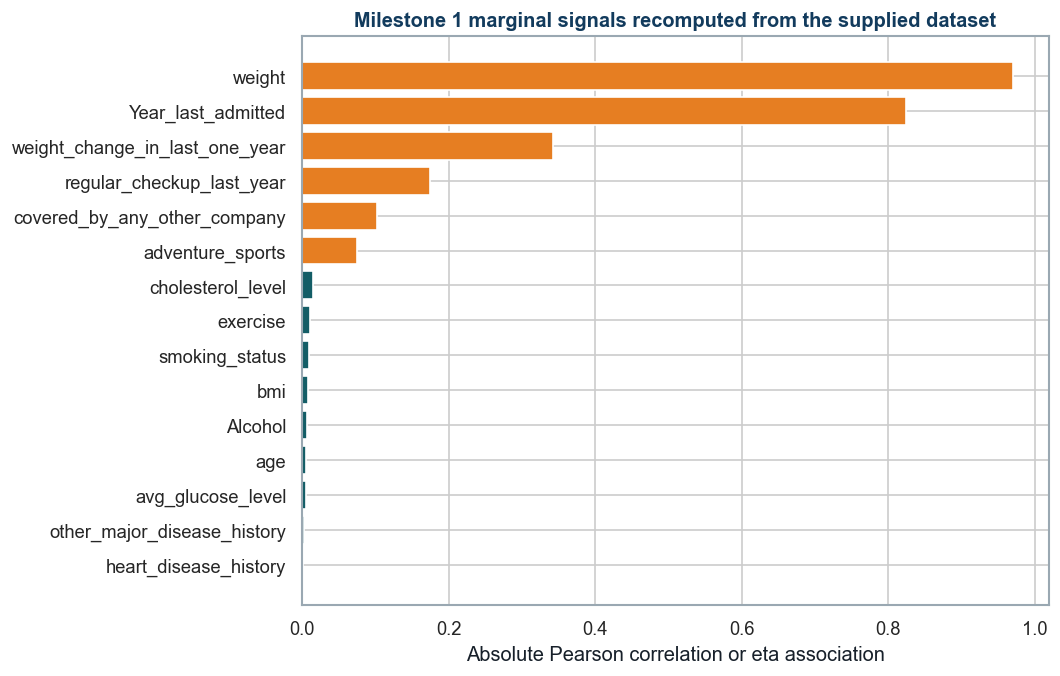

Milestone 1 comparison: All listed findings confirmed


In [4]:
m1_target_levels = np.sort(model_df[TARGET].dropna().unique()).astype(int)
m1_target_differences = np.diff(m1_target_levels)
m1_target_step = int(pd.Series(m1_target_differences).mode().iloc[0])

target_q1, target_q3 = model_df[TARGET].quantile([0.25, 0.75])
target_iqr = target_q3 - target_q1
target_upper_fence = target_q3 + 1.5 * target_iqr
retained_high_cost_rows = int(
    (model_df[TARGET] > target_upper_fence).sum()
)

milestone1_handoff = pd.DataFrame(
    [
        ["Dataset rows", len(model_df), "Recomputed from the supplied CSV"],
        ["Source columns", model_df.shape[1], "Includes target and applicant_id"],
        [
            "Independent applicant variables",
            model_df.shape[1] - 2,
            "Target and applicant_id excluded",
        ],
        ["Valid target quote bands", len(m1_target_levels), "Discrete target levels"],
        ["Target quote-band step", m1_target_step, "Modal difference between adjacent levels"],
        ["BMI missing rows", int(model_df["bmi"].isna().sum()), "Retained for pipeline treatment"],
        [
            "Year_last_admitted missing rows",
            int(model_df["Year_last_admitted"].isna().sum()),
            "Retained as meaningful admission-history missingness",
        ],
        [
            "Unique applicant IDs",
            int(model_df["applicant_id"].nunique()),
            "Identifier excluded before modeling",
        ],
        [
            "High-cost rows above IQR fence",
            retained_high_cost_rows,
            "Retained because they remain valid quote-band observations",
        ],
        ["High-cost rows deleted", 0, "No target-tail deletion"],
    ],
    columns=["Milestone 1 evidence", "Recomputed value", "Modeling implication"],
)
milestone1_handoff.to_csv(
    TABLE_DIR / "milestone1_handoff_summary.csv",
    index=False,
)

def marginal_association_score(frame, feature, target):
    series = frame[feature]
    outcome = frame[target].astype(float)
    if pd.api.types.is_numeric_dtype(series):
        return abs(float(pd.to_numeric(series, errors="coerce").corr(outcome)))

    grouped = pd.DataFrame(
        {
            "feature": series.astype("object").fillna("Missing"),
            "target": outcome,
        }
    )
    grand_mean = grouped["target"].mean()
    total_variation = ((grouped["target"] - grand_mean) ** 2).sum()
    between_variation = sum(
        len(part) * (part["target"].mean() - grand_mean) ** 2
        for _, part in grouped.groupby("feature", dropna=False)
    )
    return float(np.sqrt(between_variation / total_variation))


expected_signal_roles = {
    "weight": "Leading observed signal",
    "Year_last_admitted": "Leading observed signal",
    "covered_by_any_other_company": "Leading observed signal",
    "regular_checkup_last_year": "Leading observed signal",
    "weight_change_in_last_one_year": "Leading observed signal",
    "adventure_sports": "Leading observed signal",
    "smoking_status": "Weak marginal signal",
    "Alcohol": "Weak marginal signal",
    "exercise": "Weak marginal signal",
    "age": "Weak marginal signal",
    "bmi": "Weak marginal signal",
    "avg_glucose_level": "Weak marginal signal",
    "cholesterol_level": "Weak marginal signal",
    "heart_disease_history": "Weak marginal signal",
    "other_major_disease_history": "Weak marginal signal",
}
signal_rows = []
for feature, expected_role in expected_signal_roles.items():
    score = marginal_association_score(model_df, feature, TARGET)
    recomputed_role = (
        "Leading observed signal" if score >= 0.05 else "Weak marginal signal"
    )
    signal_rows.append(
        {
            "feature": feature,
            "association measure": (
                "Absolute Pearson correlation"
                if pd.api.types.is_numeric_dtype(model_df[feature])
                else "Eta association"
            ),
            "association score": score,
            "Milestone 1 role": expected_role,
            "recomputed role": recomputed_role,
            "comparison": (
                "Confirmed" if recomputed_role == expected_role else "Changed"
            ),
        }
    )

milestone1_signal_recheck = (
    pd.DataFrame(signal_rows)
    .sort_values("association score", ascending=False)
    .reset_index(drop=True)
)
milestone1_signal_recheck.to_csv(
    TABLE_DIR / "milestone1_signal_recheck.csv",
    index=False,
)

milestone1_recommendations = pd.DataFrame(
    [
        [
            "Use a target-band-aware split",
            "Stratify the holdout and validation folds by the 54 quote bands",
            "Sections 6, 10, and 13",
        ],
        [
            "Compare baseline and advanced models",
            "Evaluate mean, linear, tree, boosting, and blend candidates",
            "Sections 9 to 14",
        ],
        [
            "Evaluate continuous and quote-band outputs",
            "Compare raw, calibrated, rounded, and calibrated-rounded variants",
            "Section 15",
        ],
        [
            "Review residuals by premium segment",
            "Report cost-decile and applicant-segment errors",
            "Section 17",
        ],
        [
            "Explain the final model",
            "Use permutation importance and a SHAP challenger explanation",
            "Sections 18 and 19",
        ],
    ],
    columns=[
        "Milestone 1 recommendation",
        "Milestone 2 implementation",
        "Notebook evidence",
    ],
)
milestone1_recommendations.to_csv(
    TABLE_DIR / "milestone1_recommendation_implementation.csv",
    index=False,
)

display(milestone1_handoff)
display(milestone1_signal_recheck.round({"association score": 4}))
display(milestone1_recommendations)

signal_chart = milestone1_signal_recheck.sort_values("association score")
plt.figure(figsize=(9.0, 5.8))
colors = [
    COLORS[1] if role == "Leading observed signal" else COLORS[0]
    for role in signal_chart["recomputed role"]
]
plt.barh(
    signal_chart["feature"],
    signal_chart["association score"],
    color=colors,
)
plt.title("Milestone 1 marginal signals recomputed from the supplied dataset")
plt.xlabel("Absolute Pearson correlation or eta association")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "milestone1_signal_recheck.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "milestone1_signal_recheck.png"),
        alt="Recomputed marginal association scores for Milestone 1 signals.",
    )
)

changed_findings = milestone1_signal_recheck.loc[
    milestone1_signal_recheck["comparison"] == "Changed",
    "feature",
].tolist()
print(
    "Milestone 1 comparison:",
    "All listed findings confirmed"
    if not changed_findings
    else "Changed findings: " + ", ".join(changed_findings),
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The handoff is recomputed from the supplied CSV: 25,000 rows, 24 source columns, 22 usable applicant variables, 54 target bands separated by 1,234, 990 missing BMI values, and 11,881 missing admission-year values. The signal recheck confirms the leading and weak marginal groups reported in Milestone 1.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Milestone 2 carries forward the pricing-grid, missingness, identifier, target-tail, validation, diagnostics, and explainability decisions without depending on Milestone 1 files at runtime.</span>
  </div>
</div>

## 5. Metrics of Interest and Selection Logic

The model comparison uses five complementary regression metrics:

- **MAE** measures the average absolute pricing error in cost units.
- **RMSE** gives greater weight to large errors and is the primary validation metric.
- **R2** measures the proportion of target variance explained.
- **MAPE** expresses average absolute error as a percentage of actual cost.
- **SMAPE** provides a symmetric percentage error that is less one-sided than MAPE.

Target-band accuracy is added after model selection because the observed target follows
a fixed quote grid. The deployment comparison reports exact-band accuracy and accuracy
within one, two, and three valid quote bands.

In [5]:
def smape(y_true, y_pred):
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    denominator = np.abs(actual) + np.abs(predicted)
    ratio = np.where(
        denominator == 0,
        0.0,
        2.0 * np.abs(predicted - actual) / denominator,
    )
    return float(np.mean(ratio) * 100)


def regression_metrics(y_true, y_pred):
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    safe_actual = np.maximum(np.abs(actual), 1.0)
    return {
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "R2": float(r2_score(actual, predicted)),
        "MAPE": float(np.mean(np.abs(actual - predicted) / safe_actual) * 100),
        "SMAPE": smape(actual, predicted),
    }


metric_guide = pd.DataFrame(
    [
        [
            "RMSE",
            "Primary selection metric",
            "Square root of the average squared prediction errors",
            "Expressed in cost units and gives extra weight to large misses",
        ],
        [
            "MAE",
            "Primary business metric",
            "Average absolute difference between actual and predicted cost",
            "Typical prediction error in the same units as insurance_cost",
        ],
        [
            "R2",
            "Explanatory metric",
            "Share of target variation explained relative to predicting the mean",
            "Closer to 1 indicates better overall fit",
        ],
        [
            "MAPE",
            "Supporting metric",
            "Average absolute error divided by actual cost",
            "Percentage error that can emphasize mistakes on low-cost cases",
        ],
        [
            "SMAPE",
            "Supporting metric",
            "Percentage error scaled by both actual and predicted cost",
            "A more balanced percentage view when values differ in scale",
        ],
        [
            "Band accuracy",
            "Deployment metric",
            "Share of predictions at or within a stated number of quote bands",
            "Measures how close the output is to the historical pricing grid",
        ],
    ],
    columns=["metric", "role", "plain-language definition", "project meaning"],
)
display(metric_guide)

,metric,role,plain-language definition,project meaning
0,RMSE,Primary selection metric,Square root of the average squared prediction errors,Expressed in cost units and gives extra weight to large misses
1,MAE,Primary business metric,Average absolute difference between actual and predicted cost,Typical prediction error in the same units as insurance_cost
2,R2,Explanatory metric,Share of target variation explained relative to predicting the mean,Closer to 1 indicates better overall fit
3,MAPE,Supporting metric,Average absolute error divided by actual cost,Percentage error that can emphasize mistakes on low-cost cases
4,SMAPE,Supporting metric,Percentage error scaled by both actual and predicted cost,A more balanced percentage view when values differ in scale
5,Band accuracy,Deployment metric,Share of predictions at or within a stated number of quote bands,Measures how close the output is to the historical pricing grid


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>RMSE is used for cross-validation ranking, while MAE, R2, MAPE, and SMAPE prevent a one-metric conclusion. Quote-band metrics are evaluated separately from continuous regression metrics.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>MAE communicates average monetary error, RMSE controls large misses, and band accuracy connects the analysis to the historical pricing grid.</span>
  </div>
</div>

## 6. Dependent/Independent Variables and Train/Test Split

,dataset role,column count,columns,reason
0,Independent variables (X),22,"years_of_insurance_with_us, regular_checkup_last_year, adventure_sports, Occupation, visited_doctor_last_1_year, cholesterol_level, daily_avg_steps, age, heart_disease_history, other_major_disease_history, Gender, avg_glucose_level, bmi, smoking_status, Year_last_admitted, Location, weight, covered_by_any_other_company, Alcohol, exercise, weight_change_in_last_one_year, fat_percentage","Applicant health, lifestyle, medical-history, demographic, and insurance-history inputs"
1,Dependent variable (y),1,insurance_cost,Continuous insurance cost target with 54 valid historical quote bands
2,Excluded identifier,1,applicant_id,Unique identifier removed before splitting because it has no generalizable pricing meaning


,item,value
0,Training rows,20000
1,Test rows,5000
2,Train percentage,80.0%
3,Test percentage,20.0%
4,Quote bands in training,54
5,Quote bands in test,54
6,Maximum band share gap,0.015%


,insurance_cost,full_count,train_count,test_count,full_pct,train_pct,test_pct,train_test_pct_gap
0,2468,12,10,2,0.00048,0.00050,0.0004,0.00010
1,3702,309,247,62,0.01236,0.01235,0.0124,0.00005
2,4936,197,158,39,0.00788,0.00790,0.0078,0.00010
3,6170,970,776,194,0.03880,0.03880,0.0388,0.00000
4,7404,1214,971,243,0.04856,0.04855,0.0486,0.00005
5,8638,954,763,191,0.03816,0.03815,0.0382,0.00005
6,9872,742,594,148,0.02968,0.02970,0.0296,0.00010
7,11106,431,345,86,0.01724,0.01725,0.0172,0.00005
8,12340,373,298,75,0.01492,0.01490,0.0150,0.00010
9,13574,454,363,91,0.01816,0.01815,0.0182,0.00005


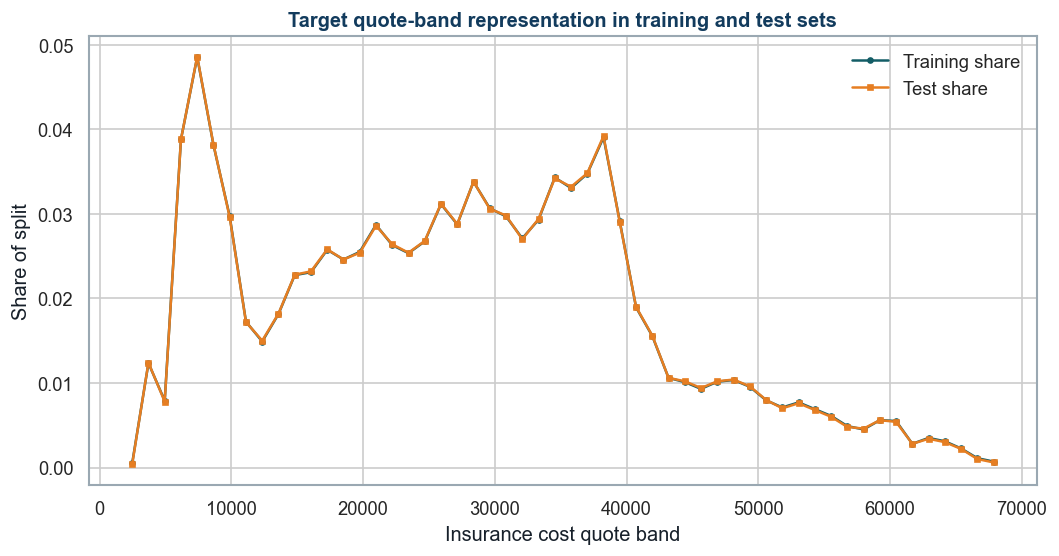

In [6]:
X = model_df.drop(columns=[TARGET, "applicant_id"])
y = model_df[TARGET].astype(float)

variable_split_summary = pd.DataFrame(
    [
        [
            "Independent variables (X)",
            len(X.columns),
            ", ".join(X.columns),
            "Applicant health, lifestyle, medical-history, demographic, and insurance-history inputs",
        ],
        [
            "Dependent variable (y)",
            1,
            TARGET,
            "Continuous insurance cost target with 54 valid historical quote bands",
        ],
        [
            "Excluded identifier",
            1,
            "applicant_id",
            "Unique identifier removed before splitting because it has no generalizable pricing meaning",
        ],
    ],
    columns=["dataset role", "column count", "columns", "reason"],
)
display(variable_split_summary)

target_levels = np.sort(y.unique()).astype(int)
target_diffs = np.diff(target_levels)
target_step = int(pd.Series(target_diffs).mode().iloc[0])
target_strata = y.astype(int).astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_strata,
)

train_counts = y_train.astype(int).value_counts().reindex(target_levels, fill_value=0)
test_counts = y_test.astype(int).value_counts().reindex(target_levels, fill_value=0)
split_check = pd.DataFrame(
    {
        "insurance_cost": target_levels,
        "full_count": y.astype(int).value_counts().reindex(target_levels).values,
        "train_count": train_counts.values,
        "test_count": test_counts.values,
    }
)
split_check["full_pct"] = split_check["full_count"] / len(y)
split_check["train_pct"] = split_check["train_count"] / len(y_train)
split_check["test_pct"] = split_check["test_count"] / len(y_test)
split_check["train_test_pct_gap"] = (
    split_check["train_pct"] - split_check["test_pct"]
).abs()
split_check.to_csv(TABLE_DIR / "target_band_split_check.csv", index=False)

split_summary = pd.DataFrame(
    {
        "item": [
            "Training rows",
            "Test rows",
            "Train percentage",
            "Test percentage",
            "Quote bands in training",
            "Quote bands in test",
            "Maximum band share gap",
        ],
        "value": [
            len(X_train),
            len(X_test),
            f"{len(X_train) / len(X):.1%}",
            f"{len(X_test) / len(X):.1%}",
            int((train_counts > 0).sum()),
            int((test_counts > 0).sum()),
            f"{split_check['train_test_pct_gap'].max():.3%}",
        ],
    }
)
display(split_summary)
display(split_check.head(10))

plt.figure(figsize=(9.0, 4.8))
plt.plot(
    split_check["insurance_cost"],
    split_check["train_pct"],
    marker="o",
    markersize=3,
    color=COLORS[0],
    label="Training share",
)
plt.plot(
    split_check["insurance_cost"],
    split_check["test_pct"],
    marker="s",
    markersize=3,
    color=COLORS[1],
    label="Test share",
)
plt.title("Target quote-band representation in training and test sets")
plt.xlabel("Insurance cost quote band")
plt.ylabel("Share of split")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "target_band_split_distribution.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "target_band_split_distribution.png"),
        alt="Training and test shares across all 54 insurance-cost quote bands.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The dependent variable is `insurance_cost`; the 22 independent variables exclude `applicant_id`. The 80/20 split uses all 54 target levels as strata, and every quote band is represented in both partitions.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Applicant identity cannot influence pricing, while common and rare quote bands are represented during training and final evaluation.</span>
  </div>
</div>

## 7. Milestone 1 Feature-engineering Challenger

Milestone 1 proposed missingness indicators, admission-recency fields,
cholesterol conversion, readable health bands, combined disease history,
and interaction variables. The following target-free transformation is
defined where it is first used and compared against the raw 22-feature set
on exactly the same training-only folds.

The engineered set is adopted only if it reduces mean CV RMSE by at least
0.5%, or remains within 0.1% while reducing fold-to-fold RMSE variability by
at least 10%. This practical-equivalence rule avoids adding deployment
complexity for a negligible or unstable gain.

,feature set,feature count,CV MAE mean,CV RMSE mean,CV RMSE std,CV R2 mean,selected for downstream modeling,RMSE difference versus raw
0,Raw 22 features,22,2368.6072,2955.3767,2.7519,0.9575,True,0.0000
1,Milestone 1 engineered 32 features,32,2359.0980,2948.4521,6.7454,0.9577,False,-6.9246


,0
selected feature strategy,raw_22_features
engineered CV RMSE gain,6.924607
engineered relative RMSE gain,0.002343
engineered CV RMSE stability gain,-3.993515
decision,"Engineered features did not meet the predefined 0.5% RMSE improvement or stability threshold, so the raw feature set is retained for parsimony and portable deployment."
target used to create features,False
same CV folds used,True


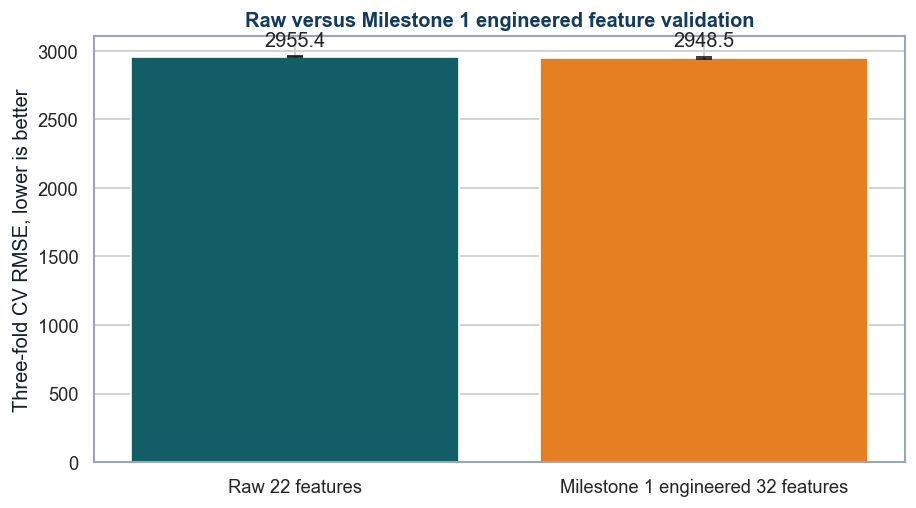

In [7]:
M1_REFERENCE_YEAR = 2019

def cholesterol_midpoint(value):
    if pd.isna(value):
        return np.nan
    numbers = re.findall(r"\d+(?:\.\d+)?", str(value))
    if len(numbers) >= 2:
        return (float(numbers[0]) + float(numbers[1])) / 2.0
    if len(numbers) == 1:
        return float(numbers[0])
    return np.nan


def add_milestone1_features(frame):
    engineered = frame.copy()
    bmi = pd.to_numeric(engineered["bmi"], errors="coerce")
    age = pd.to_numeric(engineered["age"], errors="coerce")
    admission_year = pd.to_numeric(
        engineered["Year_last_admitted"],
        errors="coerce",
    )

    engineered["bmi_missing_flag"] = bmi.isna().astype(int)
    engineered["admission_year_missing_flag"] = (
        admission_year.isna().astype(int)
    )
    engineered["admission_status"] = np.where(
        admission_year.notna(),
        "Previously admitted",
        "No known admission",
    )
    engineered["years_since_last_admitted"] = np.where(
        admission_year.notna(),
        M1_REFERENCE_YEAR - admission_year,
        0,
    )
    engineered["cholesterol_midpoint"] = engineered[
        "cholesterol_level"
    ].map(cholesterol_midpoint)
    engineered["age_band"] = (
        pd.cut(
            age,
            bins=[0, 25, 35, 45, 55, 65, np.inf],
            labels=["<=25", "26-35", "36-45", "46-55", "56-65", "66+"],
            right=True,
        )
        .astype("object")
        .fillna("Unknown")
    )
    engineered["bmi_category"] = (
        pd.cut(
            bmi,
            bins=[0, 18.5, 25, 30, np.inf],
            labels=["Underweight", "Normal", "Overweight", "Obese"],
            right=False,
        )
        .astype("object")
        .fillna("Unknown")
    )
    engineered["any_major_disease_history"] = (
        (engineered["heart_disease_history"] == 1)
        | (engineered["other_major_disease_history"] == 1)
    ).astype(int)
    engineered["weight_bmi_interaction"] = (
        pd.to_numeric(engineered["weight"], errors="coerce") * bmi
    )
    engineered["steps_per_age"] = (
        pd.to_numeric(engineered["daily_avg_steps"], errors="coerce")
        / age.replace(0, np.nan)
    )
    return engineered


def make_feature_comparison_pipeline(frame):
    comparison_numeric = frame.select_dtypes(
        include=np.number
    ).columns.tolist()
    comparison_categorical = [
        column
        for column in frame.columns
        if column not in comparison_numeric
    ]
    comparison_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    [
                        (
                            "imputer",
                            SimpleImputer(
                                strategy="median",
                                add_indicator=True,
                            ),
                        ),
                        ("scaler", StandardScaler()),
                    ]
                ),
                comparison_numeric,
            ),
            (
                "categorical",
                Pipeline(
                    [
                        (
                            "imputer",
                            SimpleImputer(strategy="most_frequent"),
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                comparison_categorical,
            ),
        ],
        verbose_feature_names_out=False,
    )
    return Pipeline(
        [
            ("preprocess", comparison_preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=320,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=25,
                    l2_regularization=0.05,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


engineered_X_train = add_milestone1_features(X_train)
engineered_X_test = add_milestone1_features(X_test)
train_strata = y_train.astype(int).astype(str)
feature_splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)
feature_cv_splits = list(
    feature_splitter.split(X_train, train_strata)
)

feature_set_rows = []
for feature_set_name, feature_frame in [
    ("Raw 22 features", X_train),
    ("Milestone 1 engineered 32 features", engineered_X_train),
]:
    validation = cross_validate(
        make_feature_comparison_pipeline(feature_frame),
        feature_frame,
        y_train,
        cv=feature_cv_splits,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
        error_score="raise",
    )
    feature_set_rows.append(
        {
            "feature set": feature_set_name,
            "feature count": feature_frame.shape[1],
            "CV MAE mean": -float(validation["test_mae"].mean()),
            "CV RMSE mean": -float(validation["test_rmse"].mean()),
            "CV RMSE std": float(validation["test_rmse"].std()),
            "CV R2 mean": float(validation["test_r2"].mean()),
        }
    )

feature_set_comparison = pd.DataFrame(feature_set_rows)
raw_feature_result = feature_set_comparison.iloc[0]
engineered_feature_result = feature_set_comparison.iloc[1]
engineered_rmse_gain = (
    raw_feature_result["CV RMSE mean"]
    - engineered_feature_result["CV RMSE mean"]
)
engineered_relative_gain = (
    engineered_rmse_gain / raw_feature_result["CV RMSE mean"]
)
engineered_stability_gain = (
    raw_feature_result["CV RMSE std"]
    - engineered_feature_result["CV RMSE std"]
)
engineered_features_selected = bool(
    engineered_relative_gain >= 0.005
    or (
        engineered_relative_gain >= -0.001
        and engineered_feature_result["CV RMSE std"]
        <= raw_feature_result["CV RMSE std"] * 0.90
    )
)
selected_feature_strategy = (
    "milestone1_engineered"
    if engineered_features_selected
    else "raw_22_features"
)
feature_selection_reason = (
    "Engineered features met the predefined accuracy or stability threshold."
    if engineered_features_selected
    else (
        "Engineered features did not meet the predefined 0.5% RMSE "
        "improvement or stability threshold, so the raw feature set is "
        "retained for parsimony and portable deployment."
    )
)
feature_set_comparison["selected for downstream modeling"] = [
    not engineered_features_selected,
    engineered_features_selected,
]
feature_set_comparison["RMSE difference versus raw"] = [
    0.0,
    -engineered_rmse_gain,
]
feature_set_comparison.to_csv(
    TABLE_DIR / "milestone1_feature_set_comparison.csv",
    index=False,
)

feature_engineering_decision = pd.DataFrame(
    [
        {
            "selected feature strategy": selected_feature_strategy,
            "engineered CV RMSE gain": engineered_rmse_gain,
            "engineered relative RMSE gain": engineered_relative_gain,
            "engineered CV RMSE stability gain": engineered_stability_gain,
            "decision": feature_selection_reason,
            "target used to create features": False,
            "same CV folds used": True,
        }
    ]
)
feature_engineering_decision.to_csv(
    TABLE_DIR / "milestone1_feature_engineering_decision.csv",
    index=False,
)

display(feature_set_comparison.round(4))
display(feature_engineering_decision.T)

plot_feature_sets = feature_set_comparison.copy()
plt.figure(figsize=(7.8, 4.4))
bars = plt.bar(
    plot_feature_sets["feature set"],
    plot_feature_sets["CV RMSE mean"],
    yerr=plot_feature_sets["CV RMSE std"],
    capsize=5,
    color=[COLORS[0], COLORS[1]],
)
plt.bar_label(bars, fmt="%.1f", padding=4)
plt.title("Raw versus Milestone 1 engineered feature validation")
plt.ylabel("Three-fold CV RMSE, lower is better")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "milestone1_feature_set_comparison.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "milestone1_feature_set_comparison.png"),
        alt="Cross-validation RMSE comparison of raw and Milestone 1 engineered features.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The target-free Milestone 1 fields are rebuilt inside this notebook and compared on the same target-stratified folds. On the supplied data, the engineered set produces only a small mean RMSE change and weaker fold stability, so it does not meet the predefined practical-improvement rule.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The final model keeps the simpler 22 applicant inputs. This reduces deployment complexity while retaining Milestone 1 missingness handling inside the training-fitted pipeline.</span>
  </div>
</div>

## 8. Leakage-safe Preprocessing Pipeline

In [8]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [
    column for column in X_train.columns if column not in numeric_features
]

def make_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median", add_indicator=True),
            ),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", model),
        ]
    )


preprocessing_plan = pd.DataFrame(
    [
        [
            "applicant_id",
            "Removed before splitting",
            "Identifier with no generalizable pricing meaning",
        ],
        [
            "Numeric variables",
            "Training median imputation, missing indicator, standard scaling",
            "Handles BMI/admission-year gaps without using test information",
        ],
        [
            "Categorical variables",
            "Most-frequent imputation and one-hot encoding",
            "Supports nominal categories and unseen deployment levels",
        ],
        [
            "Target",
            "Not transformed in preprocessing",
            "Keeps errors interpretable in insurance-cost units",
        ],
    ],
    columns=["field group", "pipeline action", "justification"],
)
display(preprocessing_plan)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

,field group,pipeline action,justification
0,applicant_id,Removed before splitting,Identifier with no generalizable pricing meaning
1,Numeric variables,"Training median imputation, missing indicator, standard scaling",Handles BMI/admission-year gaps without using test information
2,Categorical variables,Most-frequent imputation and one-hot encoding,Supports nominal categories and unseen deployment levels
3,Target,Not transformed in preprocessing,Keeps errors interpretable in insurance-cost units


Numeric features: ['years_of_insurance_with_us', 'regular_checkup_last_year', 'adventure_sports', 'visited_doctor_last_1_year', 'daily_avg_steps', 'age', 'heart_disease_history', 'other_major_disease_history', 'avg_glucose_level', 'bmi', 'Year_last_admitted', 'weight', 'weight_change_in_last_one_year', 'fat_percentage']
Categorical features: ['Occupation', 'cholesterol_level', 'Gender', 'smoking_status', 'Location', 'covered_by_any_other_company', 'Alcohol', 'exercise']


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>All imputation, scaling, and encoding are fitted inside each training fold. The saved pipeline uses only standard sklearn and booster objects, so it can be loaded without project-specific transformer code.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The pipeline preserves applicants with missing BMI or admission year while preventing information from the test set from influencing preprocessing.</span>
  </div>
</div>

## 9. Baseline and Advanced Model Selection

In [9]:
package_map = {
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
    "shap": "shap",
}
missing_packages = [
    package
    for module, package in package_map.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    install = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages],
        capture_output=True,
        text=True,
    )
    if install.returncode != 0:
        raise RuntimeError(
            "Required modeling packages could not be installed: "
            + ", ".join(missing_packages)
        )

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

def nvidia_gpu_available():
    if shutil.which("nvidia-smi") is None:
        return False
    check = subprocess.run(
        ["nvidia-smi", "-L"],
        capture_output=True,
        text=True,
    )
    return check.returncode == 0 and "GPU" in check.stdout


GPU_AVAILABLE = nvidia_gpu_available()
accelerator = "NVIDIA GPU for XGBoost and CatBoost" if GPU_AVAILABLE else "CPU"
print("Accelerator selected:", accelerator)

xgb_parameters = {
    "n_estimators": 420,
    "max_depth": 4,
    "learning_rate": 0.045,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
}
if GPU_AVAILABLE:
    xgb_parameters["device"] = "cuda"

catboost_parameters = {
    "iterations": 420,
    "learning_rate": 0.045,
    "depth": 6,
    "loss_function": "RMSE",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
}
if GPU_AVAILABLE:
    catboost_parameters.update({"task_type": "GPU", "devices": "0"})
else:
    catboost_parameters["thread_count"] = -1

base_model_objects = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=5.0),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=25,
        random_state=RANDOM_STATE,
    ),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=180,
        max_depth=16,
        min_samples_leaf=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.055,
        max_depth=3,
        min_samples_leaf=25,
        subsample=0.85,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
        max_iter=320,
        learning_rate=0.06,
        max_leaf_nodes=31,
        min_samples_leaf=25,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
    ),
    "RegularizedHistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=600,
        learning_rate=0.035,
        max_leaf_nodes=31,
        min_samples_leaf=35,
        l2_regularization=0.05,
        max_bins=255,
        random_state=RANDOM_STATE,
    ),
    "XGBRegressor": XGBRegressor(**xgb_parameters),
    "LightGBMRegressor": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=24,
        min_child_samples=30,
        subsample=0.90,
        colsample_bytree=0.85,
        reg_lambda=0.30,
        reg_alpha=0.02,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "CatBoostRegressor": CatBoostRegressor(**catboost_parameters),
}
estimator_definitions = {
    name: make_pipeline(model) for name, model in base_model_objects.items()
}

model_reference_guide = pd.DataFrame(
    [
        [
            "DummyRegressor",
            "Mean baseline",
            "Predicts the training-set mean for every applicant.",
            "Defines the minimum performance that a useful model must beat.",
            "Does not use applicant differences.",
        ],
        [
            "LinearRegression",
            "Linear regression",
            "Adds a learned contribution from each encoded input to form the prediction.",
            "Provides a transparent additive benchmark.",
            "Cannot naturally represent thresholds and complex interactions.",
        ],
        [
            "Ridge",
            "Regularized linear regression",
            "Uses linear regression with an L2 penalty that shrinks unstable coefficients.",
            "Tests whether a more stable linear model improves generalization.",
            "Remains an additive linear model.",
        ],
        [
            "DecisionTreeRegressor",
            "Decision tree",
            "Builds if-then split rules that divide applicants into progressively similar groups.",
            "Captures nonlinear thresholds and interactions.",
            "A single tree can overfit and change with the sample.",
        ],
        [
            "RandomForestRegressor",
            "Random forest",
            "Averages many trees trained on resampled rows and randomized feature subsets.",
            "Reduces the instability of one decision tree.",
            "Is larger and less directly interpretable than one tree.",
        ],
        [
            "GradientBoostingRegressor",
            "Gradient boosting",
            "Builds small trees sequentially, with each tree correcting earlier residual errors.",
            "Tests a strong nonlinear boosting benchmark.",
            "Performance depends on learning rate, tree size, and iteration count.",
        ],
        [
            "HistGradientBoostingRegressor",
            "Histogram Gradient Boosting",
            "Groups numeric values into bins before sequential tree boosting for efficient training.",
            "Provides a fast sklearn boosting candidate for tabular data.",
            "Still requires controls for tree complexity and overfitting.",
        ],
        [
            "RegularizedHistGradientBoosting",
            "Regularized Histogram Gradient Boosting",
            "The same histogram algorithm with slower learning, leaf limits, and L2 regularization.",
            "Tests a deliberately more constrained configuration.",
            "This is a project label, not a separate software library.",
        ],
        [
            "XGBRegressor",
            "XGBoost",
            "An optimized gradient-boosted tree implementation with sampling and regularization controls.",
            "Adds a widely used advanced boosting benchmark.",
            "Requires careful tuning and optional accelerator configuration.",
        ],
        [
            "LightGBMRegressor",
            "LightGBM",
            "A histogram-based booster that grows the leaf with the largest expected loss reduction.",
            "Provides efficient learning and strong nonlinear performance.",
            "Leaf-wise growth can overfit when leaf constraints are too loose.",
        ],
        [
            "CatBoostRegressor",
            "CatBoost",
            "A boosting implementation designed for stable training and strong categorical-data handling.",
            "Adds a third external booster for comparison.",
            "In this notebook it receives the same one-hot encoded inputs for a fair pipeline comparison.",
        ],
        [
            "TunedHistGradientBoostingRegressor",
            "Tuned Histogram Gradient Boosting",
            "The histogram model whose settings are chosen by RandomizedSearchCV on training folds.",
            "Tests whether systematic tuning improves the base configuration.",
            "Tuning improves the search process but does not guarantee the final winner.",
        ],
        [
            "WeightedBlendLightGBMHistGradient",
            "50/50 weighted blend",
            "Averages the predictions from LightGBM and regularized Histogram Gradient Boosting.",
            "Tests whether combining two strong but different boosters reduces validation error.",
            "Deployment must load and run both component pipelines.",
        ],
        [
            "HistGradientBoostingClassifier",
            "Quote-band classifier",
            "Predicts probabilities for the 54 historical quote-band classes.",
            "Challenges continuous regression with a discrete quote-band formulation.",
            "The multiclass loss does not itself enforce the numeric order of the bands.",
        ],
    ],
    columns=[
        "output name",
        "reader-friendly name",
        "how it works",
        "role in this project",
        "main caution",
    ],
)
model_reference_guide.to_csv(
    TABLE_DIR / "model_reference_guide.csv",
    index=False,
)
display(model_reference_guide)

Accelerator selected: CPU


,output name,reader-friendly name,how it works,role in this project,main caution
0,DummyRegressor,Mean baseline,Predicts the training-set mean for every applicant.,Defines the minimum performance that a useful model must beat.,Does not use applicant differences.
1,LinearRegression,Linear regression,Adds a learned contribution from each encoded input to form the prediction.,Provides a transparent additive benchmark.,Cannot naturally represent thresholds and complex interactions.
2,Ridge,Regularized linear regression,Uses linear regression with an L2 penalty that shrinks unstable coefficients.,Tests whether a more stable linear model improves generalization.,Remains an additive linear model.
3,DecisionTreeRegressor,Decision tree,Builds if-then split rules that divide applicants into progressively similar groups.,Captures nonlinear thresholds and interactions.,A single tree can overfit and change with the sample.
4,RandomForestRegressor,Random forest,Averages many trees trained on resampled rows and randomized feature subsets.,Reduces the instability of one decision tree.,Is larger and less directly interpretable than one tree.
5,GradientBoostingRegressor,Gradient boosting,"Builds small trees sequentially, with each tree correcting earlier residual errors.",Tests a strong nonlinear boosting benchmark.,"Performance depends on learning rate, tree size, and iteration count."
6,HistGradientBoostingRegressor,Histogram Gradient Boosting,Groups numeric values into bins before sequential tree boosting for efficient training.,Provides a fast sklearn boosting candidate for tabular data.,Still requires controls for tree complexity and overfitting.
7,RegularizedHistGradientBoosting,Regularized Histogram Gradient Boosting,"The same histogram algorithm with slower learning, leaf limits, and L2 regularization.",Tests a deliberately more constrained configuration.,"This is a project label, not a separate software library."
8,XGBRegressor,XGBoost,An optimized gradient-boosted tree implementation with sampling and regularization controls.,Adds a widely used advanced boosting benchmark.,Requires careful tuning and optional accelerator configuration.
9,LightGBMRegressor,LightGBM,A histogram-based booster that grows the leaf with the largest expected loss reduction.,Provides efficient learning and strong nonlinear performance.,Leaf-wise growth can overfit when leaf constraints are too loose.


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>Every model label used in later result tables is defined above. The comparison moves from a mean baseline through linear and tree models to tuned boosting and a two-model blend. XGBoost and CatBoost use an NVIDIA GPU when one is visible, with CPU execution otherwise.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The guide lets a reviewer connect each technical output name to its practical purpose and limitation before comparing performance.</span>
  </div>
</div>

## 10. Build and Evaluate All Models

In [10]:
cv_splits = feature_cv_splits
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

def fit_and_evaluate(name, estimator):
    started = time.perf_counter()
    validation = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    estimator.fit(X_train, y_train)
    train_prediction = estimator.predict(X_train)
    test_prediction = estimator.predict(X_test)
    train_result = regression_metrics(y_train, train_prediction)
    test_result = regression_metrics(y_test, test_prediction)
    row = {
        "model": name,
        "cv_MAE_mean": -float(validation["test_mae"].mean()),
        "cv_MAE_std": float(validation["test_mae"].std()),
        "cv_RMSE_mean": -float(validation["test_rmse"].mean()),
        "cv_RMSE_std": float(validation["test_rmse"].std()),
        "cv_R2_mean": float(validation["test_r2"].mean()),
        **{f"train_{key}": value for key, value in train_result.items()},
        **{f"test_{key}": value for key, value in test_result.items()},
        "train_test_RMSE_gap": test_result["RMSE"] - train_result["RMSE"],
        "fit_and_cv_seconds": time.perf_counter() - started,
    }
    return row, estimator


model_rows = []
fitted_models = {}
for model_name, estimator in estimator_definitions.items():
    print(f"Training and validating {model_name}...")
    try:
        row, fitted = fit_and_evaluate(model_name, estimator)
    except Exception:
        if not GPU_AVAILABLE or model_name not in {"XGBRegressor", "CatBoostRegressor"}:
            raise
        print(f"GPU execution failed for {model_name}; retrying on CPU.")
        if model_name == "XGBRegressor":
            cpu_parameters = dict(xgb_parameters)
            cpu_parameters.pop("device", None)
            estimator = make_pipeline(XGBRegressor(**cpu_parameters))
        else:
            cpu_parameters = dict(catboost_parameters)
            cpu_parameters.pop("task_type", None)
            cpu_parameters.pop("devices", None)
            cpu_parameters["thread_count"] = -1
            estimator = make_pipeline(CatBoostRegressor(**cpu_parameters))
        row, fitted = fit_and_evaluate(model_name, estimator)
    model_rows.append(row)
    fitted_models[model_name] = fitted

metrics = (
    pd.DataFrame(model_rows)
    .sort_values(["cv_RMSE_mean", "cv_MAE_mean"])
    .reset_index(drop=True)
)
display(
    metrics[
        [
            "model",
            "cv_MAE_mean",
            "cv_RMSE_mean",
            "cv_RMSE_std",
            "train_MAE",
            "train_RMSE",
            "train_R2",
            "test_MAE",
            "test_RMSE",
            "test_R2",
            "train_test_RMSE_gap",
        ]
    ].round(3)
)

Training and validating DummyRegressor...


Training and validating LinearRegression...


Training and validating Ridge...


Training and validating DecisionTreeRegressor...


Training and validating RandomForestRegressor...


...

Training and validating RegularizedHistGradientBoosting...


Training and validating XGBRegressor...


Training and validating LightGBMRegressor...


Training and validating CatBoostRegressor...


,model,cv_MAE_mean,cv_RMSE_mean,cv_RMSE_std,train_MAE,train_RMSE,train_R2,test_MAE,test_RMSE,test_R2,train_test_RMSE_gap
0,RegularizedHistGradientBoosting,2370.005,2955.214,0.769,2250.163,2802.340,0.962,2391.266,2980.141,0.957,177.800
1,HistGradientBoostingRegressor,2368.607,2955.377,2.752,2262.998,2817.776,0.961,2393.569,2982.495,0.956,164.719
2,LightGBMRegressor,2376.345,2966.229,5.399,2170.233,2704.342,0.964,2391.451,2979.652,0.957,275.310
3,XGBRegressor,2384.111,2968.108,1.668,2234.839,2782.062,0.962,2408.403,2992.811,0.956,210.750
4,GradientBoostingRegressor,2389.828,2970.467,4.506,2339.908,2909.319,0.959,2421.751,3007.160,0.956,97.841
5,CatBoostRegressor,2388.200,2972.209,4.470,2264.826,2818.373,0.961,2416.286,3001.441,0.956,183.069
6,DecisionTreeRegressor,2505.407,3159.937,12.084,2179.540,2753.829,0.963,2492.437,3162.425,0.951,408.596
7,Ridge,2688.630,3340.823,20.557,2681.845,3331.988,0.946,2760.441,3416.711,0.943,84.723
8,LinearRegression,2688.894,3340.834,20.599,2682.010,3331.985,0.946,2760.666,3416.751,0.943,84.766
9,RandomForestRegressor,3574.792,4607.032,58.440,3149.316,4071.534,0.919,3512.715,4525.298,0.900,453.764


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>Every model is evaluated with the same preprocessing, training rows, target-stratified folds, and metrics. This makes the comparison internally consistent and exposes overfitting through the train-test RMSE gap.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>A model must improve substantially over the mean baseline and remain stable across validation folds before it is considered for pricing support.</span>
  </div>
</div>

## 11. Hyperparameter Tuning

In [11]:
hgb_search_space = {
    "model__max_iter": [260, 360, 480, 600],
    "model__learning_rate": [0.03, 0.045, 0.06, 0.08],
    "model__max_leaf_nodes": [15, 23, 31, 45],
    "model__min_samples_leaf": [15, 25, 35, 50],
    "model__l2_regularization": [0.0, 0.05, 0.15, 0.30],
    "model__max_bins": [128, 255],
}
tuning_search = RandomizedSearchCV(
    estimator=make_pipeline(
        HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    ),
    param_distributions=hgb_search_space,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
    return_train_score=True,
)
tuning_search.fit(X_train, y_train)
tuned_hgb = tuning_search.best_estimator_
tuned_row, tuned_hgb = fit_and_evaluate(
    "TunedHistGradientBoostingRegressor",
    tuned_hgb,
)
fitted_models["TunedHistGradientBoostingRegressor"] = tuned_hgb
metrics = pd.concat([metrics, pd.DataFrame([tuned_row])], ignore_index=True)

tuning_results = (
    pd.DataFrame(tuning_search.cv_results_)
    .sort_values("rank_test_score")
    .loc[
        :,
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params",
        ],
    ]
    .copy()
)
tuning_results["cv_RMSE"] = -tuning_results["mean_test_score"]
tuning_results["train_RMSE"] = -tuning_results["mean_train_score"]
tuning_results["overfit_gap"] = (
    tuning_results["cv_RMSE"] - tuning_results["train_RMSE"]
)
tuning_results.to_csv(TABLE_DIR / "hyperparameter_tuning_results.csv", index=False)
(MODEL_DIR / "best_hyperparameters.json").write_text(
    json.dumps(tuning_search.best_params_, indent=2),
    encoding="utf-8",
)

tuning_techniques = pd.DataFrame(
    [
        [
            "Randomized hyperparameter search",
            "RandomizedSearchCV over eight reproducible candidates",
            "Covers a broad search space without the cost of a full Cartesian grid",
        ],
        [
            "Learning-rate and iteration trade-off",
            "learning_rate with max_iter",
            "Tests slower learning with sufficient boosting iterations",
        ],
        [
            "Tree-complexity control",
            "max_leaf_nodes and min_samples_leaf",
            "Limits overly specific leaf rules and reduces variance",
        ],
        [
            "L2 regularization",
            "l2_regularization",
            "Penalizes overly aggressive fitted responses",
        ],
        [
            "Histogram resolution",
            "max_bins",
            "Balances numerical detail with speed and stability",
        ],
        [
            "Target-stratified cross-validation",
            "The same three training-only folds for every candidate",
            "Preserves all quote bands and prevents test-set tuning",
        ],
        [
            "Overfitting check",
            "Training RMSE compared with cross-validation RMSE",
            "Rejects parameter sets that improve fit without stable validation",
        ],
        [
            "Repeated validation and blending",
            "Six repeated folds followed by a 50/50 advanced-model blend",
            "Tests stability and whether complementary model errors can be reduced",
        ],
    ],
    columns=["technique", "implementation", "purpose"],
)
tuning_techniques.to_csv(
    TABLE_DIR / "tuning_techniques_summary.csv",
    index=False,
)

display(tuning_techniques)
display(pd.DataFrame([tuning_search.best_params_]).T.rename(columns={0: "best value"}))
display(
    tuning_results[
        ["rank_test_score", "cv_RMSE", "std_test_score", "overfit_gap"]
    ].head(8).round(3)
)

,technique,implementation,purpose
0,Randomized hyperparameter search,RandomizedSearchCV over eight reproducible candidates,Covers a broad search space without the cost of a full Cartesian grid
1,Learning-rate and iteration trade-off,learning_rate with max_iter,Tests slower learning with sufficient boosting iterations
2,Tree-complexity control,max_leaf_nodes and min_samples_leaf,Limits overly specific leaf rules and reduces variance
3,L2 regularization,l2_regularization,Penalizes overly aggressive fitted responses
4,Histogram resolution,max_bins,Balances numerical detail with speed and stability
5,Target-stratified cross-validation,The same three training-only folds for every candidate,Preserves all quote bands and prevents test-set tuning
6,Overfitting check,Training RMSE compared with cross-validation RMSE,Rejects parameter sets that improve fit without stable validation
7,Repeated validation and blending,Six repeated folds followed by a 50/50 advanced-model blend,Tests stability and whether complementary model errors can be reduced


,best value
model__min_samples_leaf,50.00
model__max_leaf_nodes,23.00
model__max_iter,260.00
model__max_bins,255.00
model__learning_rate,0.03
model__l2_regularization,0.15


,rank_test_score,cv_RMSE,std_test_score,overfit_gap
5,1,2951.964,1.828,124.682
0,2,2953.290,1.572,124.635
1,3,2954.352,1.106,88.660
7,4,2954.428,1.737,127.141
4,5,2955.082,2.274,189.230
6,6,2961.791,3.042,278.656
2,7,2961.997,3.046,314.736
3,8,2964.720,2.187,261.461


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The practical tuning strategy combines randomized search, learning-rate/iteration balancing, tree-complexity control, L2 regularization, histogram resolution, target-stratified validation, train-validation gap checks, repeated validation, and ensemble blending. No test-set result is used to choose hyperparameters.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Tuning balances accuracy, runtime, and overfitting. The chosen parameters and techniques are saved so the final model can be reproduced and reviewed.</span>
  </div>
</div>

## 12. Weighted Advanced-model Challenger

### Selected-candidate name decoder

`WeightedBlendLightGBMHistGradient` is a descriptive project name:

- **WeightedBlend** means that predictions from multiple fitted models are averaged.
- **LightGBM** is the Light Gradient Boosting Machine component.
- **HistGradient** is sklearn's regularized Histogram Gradient Boosting component.
- **50/50 weights** mean each component contributes half of the final prediction.

Each component contains its own leakage-safe preprocessing pipeline. The blend
does not create a new target or rule; it averages two continuous cost estimates.

,model,cv_RMSE_mean,cv_RMSE_std,train_MAE,train_RMSE,train_R2,test_MAE,test_RMSE,test_R2,train_test_RMSE_gap
0,WeightedBlendLightGBMHistGradient,2949.831,2.995,2204.625,2745.330,0.963,2385.188,2971.905,0.957,226.575
1,TunedHistGradientBoostingRegressor,2951.964,1.828,2280.892,2840.128,0.961,2394.421,2979.111,0.957,138.983
2,RegularizedHistGradientBoosting,2955.214,0.769,2250.163,2802.340,0.962,2391.266,2980.141,0.957,177.800
3,HistGradientBoostingRegressor,2955.377,2.752,2262.998,2817.776,0.961,2393.569,2982.495,0.956,164.719
4,LightGBMRegressor,2966.229,5.399,2170.233,2704.342,0.964,2391.451,2979.652,0.957,275.310
5,XGBRegressor,2968.108,1.668,2234.839,2782.062,0.962,2408.403,2992.811,0.956,210.750
6,GradientBoostingRegressor,2970.467,4.506,2339.908,2909.319,0.959,2421.751,3007.160,0.956,97.841
7,CatBoostRegressor,2972.209,4.470,2264.826,2818.373,0.961,2416.286,3001.441,0.956,183.069
8,DecisionTreeRegressor,3159.937,12.084,2179.540,2753.829,0.963,2492.437,3162.425,0.951,408.596
9,Ridge,3340.823,20.557,2681.845,3331.988,0.946,2760.441,3416.711,0.943,84.723


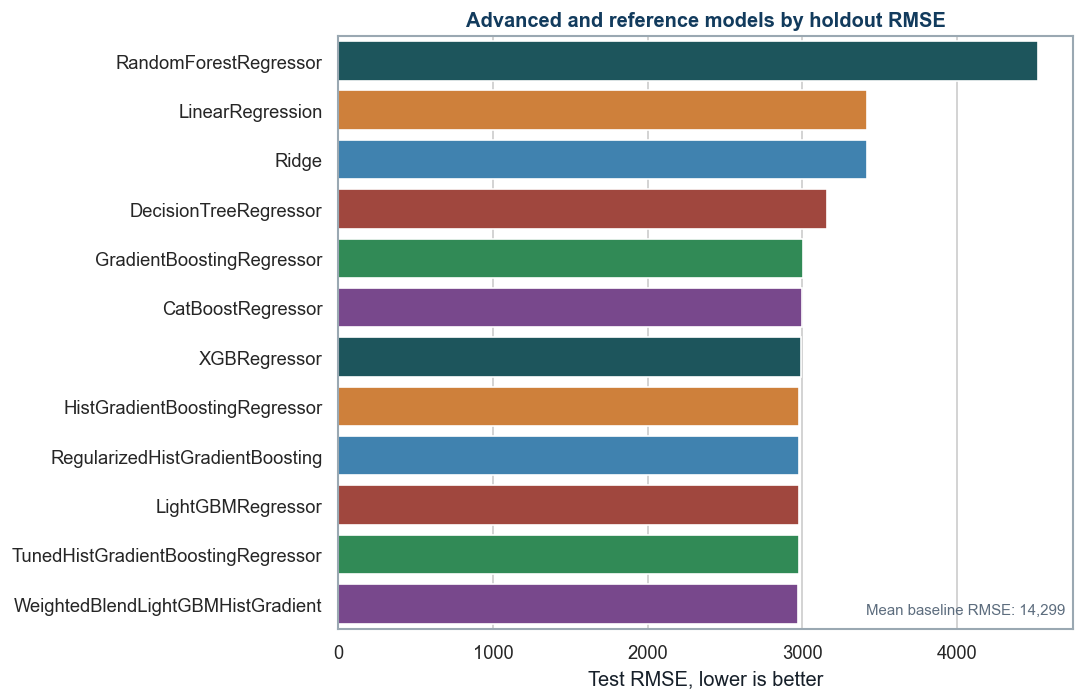

In [12]:
portable_blend = VotingRegressor(
    estimators=[
        (
            "lightgbm",
            make_pipeline(
                LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.03,
                    num_leaves=24,
                    min_child_samples=30,
                    subsample=0.90,
                    colsample_bytree=0.85,
                    reg_lambda=0.30,
                    reg_alpha=0.02,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                )
            ),
        ),
        (
            "hist_gradient",
            make_pipeline(
                HistGradientBoostingRegressor(
                    max_iter=600,
                    learning_rate=0.035,
                    max_leaf_nodes=31,
                    min_samples_leaf=35,
                    l2_regularization=0.05,
                    max_bins=255,
                    random_state=RANDOM_STATE,
                )
            ),
        ),
    ],
    weights=[0.50, 0.50],
)
blend_row, portable_blend = fit_and_evaluate(
    "WeightedBlendLightGBMHistGradient",
    portable_blend,
)
fitted_models["WeightedBlendLightGBMHistGradient"] = portable_blend
metrics = pd.concat([metrics, pd.DataFrame([blend_row])], ignore_index=True)
metrics = metrics.sort_values(["cv_RMSE_mean", "cv_MAE_mean"]).reset_index(drop=True)

display(
    metrics[
        [
            "model",
            "cv_RMSE_mean",
            "cv_RMSE_std",
            "train_MAE",
            "train_RMSE",
            "train_R2",
            "test_MAE",
            "test_RMSE",
            "test_R2",
            "train_test_RMSE_gap",
        ]
    ].round(3)
)

plt.figure(figsize=(9.2, 6.0))
baseline_rmse = metrics.loc[
    metrics["model"] == "DummyRegressor",
    "test_RMSE",
].iloc[0]
ordered = (
    metrics.loc[metrics["model"] != "DummyRegressor"]
    .sort_values("test_RMSE", ascending=False)
)
sns.barplot(
    data=ordered,
    x="test_RMSE",
    y="model",
    hue="model",
    palette=sns.color_palette(COLORS, n_colors=len(ordered)),
    legend=False,
)
plt.text(
    0.99,
    0.02,
    f"Mean baseline RMSE: {baseline_rmse:,.0f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="#5D6D7E",
)
plt.title("Advanced and reference models by holdout RMSE")
plt.xlabel("Test RMSE, lower is better")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_rmse.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "model_comparison_rmse.png"),
        alt="Holdout RMSE comparison for all evaluated regression models.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>WeightedBlendLightGBMHistGradient is a VotingRegressor with equal 0.50 weights for LightGBM and regularized Histogram Gradient Boosting. The final prediction is the arithmetic mean of their two cost estimates.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Blending can reduce dependence on one algorithm's errors, but it is selected only if repeated validation supports the extra operational complexity of running both models.</span>
  </div>
</div>

## 13. Repeated Target-stratified Cross-validation

Repeated validation for WeightedBlendLightGBMHistGradient...


Repeated validation for TunedHistGradientBoostingRegressor...


Repeated validation for RegularizedHistGradientBoosting...


Repeated validation for HistGradientBoostingRegressor...


Repeated validation for LightGBMRegressor...


Repeated validation for XGBRegressor...


,model,repeated_cv_RMSE_mean,repeated_cv_RMSE_std,repeated_cv_MAE_mean,repeated_cv_MAE_std,repeated_cv_R2_mean,folds,repeats
0,WeightedBlendLightGBMHistGradient,2949.563,13.803,2363.934,14.388,0.958,3,2
1,TunedHistGradientBoostingRegressor,2953.152,12.502,2369.670,17.905,0.958,3,2
2,HistGradientBoostingRegressor,2954.593,11.138,2367.019,15.405,0.957,3,2
3,RegularizedHistGradientBoosting,2954.868,11.554,2368.591,15.875,0.957,3,2
4,LightGBMRegressor,2965.690,16.605,2375.328,14.513,0.957,3,2
5,XGBRegressor,2969.848,16.297,2384.699,16.049,0.957,3,2


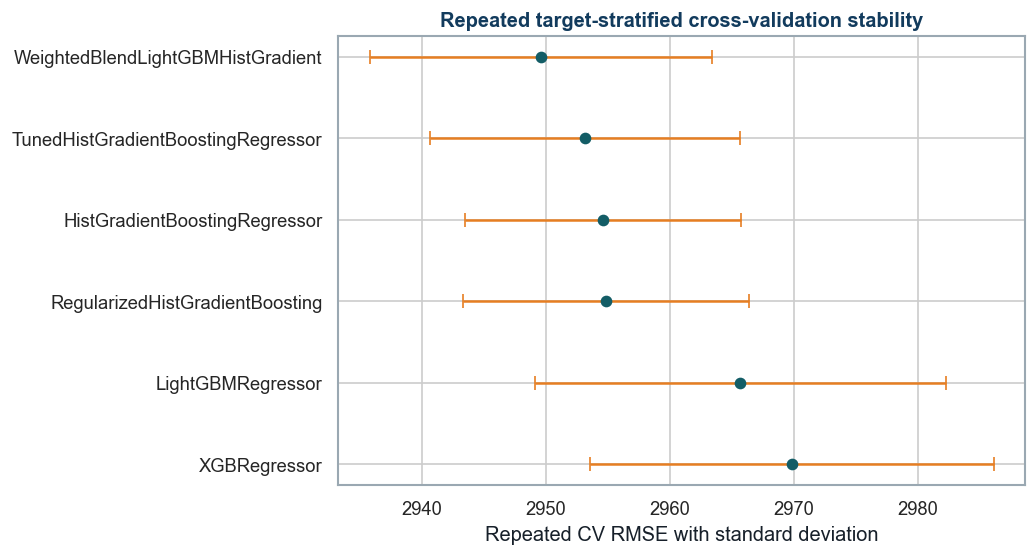

In [13]:
repeated_splitter = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=2,
    random_state=RANDOM_STATE,
)
repeated_splits = list(repeated_splitter.split(X_train, train_strata))
leading_names = metrics.nsmallest(6, "cv_RMSE_mean")["model"].tolist()

repeated_rows = []
for name in leading_names:
    print(f"Repeated validation for {name}...")
    result = cross_validate(
        fitted_models[name],
        X_train,
        y_train,
        cv=repeated_splits,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    repeated_rows.append(
        {
            "model": name,
            "repeated_cv_RMSE_mean": -float(result["test_rmse"].mean()),
            "repeated_cv_RMSE_std": float(result["test_rmse"].std()),
            "repeated_cv_MAE_mean": -float(result["test_mae"].mean()),
            "repeated_cv_MAE_std": float(result["test_mae"].std()),
            "repeated_cv_R2_mean": float(result["test_r2"].mean()),
            "folds": 3,
            "repeats": 2,
        }
    )

repeated_cv = (
    pd.DataFrame(repeated_rows)
    .sort_values(["repeated_cv_RMSE_mean", "repeated_cv_MAE_mean"])
    .reset_index(drop=True)
)
repeated_cv.to_csv(TABLE_DIR / "repeated_cv_metrics.csv", index=False)
repeated_cv.to_csv(MODEL_DIR / "repeated_cv_metrics.csv", index=False)
display(repeated_cv.round(3))

plt.figure(figsize=(8.8, 4.8))
plot_repeated = repeated_cv.sort_values("repeated_cv_RMSE_mean", ascending=False)
plt.errorbar(
    plot_repeated["repeated_cv_RMSE_mean"],
    plot_repeated["model"],
    xerr=plot_repeated["repeated_cv_RMSE_std"],
    fmt="o",
    color=COLORS[0],
    ecolor=COLORS[1],
    capsize=4,
)
plt.title("Repeated target-stratified cross-validation stability")
plt.xlabel("Repeated CV RMSE with standard deviation")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "repeated_cv_stability.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "repeated_cv_stability.png"),
        alt="Repeated cross-validation RMSE means and variability for leading models.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The six leading candidates are re-evaluated over six target-stratified folds. The mean reflects expected validation error and the standard deviation shows stability across repeated partitions.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>A stable model is less likely to produce a misleadingly strong result from one favorable split.</span>
  </div>
</div>

## 14. Final Model Comparison and Selection

,0
selected_model,WeightedBlendLightGBMHistGradient
selection_basis,Lowest repeated target-stratified CV RMSE
best_test_model,WeightedBlendLightGBMHistGradient
selected_train_MAE,2204.625103
selected_train_RMSE,2745.33027
selected_train_R2,0.963295
selected_test_MAE,2385.187905
selected_test_RMSE,2971.905225
selected_test_R2,0.9568
selected_test_MAPE,11.457903


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,train_MAPE,test_MAPE,train_SMAPE,test_SMAPE,train_test_RMSE_gap,selected_final_model
0,WeightedBlendLightGBMHistGradient,2204.625,2385.188,2745.330,2971.905,0.963,0.957,10.742,11.458,10.419,11.109,226.575,True
1,TunedHistGradientBoostingRegressor,2280.892,2394.421,2840.128,2979.111,0.961,0.957,11.112,11.555,10.765,11.189,138.983,False
2,LightGBMRegressor,2170.233,2391.451,2704.342,2979.652,0.964,0.957,10.561,11.459,10.256,11.121,275.310,False
3,RegularizedHistGradientBoosting,2250.163,2391.266,2802.340,2980.141,0.962,0.957,10.985,11.528,10.640,11.163,177.800,False
4,HistGradientBoostingRegressor,2262.998,2393.569,2817.776,2982.495,0.961,0.956,11.095,11.569,10.730,11.188,164.719,False
5,XGBRegressor,2234.839,2408.403,2782.062,2992.811,0.962,0.956,10.836,11.554,10.524,11.223,210.750,False
6,CatBoostRegressor,2264.826,2416.286,2818.373,3001.441,0.961,0.956,10.930,11.562,10.617,11.223,183.069,False
7,GradientBoostingRegressor,2339.908,2421.751,2909.319,3007.160,0.959,0.956,11.326,11.634,10.992,11.282,97.841,False
8,DecisionTreeRegressor,2179.540,2492.437,2753.829,3162.425,0.963,0.951,10.426,11.797,10.127,11.430,408.596,False
9,Ridge,2681.845,2760.441,3331.988,3416.711,0.946,0.943,15.005,15.445,15.699,16.042,84.723,False


,reader-friendly name,model,selection_status,cv_RMSE_mean,repeated_cv_RMSE_mean,test_MAE,test_RMSE,test_R2
0,50/50 weighted blend,WeightedBlendLightGBMHistGradient,"BEST, recommended",2949.831,2949.563,2385.188,2971.905,0.957
1,Tuned Histogram Gradient Boosting,TunedHistGradientBoostingRegressor,Challenger,2951.964,2953.152,2394.421,2979.111,0.957
2,Regularized Histogram Gradient Boosting,RegularizedHistGradientBoosting,Challenger,2955.214,2954.868,2391.266,2980.141,0.957
3,Histogram Gradient Boosting,HistGradientBoostingRegressor,Challenger,2955.377,2954.593,2393.569,2982.495,0.956
4,LightGBM,LightGBMRegressor,Challenger,2966.229,2965.690,2391.451,2979.652,0.957
5,XGBoost,XGBRegressor,Challenger,2968.108,2969.848,2408.403,2992.811,0.956
6,Gradient boosting,GradientBoostingRegressor,Challenger,2970.467,NaN,2421.751,3007.160,0.956
7,CatBoost,CatBoostRegressor,Challenger,2972.209,NaN,2416.286,3001.441,0.956
8,Decision tree,DecisionTreeRegressor,Challenger,3159.937,NaN,2492.437,3162.425,0.951
9,Regularized linear regression,Ridge,Challenger,3340.823,NaN,2760.441,3416.711,0.943


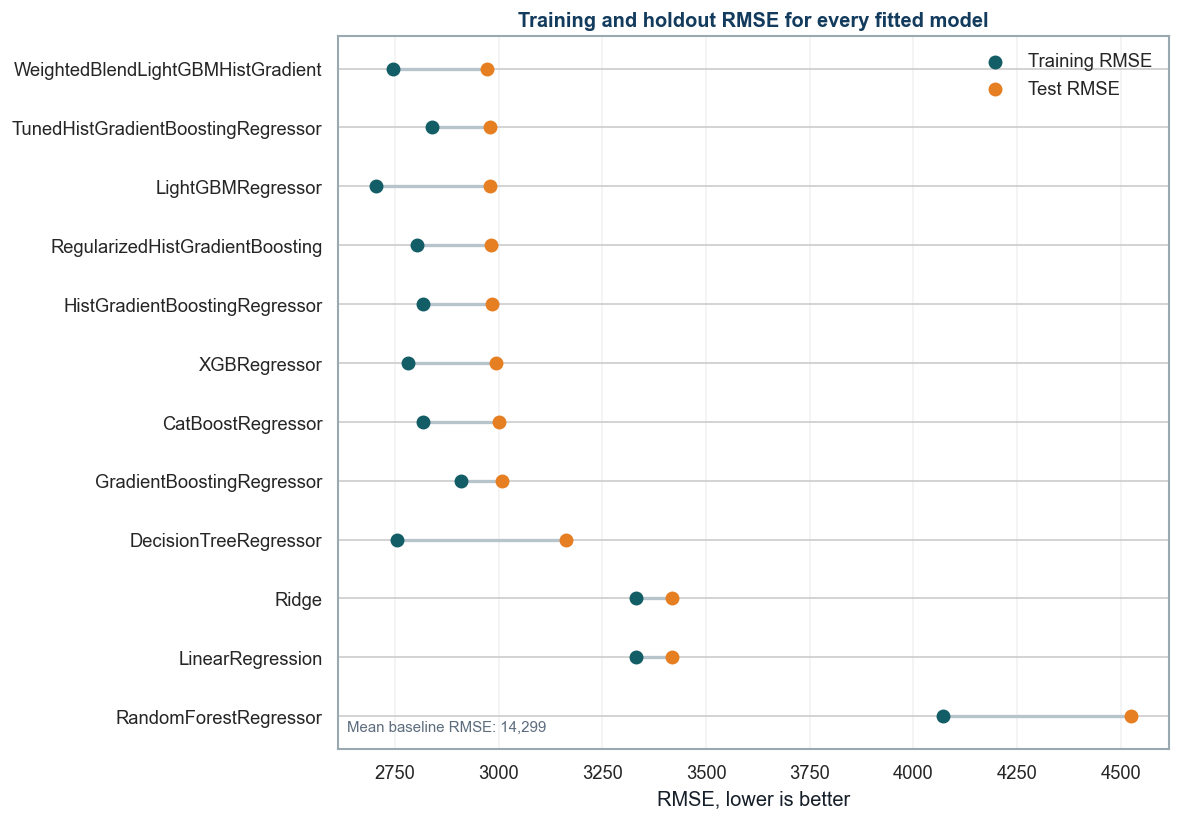

WeightedBlendLightGBMHistGradient achieved the lowest repeated target-stratified CV RMSE (2949.56, standard deviation 13.80) among the leading candidates. Holdout metrics are reported for rubric comparison. The selection code uses only repeated training-fold cross-validation and does not rank candidates by test performance.


In [14]:
repeated_winner = repeated_cv.iloc[0]
final_model_name = str(repeated_winner["model"])
final_model = fitted_models[final_model_name]

metrics["selected_final_model"] = metrics["model"].eq(final_model_name)
metrics = metrics.sort_values(["test_RMSE", "test_MAE"]).reset_index(drop=True)
selected_metrics = metrics.loc[metrics["selected_final_model"]].iloc[0]
best_test_metrics = metrics.sort_values(["test_RMSE", "test_MAE"]).iloc[0]

selection_reason = (
    f"{final_model_name} achieved the lowest repeated target-stratified CV RMSE "
    f"({repeated_winner['repeated_cv_RMSE_mean']:.2f}, standard deviation "
    f"{repeated_winner['repeated_cv_RMSE_std']:.2f}) among the leading candidates. "
    "Holdout metrics are reported for rubric comparison. The selection code uses "
    "only repeated training-fold cross-validation and does not rank candidates by "
    "test performance."
)

final_summary = pd.DataFrame(
    [
        {
            "selected_model": final_model_name,
            "selection_basis": "Lowest repeated target-stratified CV RMSE",
            "best_test_model": str(best_test_metrics["model"]),
            "selected_train_MAE": selected_metrics["train_MAE"],
            "selected_train_RMSE": selected_metrics["train_RMSE"],
            "selected_train_R2": selected_metrics["train_R2"],
            "selected_test_MAE": selected_metrics["test_MAE"],
            "selected_test_RMSE": selected_metrics["test_RMSE"],
            "selected_test_R2": selected_metrics["test_R2"],
            "selected_test_MAPE": selected_metrics["test_MAPE"],
            "selected_test_SMAPE": selected_metrics["test_SMAPE"],
            "selected_train_test_RMSE_gap": selected_metrics["train_test_RMSE_gap"],
            "best_test_RMSE": best_test_metrics["test_RMSE"],
            "selection_reason": selection_reason,
        }
    ]
)
train_test_evaluation = (
    metrics[
        [
            "model",
            "train_MAE",
            "test_MAE",
            "train_RMSE",
            "test_RMSE",
            "train_R2",
            "test_R2",
            "train_MAPE",
            "test_MAPE",
            "train_SMAPE",
            "test_SMAPE",
            "train_test_RMSE_gap",
            "selected_final_model",
        ]
    ]
    .sort_values(["test_RMSE", "test_MAE"])
    .reset_index(drop=True)
)
metrics.to_csv(TABLE_DIR / "model_metrics.csv", index=False)
metrics.to_csv(MODEL_DIR / "model_metrics.csv", index=False)
train_test_evaluation.to_csv(
    TABLE_DIR / "train_test_model_evaluation.csv",
    index=False,
)
train_test_evaluation.to_csv(
    MODEL_DIR / "train_test_model_evaluation.csv",
    index=False,
)
final_summary.to_csv(TABLE_DIR / "final_model_summary.csv", index=False)
final_summary.to_csv(MODEL_DIR / "final_model_summary.csv", index=False)

candidate_model_dir = MODEL_DIR / "candidate_models"
candidate_model_dir.mkdir(parents=True, exist_ok=True)
candidate_artifact_paths = []
candidate_artifact_map = {}
for candidate_name, candidate_model in fitted_models.items():
    if candidate_name == final_model_name:
        artifact_path = MODEL_DIR / "final_model.pkl"
    else:
        artifact_path = candidate_model_dir / f"{candidate_name}.pkl"
    joblib.dump(candidate_model, artifact_path)
    candidate_artifact_paths.append(artifact_path)
    candidate_artifact_map[candidate_name] = (
        artifact_path.relative_to(ROOT).as_posix()
    )

manifest_guide = model_reference_guide.rename(
    columns={"output name": "model"}
)
candidate_model_manifest = (
    metrics.merge(
        repeated_cv,
        on="model",
        how="left",
        validate="one_to_one",
    )
    .merge(
        manifest_guide,
        on="model",
        how="left",
        validate="one_to_one",
    )
)
candidate_model_manifest["artifact_path"] = (
    candidate_model_manifest["model"].map(candidate_artifact_map)
)
candidate_model_manifest["initial_cv_RMSE_rank"] = (
    candidate_model_manifest["cv_RMSE_mean"]
    .rank(method="min")
    .astype(int)
)
candidate_model_manifest["repeated_cv_RMSE_rank"] = (
    candidate_model_manifest["repeated_cv_RMSE_mean"]
    .rank(method="min")
    .astype("Int64")
)
candidate_model_manifest["holdout_RMSE_rank"] = (
    candidate_model_manifest["test_RMSE"]
    .rank(method="min")
    .astype(int)
)
candidate_model_manifest["selection_status"] = np.where(
    candidate_model_manifest["selected_final_model"],
    "BEST, recommended",
    "Challenger",
)
candidate_model_manifest["selector_order"] = np.where(
    candidate_model_manifest["selected_final_model"],
    0,
    candidate_model_manifest["initial_cv_RMSE_rank"] + 1,
)
candidate_model_manifest["selection_note"] = np.where(
    candidate_model_manifest["selected_final_model"],
    selection_reason,
    (
        "Available for comparison. It was not selected as the best model "
        "under the repeated target-stratified CV rule."
    ),
)
candidate_model_manifest = candidate_model_manifest.sort_values(
    ["selector_order", "cv_RMSE_mean", "model"]
).reset_index(drop=True)
candidate_model_manifest.to_csv(
    MODEL_DIR / "candidate_model_manifest.csv",
    index=False,
)
candidate_model_manifest.to_csv(
    TABLE_DIR / "candidate_model_manifest.csv",
    index=False,
)

display(final_summary.T)
display(train_test_evaluation.round(3))
display(
    candidate_model_manifest[
        [
            "reader-friendly name",
            "model",
            "selection_status",
            "cv_RMSE_mean",
            "repeated_cv_RMSE_mean",
            "test_MAE",
            "test_RMSE",
            "test_R2",
        ]
    ].round(3)
)

train_test_plot = train_test_evaluation.loc[
    train_test_evaluation["model"] != "DummyRegressor"
].sort_values("test_RMSE", ascending=False)
y_positions = np.arange(len(train_test_plot))
figure, axis = plt.subplots(figsize=(10.0, 7.0))
axis.hlines(
    y_positions,
    train_test_plot["train_RMSE"],
    train_test_plot["test_RMSE"],
    color="#B8C4CC",
    linewidth=2,
)
axis.scatter(
    train_test_plot["train_RMSE"],
    y_positions,
    s=54,
    color=COLORS[0],
    label="Training RMSE",
    zorder=3,
)
axis.scatter(
    train_test_plot["test_RMSE"],
    y_positions,
    s=54,
    color=COLORS[1],
    label="Test RMSE",
    zorder=3,
)
axis.set_yticks(y_positions)
axis.set_yticklabels(train_test_plot["model"])
axis.set_xlabel("RMSE, lower is better")
axis.set_ylabel("")
axis.set_title("Training and holdout RMSE for every fitted model")
axis.legend(frameon=False, loc="upper right")
axis.grid(axis="x", alpha=0.25)
axis.text(
    0.01,
    0.02,
    (
        "Mean baseline RMSE: "
        f"{metrics.loc[metrics['model'] == 'DummyRegressor', 'test_RMSE'].iloc[0]:,.0f}"
    ),
    transform=axis.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    color="#5D6D7E",
)
figure.tight_layout()
figure.savefig(FIG_DIR / "train_test_rmse_comparison.png")
plt.close(figure)
display(
    Image(
        filename=str(FIG_DIR / "train_test_rmse_comparison.png"),
        alt="Training and holdout RMSE comparison for all fitted models except the mean baseline.",
    )
)
print(selection_reason)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The saved comparison presents MAE, RMSE, R2, MAPE, and SMAPE on both training and holdout data for every model. The candidate manifest serializes every fitted regression pipeline for app comparison. WeightedBlendLightGBMHistGradient remains marked BEST because selection ranks the leading candidates only by repeated training-fold cross-validation.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The app can compare alternative models without obscuring the recommended model. Final-model-only evidence such as OOF uncertainty, portfolio percentile, fairness results, and exact blend SHAP remains attached only to the selected blend.</span>
  </div>
</div>

## 15. Calibration and Valid Quote-band Evaluation

Calibration is a post-model adjustment learned on a training-only calibration
subset. Isotonic regression learns a monotonic mapping from raw predictions to
observed costs. It can correct systematic underprediction or overprediction,
but it is retained only when the chosen evaluation metrics improve.

In [15]:
def nearest_band(values, levels):
    values_array = np.asarray(values, dtype=float)
    levels_array = np.asarray(levels, dtype=float)
    distances = np.abs(values_array[:, None] - levels_array[None, :])
    return levels_array[np.argmin(distances, axis=1)]


def band_distance(values, actual, levels):
    rounded = nearest_band(values, levels)
    actual_rounded = nearest_band(actual, levels)
    lookup = {level: index for index, level in enumerate(levels)}
    predicted_index = np.array([lookup[value] for value in rounded])
    actual_index = np.array([lookup[value] for value in actual_rounded])
    return np.abs(predicted_index - actual_index)


def evaluate_variant(name, actual, predicted):
    row = {"variant": name, **regression_metrics(actual, predicted)}
    distance = band_distance(predicted, actual, target_levels)
    row.update(
        {
            "exact_band_accuracy": float(np.mean(distance == 0)),
            "within_1_band_accuracy": float(np.mean(distance <= 1)),
            "within_2_band_accuracy": float(np.mean(distance <= 2)),
            "within_3_band_accuracy": float(np.mean(distance <= 3)),
        }
    )
    return row


prediction_variant_guide = pd.DataFrame(
    [
        [
            "raw_continuous",
            "The selected regression model's original numeric cost estimate.",
            "Primary analytical estimate",
        ],
        [
            "calibrated_continuous",
            "The raw estimate after isotonic calibration.",
            "Secondary diagnostic because MAE and RMSE did not improve",
        ],
        [
            "rounded_to_nearest_price_band",
            "The raw estimate moved to the closest one of 54 valid quote bands.",
            "Business quote-band display",
        ],
        [
            "calibrated_then_rounded",
            "The calibrated estimate moved to the nearest valid quote band.",
            "Comparison only",
        ],
        [
            "ordinal_predicted_class",
            "The single quote band with the highest classifier probability.",
            "Hard-class challenger",
        ],
        [
            "ordinal_expected_value",
            "Probability-weighted average of all quote-band costs.",
            "Smoother classifier-based cost challenger",
        ],
    ],
    columns=["output label", "plain-language meaning", "role"],
)
prediction_variant_guide.to_csv(
    TABLE_DIR / "prediction_variant_guide.csv",
    index=False,
)
display(prediction_variant_guide.iloc[:4])

inner_strata = y_train.astype(int).astype(str)
X_inner, X_calibration, y_inner, y_calibration = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=inner_strata,
)
calibration_model = clone(final_model)
calibration_model.fit(X_inner, y_inner)
calibration_prediction = calibration_model.predict(X_calibration)
isotonic = IsotonicRegression(out_of_bounds="clip")
isotonic.fit(calibration_prediction, y_calibration)

raw_test_prediction = final_model.predict(X_test)
calibrated_test_prediction = isotonic.predict(raw_test_prediction)
rounded_raw_prediction = nearest_band(raw_test_prediction, target_levels)
calibrated_rounded_prediction = nearest_band(
    calibrated_test_prediction,
    target_levels,
)

price_grid_evaluation = pd.DataFrame(
    [
        evaluate_variant("raw_continuous", y_test, raw_test_prediction),
        evaluate_variant(
            "calibrated_continuous",
            y_test,
            calibrated_test_prediction,
        ),
        evaluate_variant(
            "rounded_to_nearest_price_band",
            y_test,
            rounded_raw_prediction,
        ),
        evaluate_variant(
            "calibrated_then_rounded",
            y_test,
            calibrated_rounded_prediction,
        ),
    ]
)
raw_rmse = float(
    price_grid_evaluation.loc[
        price_grid_evaluation["variant"] == "raw_continuous",
        "RMSE",
    ].iloc[0]
)
raw_mae = float(
    price_grid_evaluation.loc[
        price_grid_evaluation["variant"] == "raw_continuous",
        "MAE",
    ].iloc[0]
)
price_grid_evaluation["RMSE_delta_vs_raw"] = (
    price_grid_evaluation["RMSE"] - raw_rmse
)
price_grid_evaluation["MAE_delta_vs_raw"] = (
    price_grid_evaluation["MAE"] - raw_mae
)
price_grid_evaluation.to_csv(
    TABLE_DIR / "price_grid_evaluation.csv",
    index=False,
)
price_grid_evaluation.to_csv(
    MODEL_DIR / "price_grid_evaluation.csv",
    index=False,
)
price_grid_evaluation.to_csv(
    MODEL_DIR / "calibration_comparison.csv",
    index=False,
)
joblib.dump(
    {"calibrator": isotonic, "source_model": final_model_name},
    MODEL_DIR / "prediction_calibrator.pkl",
)
display(price_grid_evaluation.round(4))

,output label,plain-language meaning,role
0,raw_continuous,The selected regression model's original numeric cost estimate.,Primary analytical estimate
1,calibrated_continuous,The raw estimate after isotonic calibration.,Secondary diagnostic because MAE and RMSE did not improve
2,rounded_to_nearest_price_band,The raw estimate moved to the closest one of 54 valid quote bands.,Business quote-band display
3,calibrated_then_rounded,The calibrated estimate moved to the nearest valid quote band.,Comparison only


,variant,MAE,RMSE,R2,MAPE,SMAPE,exact_band_accuracy,within_1_band_accuracy,within_2_band_accuracy,within_3_band_accuracy,RMSE_delta_vs_raw,MAE_delta_vs_raw
0,raw_continuous,2385.1879,2971.9052,0.9568,11.4579,11.1088,0.1658,0.4594,0.6972,0.8484,0.0000,0.0000
1,calibrated_continuous,2398.8817,2995.8131,0.9561,11.5089,11.1253,0.1696,0.4580,0.6916,0.8500,23.9078,13.6938
2,rounded_to_nearest_price_band,2368.0460,2998.2391,0.9560,11.3183,10.9523,0.1658,0.4594,0.6972,0.8484,26.3339,-17.1419
3,calibrated_then_rounded,2378.1648,3020.6546,0.9554,11.3662,10.9323,0.1696,0.4580,0.6916,0.8500,48.7493,-7.0231


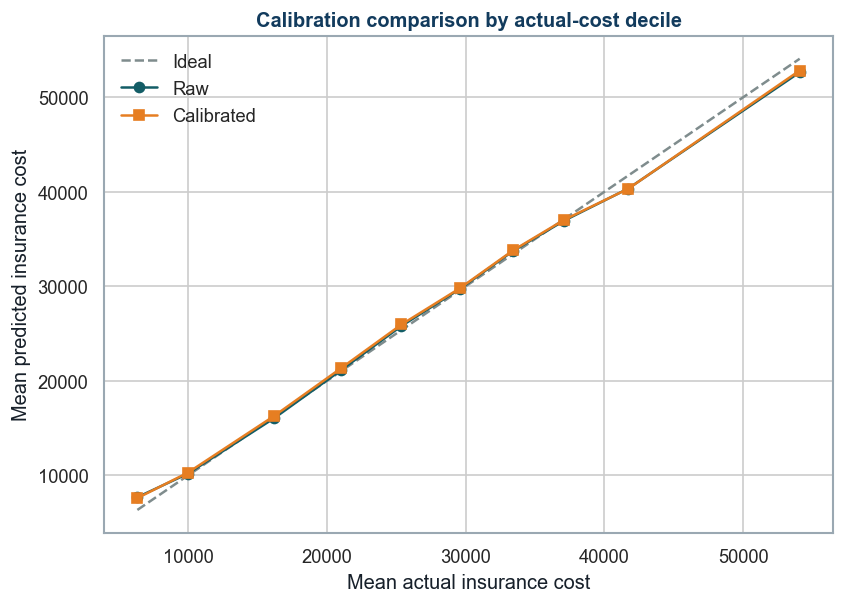

In [16]:
calibration_plot = pd.DataFrame(
    {
        "actual": np.asarray(y_test),
        "raw": raw_test_prediction,
        "calibrated": calibrated_test_prediction,
    }
)
calibration_plot["actual_bin"] = pd.qcut(
    calibration_plot["actual"],
    q=10,
    duplicates="drop",
)
curve_points = (
    calibration_plot.groupby("actual_bin", observed=True)
    .agg(
        mean_actual=("actual", "mean"),
        raw_prediction=("raw", "mean"),
        calibrated_prediction=("calibrated", "mean"),
    )
    .reset_index(drop=True)
)
curve_points.to_csv(TABLE_DIR / "calibration_curve_points.csv", index=False)

plt.figure(figsize=(7.2, 5.2))
limits = [
    float(curve_points["mean_actual"].min()),
    float(curve_points["mean_actual"].max()),
]
plt.plot(limits, limits, "--", color="#7F8C8D", label="Ideal")
plt.plot(
    curve_points["mean_actual"],
    curve_points["raw_prediction"],
    marker="o",
    color=COLORS[0],
    label="Raw",
)
plt.plot(
    curve_points["mean_actual"],
    curve_points["calibrated_prediction"],
    marker="s",
    color=COLORS[1],
    label="Calibrated",
)
plt.title("Calibration comparison by actual-cost decile")
plt.xlabel("Mean actual insurance cost")
plt.ylabel("Mean predicted insurance cost")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "calibration_curve.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "calibration_curve.png"),
        alt="Raw and calibrated mean predictions compared with actual cost deciles.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>Calibration and quote-band rounding are evaluated as separate deployment variants. The table shows whether each transformation improves or worsens MAE and RMSE relative to the raw continuous estimate.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The app should display the raw analytical estimate and use rounded raw prediction for the nearest valid quote band unless a different business metric justifies calibration.</span>
  </div>
</div>

## 16. Ordinal-style Quote-band Classification Challenger

This challenger converts each of the 54 quote bands into a class label. The
classifier predicts a probability for every band. A hard prediction selects the
most likely band, while the expected-value prediction multiplies each band cost
by its probability and adds the results.

The approach is described as ordinal-style because the classes correspond to
ordered prices. The multiclass Histogram Gradient Boosting loss still treats the
class labels as separate categories, so this is not a specialized ordinal-loss
algorithm.

In [17]:
band_lookup = {level: index for index, level in enumerate(target_levels)}
y_train_band = y_train.astype(int).map(band_lookup).astype(int)

ordinal_model = Pipeline(
    steps=[
        ("preprocess", make_preprocessor()),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=100,
                learning_rate=0.08,
                max_leaf_nodes=15,
                min_samples_leaf=40,
                l2_regularization=0.10,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
ordinal_model.fit(X_train, y_train_band)
predicted_band_index = ordinal_model.predict(X_test).astype(int)
predicted_band_cost = target_levels[predicted_band_index]
probabilities = ordinal_model.predict_proba(X_test)
expected_band_cost = probabilities @ target_levels.astype(float)

ordinal_metrics = pd.DataFrame(
    [
        {
            **evaluate_variant(
                "ordinal_predicted_class",
                y_test,
                predicted_band_cost,
            ),
            "model": "HistGradientBoostingClassifier",
        },
        {
            **evaluate_variant(
                "ordinal_expected_value",
                y_test,
                expected_band_cost,
            ),
            "model": "HistGradientBoostingClassifier",
        },
    ]
)
ordinal_metrics.to_csv(
    TABLE_DIR / "ordinal_challenger_metrics.csv",
    index=False,
)
ordinal_metrics.to_csv(
    MODEL_DIR / "ordinal_challenger_metrics.csv",
    index=False,
)
display(ordinal_metrics.round(4))

,variant,MAE,RMSE,R2,MAPE,SMAPE,exact_band_accuracy,within_1_band_accuracy,within_2_band_accuracy,within_3_band_accuracy,model
0,ordinal_predicted_class,2782.9168,3680.9622,0.9337,12.6203,12.8001,0.1782,0.4418,0.6298,0.7682,HistGradientBoostingClassifier
1,ordinal_expected_value,2442.0935,3067.9812,0.9540,11.8148,11.3571,0.1656,0.4546,0.6848,0.8414,HistGradientBoostingClassifier


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>HistGradientBoostingClassifier predicts one of the 54 quote bands and also converts its class probabilities to an expected cost. Both outputs are compared with regression using the same monetary and band metrics.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>A discrete classifier is useful only if quote-band accuracy improves enough to justify its weaker or stronger monetary error. The regression model remains primary unless that evidence changes.</span>
  </div>
</div>

## 17. Holdout Diagnostics and Segment-level Error

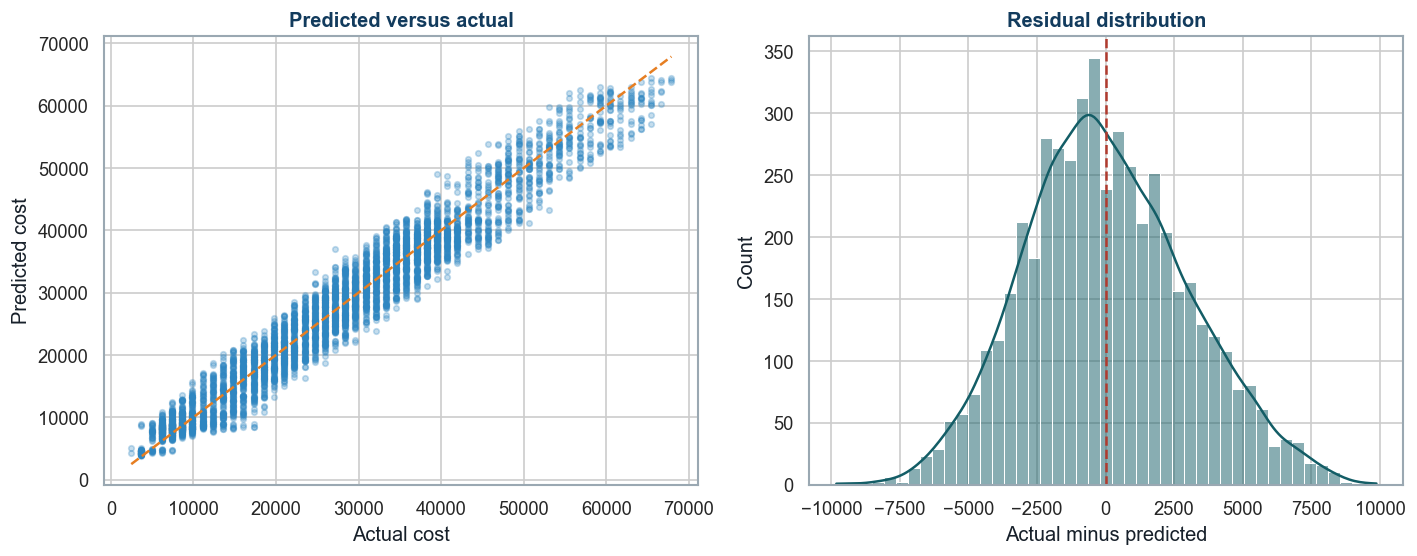

In [18]:
diagnostic = X_test.copy()
diagnostic["actual_cost"] = np.asarray(y_test)
diagnostic["predicted_cost"] = raw_test_prediction
diagnostic["residual"] = diagnostic["actual_cost"] - diagnostic["predicted_cost"]
diagnostic["absolute_error"] = diagnostic["residual"].abs()
diagnostic["actual_cost_decile"] = pd.qcut(
    diagnostic["actual_cost"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)],
    duplicates="drop",
)

residual_deciles = (
    diagnostic.groupby("actual_cost_decile", observed=True)
    .agg(
        records=("actual_cost", "size"),
        mean_actual=("actual_cost", "mean"),
        mean_prediction=("predicted_cost", "mean"),
        mean_residual=("residual", "mean"),
        MAE=("absolute_error", "mean"),
    )
    .reset_index()
)
residual_deciles["RMSE"] = (
    diagnostic.assign(squared_error=diagnostic["residual"] ** 2)
    .groupby("actual_cost_decile", observed=True)["squared_error"]
    .mean()
    .pow(0.5)
    .values
)
residual_deciles.to_csv(
    TABLE_DIR / "residual_by_cost_decile.csv",
    index=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
axes[0].scatter(
    diagnostic["actual_cost"],
    diagnostic["predicted_cost"],
    s=11,
    alpha=0.28,
    color=COLORS[2],
)
limits = [
    min(diagnostic["actual_cost"].min(), diagnostic["predicted_cost"].min()),
    max(diagnostic["actual_cost"].max(), diagnostic["predicted_cost"].max()),
]
axes[0].plot(limits, limits, "--", color=COLORS[1], linewidth=1.5)
axes[0].set_title("Predicted versus actual")
axes[0].set_xlabel("Actual cost")
axes[0].set_ylabel("Predicted cost")

sns.histplot(
    diagnostic["residual"],
    bins=45,
    kde=True,
    color=COLORS[0],
    ax=axes[1],
)
axes[1].axvline(0, color=COLORS[3], linestyle="--", linewidth=1.5)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Actual minus predicted")
plt.tight_layout()
plt.savefig(FIG_DIR / "prediction_and_residual_diagnostics.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "prediction_and_residual_diagnostics.png"),
        alt="Predicted versus actual insurance cost and the residual distribution.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The predicted-versus-actual plot checks overall alignment, while the residual distribution checks systematic underprediction or overprediction. The decile table localizes error across the premium range.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>High-premium cases with larger absolute errors should receive stronger manual review and monitoring than routine quote bands.</span>
  </div>
</div>

,segment_variable,segment_value,records,MAE,RMSE,mean_residual
1,Gender,Male,3246,2390.870,2976.079,-9.228
0,Gender,Female,1754,2374.672,2964.165,131.265
16,Location,Surat,289,2500.734,3144.698,-45.594
12,Location,Mangalore,359,2467.366,3123.962,276.806
4,Location,Bhubaneswar,362,2487.447,3107.706,155.224
6,Location,Delhi,359,2426.652,3080.223,-128.153
14,Location,Nagpur,351,2507.657,3078.911,33.931
7,Location,Guwahati,338,2444.341,3019.593,-65.548
15,Location,Pune,347,2462.723,2998.704,191.348
8,Location,Jaipur,346,2395.710,2955.258,213.674


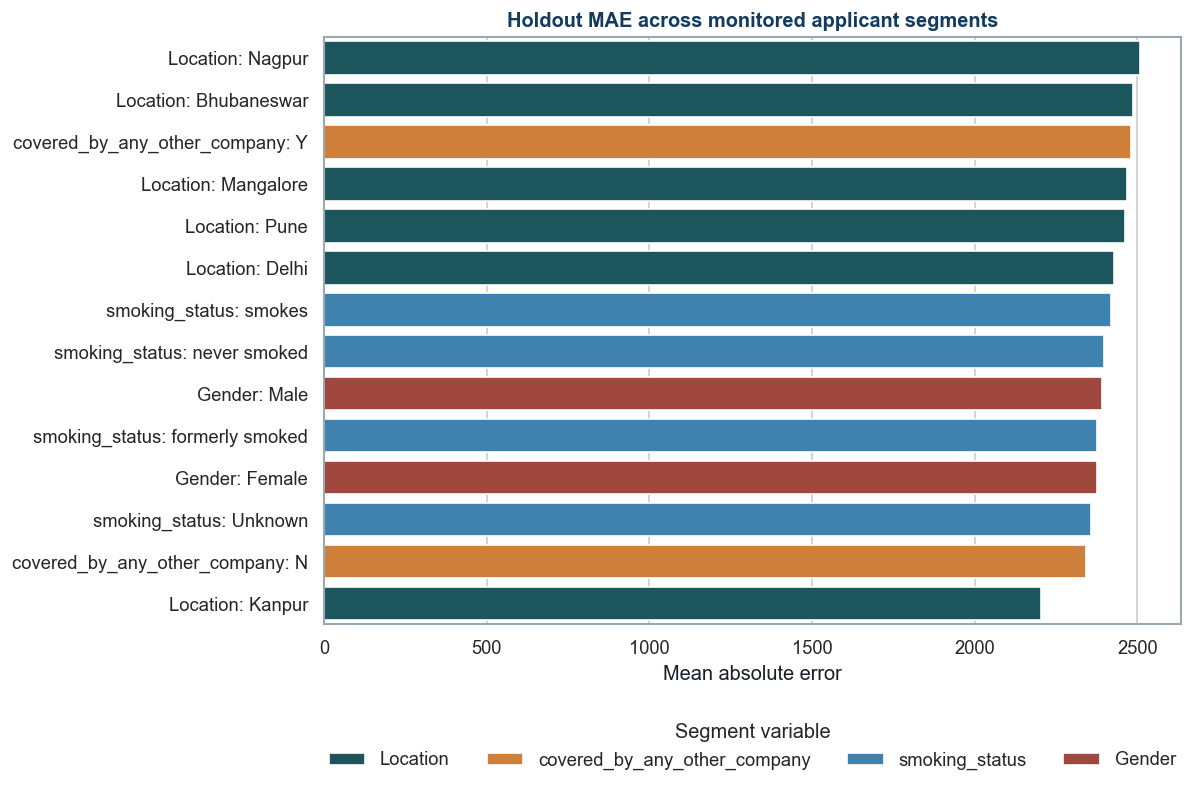

In [19]:
segment_rows = []
for segment_column in [
    "Gender",
    "Location",
    "covered_by_any_other_company",
    "smoking_status",
]:
    for segment_value, group in diagnostic.groupby(segment_column, dropna=False):
        segment_rows.append(
            {
                "segment_variable": segment_column,
                "segment_value": str(segment_value),
                "records": len(group),
                "MAE": float(group["absolute_error"].mean()),
                "RMSE": float(np.sqrt(np.mean(group["residual"] ** 2))),
                "mean_residual": float(group["residual"].mean()),
            }
        )

segment_error = pd.DataFrame(segment_rows).sort_values(
    ["segment_variable", "RMSE"],
    ascending=[True, False],
)
segment_error.to_csv(TABLE_DIR / "fairness_error_summary.csv", index=False)
display(segment_error.round(3))

plot_segments = (
    segment_error.sort_values("records", ascending=False)
    .groupby("segment_variable", group_keys=False)
    .head(6)
    .copy()
)
plot_segments["segment"] = (
    plot_segments["segment_variable"] + ": " + plot_segments["segment_value"]
)
fig, ax = plt.subplots(figsize=(10.5, 7.2))
sns.barplot(
    data=plot_segments.sort_values("MAE", ascending=False),
    x="MAE",
    y="segment",
    hue="segment_variable",
    palette=COLORS[:4],
    ax=ax,
)
ax.set_title("Holdout MAE across monitored applicant segments")
ax.set_xlabel("Mean absolute error")
ax.set_ylabel("")
ax.legend(
    title="Segment variable",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=4,
    frameon=False,
)
fig.subplots_adjust(left=0.30, right=0.98, top=0.92, bottom=0.24)
fig.savefig(FIG_DIR / "segment_error_mae.png")
plt.close(fig)
display(
    Image(
        filename=str(FIG_DIR / "segment_error_mae.png"),
        alt="Holdout mean absolute error across monitored applicant segments.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>Segment-level MAE, RMSE, and mean residual reveal whether model error is uneven across gender, location, coverage, or smoking groups. These are monitoring diagnostics, not proof of fairness.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Pricing teams should review large segment gaps, validate whether protected or proxy variables are permitted, and document any production exclusions with compliance specialists.</span>
  </div>
</div>

## 18. Explainability with Permutation Importance

,feature,importance_mean,importance_std
0,weight,15951.854,180.413
1,Year_last_admitted,301.498,17.380
2,covered_by_any_other_company,158.419,18.427
3,regular_checkup_last_year,112.606,13.681
4,weight_change_in_last_one_year,51.345,5.781
5,years_of_insurance_with_us,43.173,5.094
6,avg_glucose_level,6.250,1.322
7,daily_avg_steps,2.533,3.275
8,Location,1.147,2.150
9,adventure_sports,0.651,0.821


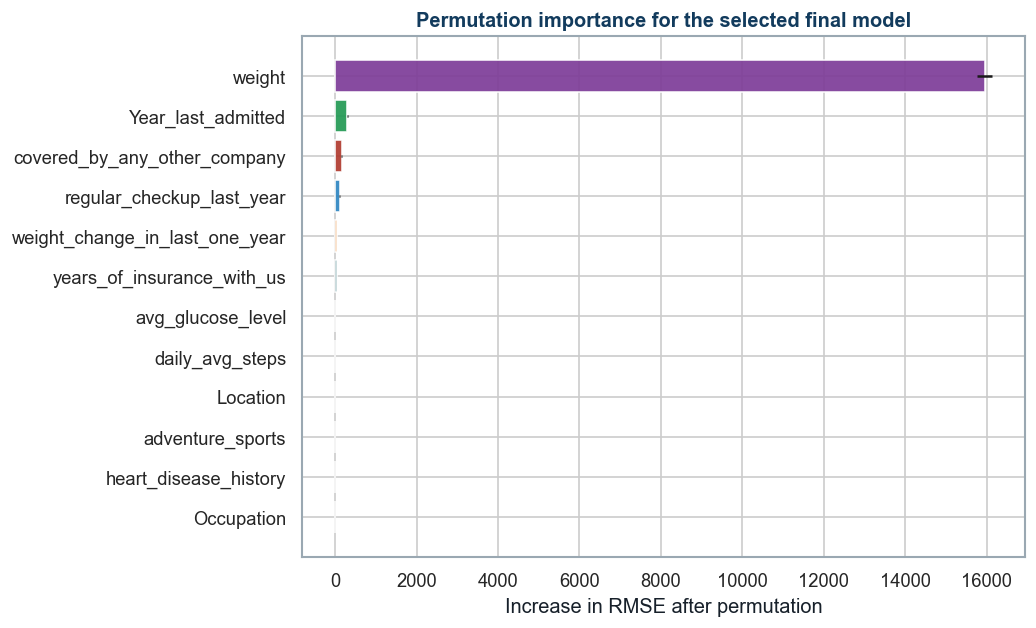

In [20]:
importance_sample = X_test.sample(
    n=min(1500, len(X_test)),
    random_state=RANDOM_STATE,
)
importance_target = y_test.loc[importance_sample.index]
permutation = permutation_importance(
    final_model,
    importance_sample,
    importance_target,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
feature_importance = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": permutation.importances_mean,
            "importance_std": permutation.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
feature_importance.to_csv(TABLE_DIR / "feature_importance.csv", index=False)
feature_importance.to_csv(MODEL_DIR / "feature_importance.csv", index=False)
display(feature_importance.head(15).round(3))

plt.figure(figsize=(8.8, 5.4))
top_importance = feature_importance.head(12).sort_values("importance_mean")
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    color=sns.color_palette(COLORS, n_colors=len(top_importance)),
    alpha=0.92,
)
plt.title("Permutation importance for the selected final model")
plt.xlabel("Increase in RMSE after permutation")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png")
plt.close()
display(
    Image(
        filename=str(FIG_DIR / "feature_importance.png"),
        alt="Permutation importance for the selected insurance-cost model.",
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>Permutation importance measures the increase in holdout RMSE when one raw feature is shuffled. It explains the selected pipeline at the input-column level and remains model-agnostic.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The largest drivers should be checked against pricing policy and monitored for drift. Importance is predictive association, not a causal premium rule.</span>
  </div>
</div>

## 19. SHAP Explanation for the LightGBM Challenger

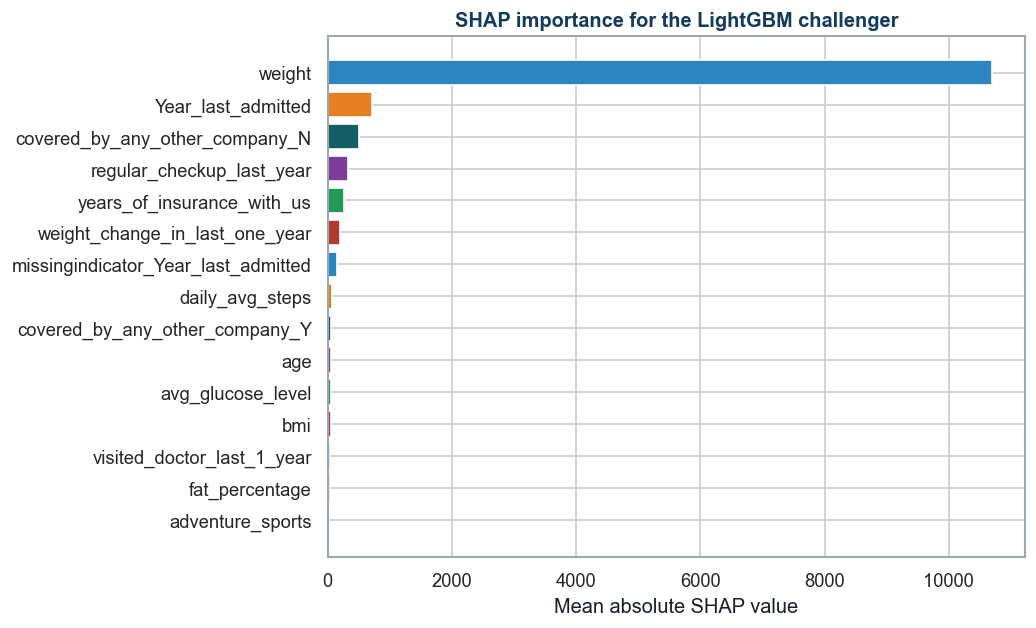

,feature,mean_abs_shap
0,weight,10688.269
1,Year_last_admitted,716.812
2,covered_by_any_other_company_N,503.838
3,regular_checkup_last_year,334.195
4,years_of_insurance_with_us,255.891
5,weight_change_in_last_one_year,197.355
6,missingindicator_Year_last_admitted,144.752
7,daily_avg_steps,61.302
8,covered_by_any_other_company_Y,56.497
9,age,53.538


{'available': True,
 'model': 'LightGBMRegressor',
 'status': 'completed',
 'sample_rows': 500,
 'table': 'outputs/models/shap_importance.csv',
 'figure': 'outputs/figures/shap_importance_bar.png'}

In [21]:
import shap

shap_status = {
    "available": True,
    "model": "LightGBMRegressor",
    "status": "not_started",
}
try:
    shap_pipeline = fitted_models["LightGBMRegressor"]
    shap_preprocessor = shap_pipeline.named_steps["preprocess"]
    shap_booster = shap_pipeline.named_steps["model"]
    shap_sample = X_test.sample(
        n=min(500, len(X_test)),
        random_state=RANDOM_STATE,
    )
    transformed_sample = shap_preprocessor.transform(shap_sample)
    transformed_names = shap_preprocessor.get_feature_names_out()
    explainer = shap.TreeExplainer(shap_booster)
    shap_values = explainer.shap_values(transformed_sample)
    mean_abs_shap = np.abs(np.asarray(shap_values)).mean(axis=0)
    shap_importance = (
        pd.DataFrame(
            {
                "feature": transformed_names,
                "mean_abs_shap": mean_abs_shap,
            }
        )
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    shap_importance.to_csv(TABLE_DIR / "shap_importance.csv", index=False)
    shap_importance.to_csv(MODEL_DIR / "shap_importance.csv", index=False)

    plt.figure(figsize=(8.8, 5.4))
    shap_top = shap_importance.head(15).sort_values("mean_abs_shap")
    plt.barh(
        shap_top["feature"],
        shap_top["mean_abs_shap"],
        color=sns.color_palette(COLORS, n_colors=len(shap_top)),
    )
    plt.title("SHAP importance for the LightGBM challenger")
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "shap_importance_bar.png")
    plt.close()
    display(
        Image(
            filename=str(FIG_DIR / "shap_importance_bar.png"),
            alt="Mean absolute SHAP importance for the LightGBM challenger.",
        )
    )

    shap_status.update(
        {
            "status": "completed",
            "sample_rows": len(shap_sample),
            "table": "outputs/models/shap_importance.csv",
            "figure": "outputs/figures/shap_importance_bar.png",
        }
    )
    display(shap_importance.head(15).round(3))
except Exception as error:
    shap_status.update(
        {
            "available": False,
            "status": "failed",
            "reason": str(error),
        }
    )
    print("SHAP could not be generated in this runtime.")

(MODEL_DIR / "shap_status.json").write_text(
    json.dumps(shap_status, indent=2),
    encoding="utf-8",
)
display(shap_status)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>SHAP is computed on the fitted LightGBM challenger after the same preprocessing pipeline. It provides transformed-feature attribution that complements raw-column permutation importance.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Use SHAP for case and portfolio explanation, but do not treat attribution magnitude as proof that changing a feature will cause a premium change.</span>
  </div>
</div>

## 20. Deployment Schema, Metadata, and Portable Model Test

### 20.1 Leakage-safe application reference artifacts

The application must not calculate intervals, portfolio percentiles, or drift
baselines from the final holdout set. This section therefore creates those
deployment references from out-of-fold predictions and aggregate training-fold
distributions only.

,nominal_coverage,absolute_residual_quantile,empirical_oof_coverage,oof_rows,folds
0,0.8,3832.816,0.8,20000,3
1,0.9,4855.151,0.9,20000,3


,segment_variable,segment_value,records,MAE,RMSE,mean_residual,reliable_sample,bias_direction,interpretation_status
1,Gender,Male,3246,2390.870,2976.079,-9.228,True,Near neutral,Reviewable
0,Gender,Female,1754,2374.672,2964.165,131.265,True,Underprediction,Reviewable
16,Location,Surat,289,2500.734,3144.698,-45.594,True,Near neutral,Reviewable
12,Location,Mangalore,359,2467.366,3123.962,276.806,True,Underprediction,Reviewable
4,Location,Bhubaneswar,362,2487.447,3107.706,155.224,True,Underprediction,Reviewable
6,Location,Delhi,359,2426.652,3080.223,-128.153,True,Overprediction,Reviewable
14,Location,Nagpur,351,2507.657,3078.911,33.931,True,Near neutral,Reviewable
7,Location,Guwahati,338,2444.341,3019.593,-65.548,True,Near neutral,Reviewable
15,Location,Pune,347,2462.723,2998.704,191.348,True,Underprediction,Reviewable
8,Location,Jaipur,346,2395.710,2955.258,213.674,True,Underprediction,Reviewable


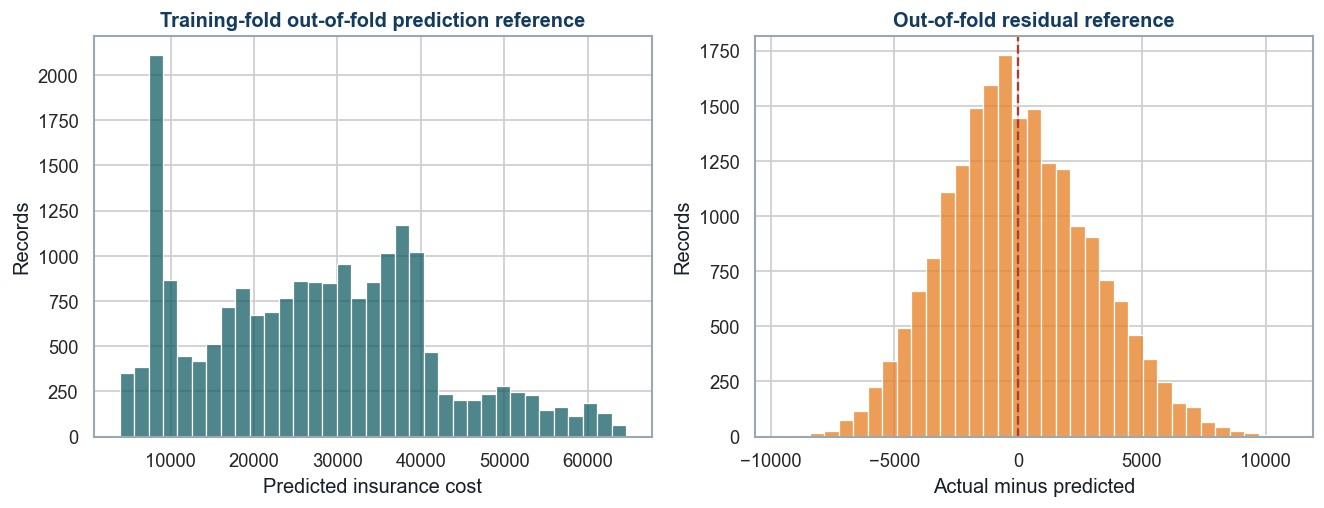

In [22]:
from datetime import datetime, timezone
import hashlib
from sklearn.model_selection import cross_val_predict

oof_prediction = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=feature_cv_splits,
    method="predict",
    n_jobs=1,
)
oof_prediction = np.asarray(oof_prediction, dtype=float)
oof_residual = np.asarray(y_train, dtype=float) - oof_prediction
oof_absolute_residual = np.abs(oof_residual)


def finite_sample_residual_quantile(absolute_residuals, coverage):
    residuals = np.asarray(absolute_residuals, dtype=float)
    probability = min(
        np.ceil((len(residuals) + 1) * coverage) / len(residuals),
        1.0,
    )
    return float(np.quantile(residuals, probability, method="higher"))


interval_rows = []
interval_widths = {}
for coverage in [0.80, 0.90]:
    residual_quantile = finite_sample_residual_quantile(
        oof_absolute_residual,
        coverage,
    )
    interval_widths[str(int(coverage * 100))] = residual_quantile
    interval_rows.append(
        {
            "nominal_coverage": coverage,
            "absolute_residual_quantile": residual_quantile,
            "empirical_oof_coverage": float(
                np.mean(oof_absolute_residual <= residual_quantile)
            ),
            "oof_rows": int(len(oof_prediction)),
            "folds": int(len(feature_cv_splits)),
        }
    )

prediction_interval_summary = pd.DataFrame(interval_rows)
prediction_interval_summary.to_csv(
    TABLE_DIR / "prediction_interval_summary.csv",
    index=False,
)
prediction_interval_metadata = {
    "method": "Out-of-fold empirical absolute-residual interval",
    "source": "Training partition only",
    "folds": int(len(feature_cv_splits)),
    "oof_rows": int(len(oof_prediction)),
    "coverage_levels": interval_widths,
    "interpretation": (
        "The displayed range is an empirical uncertainty interval based on "
        "training-fold out-of-fold residuals. It is not a guarantee for an "
        "individual applicant."
    ),
}
(MODEL_DIR / "prediction_interval_metadata.json").write_text(
    json.dumps(prediction_interval_metadata, indent=2),
    encoding="utf-8",
)

oof_quote_band = nearest_band(oof_prediction, target_levels)
portfolio_reference = pd.DataFrame(
    {
        "oof_prediction": oof_prediction,
        "nearest_quote_band": oof_quote_band,
    }
).sort_values("oof_prediction", ignore_index=True)
portfolio_reference.to_csv(
    MODEL_DIR / "portfolio_prediction_reference.csv",
    index=False,
)
portfolio_reference.to_csv(
    TABLE_DIR / "portfolio_prediction_reference.csv",
    index=False,
)

oof_tier_thresholds = np.quantile(oof_prediction, [0.33, 0.66])
oof_tier = np.select(
    [
        oof_prediction < oof_tier_thresholds[0],
        oof_prediction < oof_tier_thresholds[1],
    ],
    ["Lower", "Medium"],
    default="Higher",
)
reference_distribution_rows = []
for band_value, count in pd.Series(oof_quote_band).value_counts().sort_index().items():
    reference_distribution_rows.append(
        {
            "distribution": "quote_band",
            "label": str(int(band_value)),
            "count": int(count),
            "proportion": float(count / len(oof_prediction)),
        }
    )
for tier_value, count in pd.Series(oof_tier).value_counts().items():
    reference_distribution_rows.append(
        {
            "distribution": "review_tier",
            "label": str(tier_value),
            "count": int(count),
            "proportion": float(count / len(oof_prediction)),
        }
    )
deployment_reference_distribution = pd.DataFrame(
    reference_distribution_rows
)
deployment_reference_distribution.to_csv(
    MODEL_DIR / "deployment_reference_distribution.csv",
    index=False,
)
deployment_reference_distribution.to_csv(
    TABLE_DIR / "deployment_reference_distribution.csv",
    index=False,
)

deployment_numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()
deployment_categorical_features = [
    column
    for column in X_train.columns
    if column not in deployment_numeric_features
]
training_reference_profile = {
    "source": "Training partition aggregate distributions",
    "rows": int(len(X_train)),
    "numeric": {},
    "categorical": {},
}
for column in deployment_numeric_features:
    values = pd.to_numeric(X_train[column], errors="coerce")
    non_missing = values.dropna().to_numpy(dtype=float)
    cuts = sorted(
        {
            float(value)
            for value in np.quantile(non_missing, np.linspace(0.1, 0.9, 9))
        }
    )
    histogram, _ = np.histogram(
        non_missing,
        bins=[-np.inf, *cuts, np.inf],
    )
    training_reference_profile["numeric"][column] = {
        "cuts": cuts,
        "expected_proportions": (
            histogram / max(histogram.sum(), 1)
        ).astype(float).tolist(),
        "missing_proportion": float(values.isna().mean()),
        "min": float(np.min(non_missing)),
        "max": float(np.max(non_missing)),
        "median": float(np.median(non_missing)),
    }
for column in deployment_categorical_features:
    values = X_train[column].astype("string").fillna("__MISSING__")
    frequencies = values.value_counts(normalize=True, dropna=False)
    training_reference_profile["categorical"][column] = {
        "expected_proportions": {
            str(key): float(value)
            for key, value in frequencies.items()
        }
    }
(MODEL_DIR / "training_reference_profile.json").write_text(
    json.dumps(training_reference_profile, indent=2),
    encoding="utf-8",
)

explanation_baseline = {}
for column in deployment_numeric_features:
    explanation_baseline[column] = float(
        pd.to_numeric(X_train[column], errors="coerce").median()
    )
for column in deployment_categorical_features:
    explanation_baseline[column] = str(
        X_train[column].dropna().astype(str).mode().iloc[0]
    )

typical_profile = dict(explanation_baseline)
upper_cost_review_profile = dict(explanation_baseline)
for column in ["weight", "fat_percentage", "avg_glucose_level"]:
    if column in upper_cost_review_profile:
        upper_cost_review_profile[column] = float(
            pd.to_numeric(X_train[column], errors="coerce").quantile(0.75)
        )
if "Year_last_admitted" in upper_cost_review_profile:
    upper_cost_review_profile["Year_last_admitted"] = float(
        pd.to_numeric(
            X_train["Year_last_admitted"],
            errors="coerce",
        ).dropna().quantile(0.25)
    )
if "adventure_sports" in upper_cost_review_profile:
    upper_cost_review_profile["adventure_sports"] = 1.0

missing_history_profile = dict(explanation_baseline)
if "bmi" in missing_history_profile:
    missing_history_profile["bmi"] = None
if "Year_last_admitted" in missing_history_profile:
    missing_history_profile["Year_last_admitted"] = None

example_profiles = {
    "Typical portfolio profile": typical_profile,
    "Upper-cost review example": upper_cost_review_profile,
    "Missing-history example": missing_history_profile,
}
local_explanation_reference = {
    "method": "Exact weighted component Tree SHAP when available",
    "fallback_method": "One-feature-to-reference perturbation on final blend",
    "baseline_profile": explanation_baseline,
    "note": (
        "Attributions describe fitted-model associations. They do not prove "
        "that changing an input will cause a premium change."
    ),
}
(MODEL_DIR / "local_explanation_reference.json").write_text(
    json.dumps(local_explanation_reference, indent=2),
    encoding="utf-8",
)

minimum_segment_records = 100
app_fairness_summary = segment_error.copy()
app_fairness_summary["reliable_sample"] = (
    app_fairness_summary["records"] >= minimum_segment_records
)
neutral_limit = app_fairness_summary["MAE"] * 0.05
app_fairness_summary["bias_direction"] = np.select(
    [
        app_fairness_summary["mean_residual"] > neutral_limit,
        app_fairness_summary["mean_residual"] < -neutral_limit,
    ],
    ["Underprediction", "Overprediction"],
    default="Near neutral",
)
app_fairness_summary["interpretation_status"] = np.where(
    app_fairness_summary["reliable_sample"],
    "Reviewable",
    "Small sample - interpret cautiously",
)
app_fairness_summary.to_csv(
    MODEL_DIR / "app_fairness_summary.csv",
    index=False,
)
app_fairness_summary.to_csv(
    TABLE_DIR / "app_fairness_summary.csv",
    index=False,
)

model_bytes = (MODEL_DIR / "final_model.pkl").read_bytes()
model_hash = hashlib.sha256(model_bytes).hexdigest()
app_version_metadata = {
    "model_version": f"m2-{model_hash[:12]}",
    "model_sha256": model_hash,
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "final_model": final_model_name,
    "best_model_label": "BEST, recommended",
    "candidate_model_manifest": (
        "outputs/models/candidate_model_manifest.csv"
    ),
    "selectable_regression_models": candidate_model_manifest[
        "model"
    ].tolist(),
    "selected_feature_strategy": selected_feature_strategy,
    "app_views": [
        "Quote Estimator",
        "What-if Comparison",
        "Batch Scoring",
        "Model Insights",
        "Monitoring and Fairness",
        "Methodology and Limitations",
    ],
    "explanation_method": (
        "Weighted component Tree SHAP for the fitted blend with a "
        "model-agnostic perturbation fallback"
    ),
    "interval_method": prediction_interval_metadata["method"],
}
(MODEL_DIR / "app_version_metadata.json").write_text(
    json.dumps(app_version_metadata, indent=2),
    encoding="utf-8",
)

figure, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
sns.histplot(oof_prediction, bins=35, color=COLORS[0], ax=axes[0])
axes[0].set_title("Training-fold out-of-fold prediction reference")
axes[0].set_xlabel("Predicted insurance cost")
axes[0].set_ylabel("Records")
sns.histplot(oof_residual, bins=35, color=COLORS[1], ax=axes[1])
axes[1].axvline(0, color=COLORS[3], linestyle="--", linewidth=1.4)
axes[1].set_title("Out-of-fold residual reference")
axes[1].set_xlabel("Actual minus predicted")
axes[1].set_ylabel("Records")
figure.tight_layout()
figure.savefig(FIG_DIR / "app_oof_reference.png")
plt.close(figure)

display(prediction_interval_summary.round(3))
display(app_fairness_summary.round(3))
display(
    Image(
        filename=str(FIG_DIR / "app_oof_reference.png"),
        alt=(
            "Training-fold out-of-fold prediction and residual distributions "
            "used for application reference artifacts."
        ),
    )
)

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The application references are derived from out-of-fold training predictions and aggregate training distributions. The final holdout set is not used to construct prediction intervals, percentiles, drift baselines, or review tiers.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The application can communicate uncertainty and portfolio context while keeping final holdout performance separate and avoiding storage of raw training records.</span>
  </div>
</div>

### 20.2 Input schema, version metadata, and portable model test

In [23]:
raw_numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()
raw_categorical_features = [
    column
    for column in X_train.columns
    if column not in raw_numeric_features
]

numeric_ranges = {}
for column in raw_numeric_features:
    non_missing = pd.to_numeric(X_train[column], errors="coerce").dropna()
    numeric_ranges[column] = {
        "min": float(non_missing.min()),
        "max": float(non_missing.max()),
        "median": float(non_missing.median()),
        "allow_missing": bool(X_train[column].isna().any()),
    }

categorical_options = {
    column: sorted(model_df[column].dropna().astype(str).unique().tolist())
    for column in raw_categorical_features
}
app_schema = {
    "raw_model_columns": X_train.columns.tolist(),
    "model_input_columns": X_train.columns.tolist(),
    "selected_feature_strategy": selected_feature_strategy,
    "numeric_features": raw_numeric_features,
    "categorical_features": raw_categorical_features,
    "numeric_ranges": numeric_ranges,
    "categorical_options": categorical_options,
    "example_profiles": example_profiles,
    "case_reference_allowed": True,
    "target_grid": {
        "target_unique_count": int(len(target_levels)),
        "target_grid_step": target_step,
        "target_min": int(target_levels.min()),
        "target_max": int(target_levels.max()),
        "valid_target_levels": target_levels.tolist(),
    },
    "dropped_from_modeling": ["applicant_id"],
    "schema_note": (
        "Ranges come from training data. applicant_id is excluded. "
        "The raw 22-feature strategy was retained after the Milestone 1 "
        "engineered-feature challenger did not meet the practical selection rule."
    ),
}
(MODEL_DIR / "app_schema.json").write_text(
    json.dumps(app_schema, indent=2),
    encoding="utf-8",
)

prediction_quantiles = oof_tier_thresholds
metadata = {
    "final_model": final_model_name,
    "best_model_label": "BEST, recommended",
    "candidate_model_manifest": (
        "outputs/models/candidate_model_manifest.csv"
    ),
    "model_version": app_version_metadata["model_version"],
    "generated_utc": app_version_metadata["generated_utc"],
    "selection_reason": selection_reason,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "random_state": RANDOM_STATE,
    "split_strategy": "Target-price-band stratified 80/20 split",
    "cross_validation": "3-fold target-stratified CV plus 3-fold x 2 repeats",
    "target": TARGET,
    "target_grid": app_schema["target_grid"],
    "raw_model_columns": X_train.columns.tolist(),
    "model_input_columns": X_train.columns.tolist(),
    "selected_feature_strategy": selected_feature_strategy,
    "milestone1_continuity": {
        "handoff_recomputed_from_csv": True,
        "feature_set_comparison": (
            "outputs/tables/milestone1_feature_set_comparison.csv"
        ),
        "feature_selection_reason": feature_selection_reason,
    },
    "dropped_from_modeling": ["applicant_id"],
    "best_hyperparameters": tuning_search.best_params_,
    "external_model_packages": {
        "xgboost": True,
        "lightgbm": True,
        "catboost": True,
        "shap": bool(shap_status.get("available")),
    },
    "gpu_acceleration_enabled": GPU_AVAILABLE,
    "deployment_variant": {
        "analytics_prediction": "raw_continuous",
        "quote_band": "rounded_to_nearest_price_band",
        "calibrated_prediction": "secondary_diagnostic",
        "reason": (
            "Raw prediction is retained for continuous analytics. "
            "The nearest valid quote band is derived from the raw prediction. "
            "Calibration is displayed only as a secondary diagnostic unless it "
            "improves the selected business metric."
        ),
    },
    "test_metrics": {
        key.replace("test_", ""): float(selected_metrics[key])
        for key in ["test_MAE", "test_RMSE", "test_R2", "test_MAPE", "test_SMAPE"]
    },
    "risk_thresholds": {
        "low_medium": float(prediction_quantiles[0]),
        "medium_high": float(prediction_quantiles[1]),
    },
    "prediction_interval": prediction_interval_metadata,
    "portfolio_reference": (
        "outputs/models/portfolio_prediction_reference.csv"
    ),
    "training_reference_profile": (
        "outputs/models/training_reference_profile.json"
    ),
    "local_explanation": local_explanation_reference,
    "fairness_monitoring": {
        "table": "outputs/models/app_fairness_summary.csv",
        "minimum_segment_records": minimum_segment_records,
        "residual_definition": "actual cost minus predicted cost",
    },
    "app_views": app_version_metadata["app_views"],
    "shap_status": shap_status,
}
(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

reloaded_model = joblib.load(MODEL_DIR / "final_model.pkl")
smoke_sample = X_test.head(5)
smoke_predictions = reloaded_model.predict(smoke_sample)
smoke_test = {
    "model_loads": True,
    "prediction_count": int(len(smoke_predictions)),
    "all_finite": bool(np.isfinite(smoke_predictions).all()),
    "first_predictions": [float(value) for value in smoke_predictions],
    "custom_project_transformer_required": False,
}
display(pd.DataFrame([smoke_test]))

,model_loads,prediction_count,all_finite,first_predictions,custom_project_transformer_required
0,True,5,True,"[4233.128503923905, 18029.990155611456, 38211.91210299185, 10894.40898335458, 12852.920516392729]",False


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The saved model reloads and predicts using only serialized standard pipeline components. The schema stores training-derived ranges, valid categories, quote bands, and the explicit exclusion of `applicant_id`.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>Deployment can validate user inputs against the training schema and display both a continuous estimate and a nearest valid quote band.</span>
  </div>
</div>

## 21. Generate the Streamlit Deployment App

In [24]:
app_source = 'from __future__ import annotations\n\nimport hashlib\nimport json\nimport warnings\nfrom io import BytesIO\nfrom pathlib import Path\n\nimport joblib\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\nfrom matplotlib.backends.backend_pdf import PdfPages\n\nwarnings.filterwarnings(\n    "ignore",\n    message="X does not have valid feature names",\n)\n\nROOT = Path(__file__).resolve().parent\nMODEL_DIR = ROOT / "outputs" / "models"\nTABLE_DIR = ROOT / "outputs" / "tables"\nFIGURE_DIR = ROOT / "outputs" / "figures"\nMAX_BATCH_ROWS = 5000\nMAX_BATCH_BYTES = 5 * 1024 * 1024\nFAIRNESS_MIN_SAMPLES = 100\n\nVIEW_NAMES = [\n    "Quote Estimator",\n    "What-if Comparison",\n    "Batch Scoring",\n    "Model Insights",\n    "Monitoring and Fairness",\n    "Methodology and Limitations",\n]\n\nFIELD_LABELS = {\n    "years_of_insurance_with_us": "Years insured with us",\n    "regular_checkup_last_year": "Regular checkups last year",\n    "adventure_sports": "Adventure sports",\n    "Occupation": "Occupation",\n    "visited_doctor_last_1_year": "Doctor visits last year",\n    "cholesterol_level": "Cholesterol range",\n    "daily_avg_steps": "Average daily steps",\n    "age": "Age",\n    "heart_disease_history": "Heart disease history",\n    "other_major_disease_history": "Other major disease history",\n    "Gender": "Gender",\n    "avg_glucose_level": "Average glucose level",\n    "bmi": "BMI",\n    "smoking_status": "Smoking status",\n    "Year_last_admitted": "Year last admitted",\n    "Location": "Location",\n    "weight": "Weight",\n    "covered_by_any_other_company": "Covered by another company",\n    "Alcohol": "Alcohol use",\n    "exercise": "Exercise",\n    "weight_change_in_last_one_year": "Weight change last year",\n    "fat_percentage": "Body fat percentage",\n}\n\nFIELD_UNITS = {\n    "years_of_insurance_with_us": "years",\n    "regular_checkup_last_year": "visits",\n    "visited_doctor_last_1_year": "visits",\n    "daily_avg_steps": "steps/day",\n    "age": "years",\n    "avg_glucose_level": "mg/dL",\n    "bmi": "kg/m2",\n    "Year_last_admitted": "calendar year",\n    "weight": "kg",\n    "weight_change_in_last_one_year": "kg",\n    "fat_percentage": "%",\n}\n\nFIELD_HELP = {\n    "years_of_insurance_with_us": "Completed years covered by this insurer.",\n    "regular_checkup_last_year": "Number of regular health checkups in the previous year.",\n    "adventure_sports": "Whether adventure-sports participation is recorded.",\n    "Occupation": "Applicant occupation category in the supplied data.",\n    "visited_doctor_last_1_year": "Number of doctor visits in the previous year.",\n    "cholesterol_level": "Recorded cholesterol range category.",\n    "daily_avg_steps": "Typical average steps per day.",\n    "age": "Applicant age in completed years.",\n    "heart_disease_history": "Recorded history indicator, not an eligibility decision.",\n    "other_major_disease_history": "Recorded history indicator, not an eligibility decision.",\n    "Gender": "Applicant gender category represented in the training data.",\n    "avg_glucose_level": "Recorded average glucose measurement.",\n    "bmi": "Recorded body mass index. Missing values are supported.",\n    "smoking_status": "Recorded smoking-history category.",\n    "Year_last_admitted": "Most recent hospital-admission year. Missing values are supported.",\n    "Location": "Applicant location category represented in the training data.",\n    "weight": "Recorded applicant weight.",\n    "covered_by_any_other_company": "Whether another insurer also covers the applicant.",\n    "Alcohol": "Recorded alcohol-use category.",\n    "exercise": "Recorded exercise category.",\n    "weight_change_in_last_one_year": "Recorded weight change during the previous year.",\n    "fat_percentage": "Recorded body-fat percentage.",\n}\n\nFIELD_GROUPS = {\n    "Applicant": ["age", "Gender", "Occupation", "Location"],\n    "Insurance": [\n        "years_of_insurance_with_us",\n        "covered_by_any_other_company",\n        "regular_checkup_last_year",\n        "visited_doctor_last_1_year",\n        "Year_last_admitted",\n    ],\n    "Health": [\n        "weight",\n        "bmi",\n        "fat_percentage",\n        "avg_glucose_level",\n        "cholesterol_level",\n        "weight_change_in_last_one_year",\n    ],\n    "Lifestyle": [\n        "daily_avg_steps",\n        "exercise",\n        "smoking_status",\n        "Alcohol",\n        "adventure_sports",\n        "heart_disease_history",\n        "other_major_disease_history",\n    ],\n}\n\nBINARY_NUMERIC_FEATURES = {\n    "adventure_sports",\n    "heart_disease_history",\n    "other_major_disease_history",\n}\n\n\n@st.cache_resource\ndef load_core_artifacts():\n    model = joblib.load(MODEL_DIR / "final_model.pkl")\n    schema = json.loads((MODEL_DIR / "app_schema.json").read_text(encoding="utf-8"))\n    metadata = json.loads(\n        (MODEL_DIR / "model_metadata.json").read_text(encoding="utf-8")\n    )\n    interval_metadata = json.loads(\n        (MODEL_DIR / "prediction_interval_metadata.json").read_text(encoding="utf-8")\n    )\n    examples = schema.get("example_profiles", {})\n    fallback_profile = dict(next(iter(examples.values()), {}))\n    explanation_reference = {\n        "baseline_profile": fallback_profile,\n        "note": (\n            "The local explanation reference artifact is unavailable. "\n            "The application is using the first schema example as the "\n            "model-agnostic perturbation reference."\n        ),\n    }\n    explanation_path = MODEL_DIR / "local_explanation_reference.json"\n    if explanation_path.exists():\n        try:\n            explanation_reference = json.loads(\n                explanation_path.read_text(encoding="utf-8")\n            )\n        except (OSError, json.JSONDecodeError):\n            pass\n    version_metadata = {\n        "model_version": metadata.get("model_version", "Unavailable"),\n        "generated_utc": "Unavailable",\n        "final_model": metadata.get("final_model", "Unavailable"),\n        "explanation_method": (\n            "Weighted component Tree SHAP when available, with a "\n            "model-agnostic perturbation fallback"\n        ),\n    }\n    version_path = MODEL_DIR / "app_version_metadata.json"\n    if version_path.exists():\n        try:\n            version_metadata = json.loads(version_path.read_text(encoding="utf-8"))\n        except (OSError, json.JSONDecodeError):\n            pass\n    return (\n        model,\n        schema,\n        metadata,\n        interval_metadata,\n        explanation_reference,\n        version_metadata,\n    )\n\n\n@st.cache_data\ndef load_csv_artifact(path_text: str) -> pd.DataFrame:\n    path = ROOT / path_text\n    if not path.exists():\n        return pd.DataFrame()\n    try:\n        return pd.read_csv(path)\n    except (OSError, UnicodeDecodeError, pd.errors.ParserError):\n        return pd.DataFrame()\n\n\n@st.cache_data\ndef load_json_artifact(path_text: str) -> dict:\n    path = ROOT / path_text\n    if not path.exists():\n        return {}\n    try:\n        return json.loads(path.read_text(encoding="utf-8"))\n    except (OSError, UnicodeDecodeError, json.JSONDecodeError):\n        return {}\n\n\n@st.cache_resource\ndef load_prediction_model(artifact_path: str):\n    path = (ROOT / artifact_path).resolve()\n    if ROOT.resolve() not in path.parents:\n        raise ValueError("Model artifact path is outside the project directory.")\n    return joblib.load(path)\n\n\n@st.cache_resource\ndef load_blend_shap_resources():\n    import shap\n\n    resources = []\n    weights = (\n        np.asarray(recommended_model.weights, dtype=float)\n        if getattr(recommended_model, "weights", None) is not None\n        else np.ones(len(recommended_model.estimators_), dtype=float)\n    )\n    weights = weights / weights.sum()\n    for weight, component in zip(weights, recommended_model.estimators_):\n        preprocessor = component.named_steps["preprocess"]\n        tree_model = component.named_steps["model"]\n        resources.append(\n            {\n                "weight": float(weight),\n                "preprocessor": preprocessor,\n                "explainer": shap.TreeExplainer(tree_model),\n            }\n        )\n    return resources\n\n\ndef display_label(feature: str) -> str:\n    return FIELD_LABELS.get(feature, feature.replace("_", " ").title())\n\n\ndef display_value(feature: str, value) -> str:\n    if pd.isna(value):\n        return "Unavailable"\n    if feature in BINARY_NUMERIC_FEATURES:\n        return "Yes" if float(value) == 1 else "No"\n    unit = FIELD_UNITS.get(feature)\n    if isinstance(value, (int, float, np.number)):\n        text = f"{float(value):,.1f}".rstrip("0").rstrip(".")\n        return f"{text} {unit}" if unit else text\n    return str(value)\n\n\ndef profile_value(profile: dict, feature: str, schema: dict):\n    value = profile.get(feature)\n    if value is None:\n        return np.nan\n    if feature in schema["numeric_features"]:\n        return float(value)\n    return str(value)\n\n\ndef initialize_profile(prefix: str, profile: dict, schema: dict) -> None:\n    for feature in schema["raw_model_columns"]:\n        key = f"{prefix}_{feature}"\n        missing_key = f"{prefix}_missing_{feature}"\n        value = profile_value(profile, feature, schema)\n        if key not in st.session_state:\n            if feature in schema["numeric_features"]:\n                fallback = float(schema["numeric_ranges"][feature]["median"])\n                st.session_state[key] = fallback if pd.isna(value) else float(value)\n            else:\n                options = schema["categorical_options"][feature]\n                st.session_state[key] = value if value in options else options[0]\n        if schema["numeric_ranges"].get(feature, {}).get("allow_missing"):\n            st.session_state.setdefault(missing_key, bool(pd.isna(value)))\n\n\ndef apply_profile(prefix: str, profile: dict, schema: dict) -> None:\n    for feature in schema["raw_model_columns"]:\n        key = f"{prefix}_{feature}"\n        missing_key = f"{prefix}_missing_{feature}"\n        value = profile_value(profile, feature, schema)\n        if feature in schema["numeric_features"]:\n            st.session_state[key] = (\n                float(schema["numeric_ranges"][feature]["median"])\n                if pd.isna(value)\n                else float(value)\n            )\n            if schema["numeric_ranges"][feature].get("allow_missing"):\n                st.session_state[missing_key] = bool(pd.isna(value))\n        else:\n            options = schema["categorical_options"][feature]\n            st.session_state[key] = value if value in options else options[0]\n\n\ndef input_widget(feature: str, schema: dict, prefix: str):\n    label = display_label(feature)\n    help_text = FIELD_HELP.get(feature)\n    key = f"{prefix}_{feature}"\n    if feature in schema["categorical_features"]:\n        return st.selectbox(\n            label,\n            schema["categorical_options"][feature],\n            key=key,\n            help=help_text,\n        )\n\n    config = schema["numeric_ranges"][feature]\n    missing_key = f"{prefix}_missing_{feature}"\n    unavailable = False\n    if config.get("allow_missing"):\n        unavailable = st.checkbox(\n            f"{label} unavailable",\n            key=missing_key,\n        )\n    if feature in BINARY_NUMERIC_FEATURES:\n        value = st.selectbox(\n            label,\n            [0.0, 1.0],\n            key=key,\n            format_func=lambda item: "Yes" if item == 1 else "No",\n            disabled=unavailable,\n            help=help_text,\n        )\n        return np.nan if unavailable else float(value)\n\n    unit = FIELD_UNITS.get(feature)\n    range_text = (\n        f"Training range {config[\'min\']:,.1f} to {config[\'max\']:,.1f}"\n        + (f" {unit}" if unit else "")\n    )\n    full_help = f"{help_text} {range_text}" if help_text else range_text\n    step = 0.1 if feature in {\n        "bmi",\n        "fat_percentage",\n        "avg_glucose_level",\n        "weight",\n        "weight_change_in_last_one_year",\n    } else 1.0\n    value = st.number_input(\n        f"{label}" + (f" ({unit})" if unit else ""),\n        step=step,\n        key=key,\n        disabled=unavailable,\n        help=full_help,\n    )\n    return np.nan if unavailable else float(value)\n\n\ndef render_profile_form(prefix: str, schema: dict, submit_label: str):\n    values = {}\n    with st.form(f"{prefix}_form"):\n        tabs = st.tabs(list(FIELD_GROUPS))\n        for tab, (group_name, features) in zip(tabs, FIELD_GROUPS.items()):\n            with tab:\n                st.subheader(group_name)\n                columns = st.columns(2)\n                for index, feature in enumerate(features):\n                    with columns[index % 2]:\n                        values[feature] = input_widget(feature, schema, prefix)\n        submitted = st.form_submit_button(\n            submit_label,\n            type="primary",\n            icon=":material/calculate:",\n        )\n    row = pd.DataFrame([values], columns=schema["raw_model_columns"])\n    return row, submitted\n\n\ndef validate_rows(frame: pd.DataFrame, schema: dict):\n    cleaned = pd.DataFrame(index=frame.index)\n    error_messages = pd.Series([[] for _ in range(len(frame))], index=frame.index)\n    warning_messages = pd.Series([[] for _ in range(len(frame))], index=frame.index)\n\n    for feature in schema["raw_model_columns"]:\n        if feature not in frame.columns:\n            for index in frame.index:\n                error_messages.at[index].append(f"Missing column: {feature}")\n            continue\n\n        if feature in schema["numeric_features"]:\n            original = frame[feature]\n            numeric = pd.to_numeric(original, errors="coerce")\n            cleaned[feature] = numeric\n            invalid_type = original.notna() & numeric.isna()\n            for index in frame.index[invalid_type]:\n                error_messages.at[index].append(\n                    f"{display_label(feature)} is not numeric"\n                )\n            config = schema["numeric_ranges"][feature]\n            if not config.get("allow_missing"):\n                for index in frame.index[numeric.isna()]:\n                    error_messages.at[index].append(\n                        f"{display_label(feature)} is required"\n                    )\n            outside = numeric.notna() & (\n                (numeric < float(config["min"])) | (numeric > float(config["max"]))\n            )\n            for index in frame.index[outside]:\n                warning_messages.at[index].append(\n                    f"{display_label(feature)} is outside the training range"\n                )\n        else:\n            values = frame[feature].astype("string")\n            cleaned[feature] = values.astype(object)\n            allowed = set(map(str, schema["categorical_options"][feature]))\n            for index in frame.index:\n                value = values.at[index]\n                if pd.isna(value):\n                    error_messages.at[index].append(\n                        f"{display_label(feature)} is required"\n                    )\n                elif str(value) not in allowed:\n                    error_messages.at[index].append(\n                        f"Unknown {display_label(feature)} category: {value}"\n                    )\n\n    errors = error_messages.map(lambda items: "; ".join(dict.fromkeys(items)))\n    warnings_text = warning_messages.map(\n        lambda items: "; ".join(dict.fromkeys(items))\n    )\n    return cleaned.reindex(columns=schema["raw_model_columns"]), errors, warnings_text\n\n\ndef nearest_quote_bands(values, levels):\n    value_array = np.asarray(values, dtype=float)\n    level_array = np.asarray(levels, dtype=float)\n    distance = np.abs(value_array[:, None] - level_array[None, :])\n    return level_array[np.argmin(distance, axis=1)]\n\n\ndef score_rows(\n    frame: pd.DataFrame,\n    prediction_model,\n    model_name: str,\n    coverage: str = "90",\n) -> pd.DataFrame:\n    predictions = np.asarray(prediction_model.predict(frame), dtype=float)\n    levels = np.asarray(schema["target_grid"]["valid_target_levels"], dtype=float)\n    bands = nearest_quote_bands(predictions, levels)\n    is_recommended = model_name == metadata["final_model"]\n    if (\n        is_recommended\n        and not portfolio_reference.empty\n        and "oof_prediction" in portfolio_reference\n    ):\n        reference_values = portfolio_reference["oof_prediction"].to_numpy(dtype=float)\n        percentiles = (\n            np.searchsorted(reference_values, predictions, side="right")\n            / len(reference_values)\n            * 100\n        )\n    else:\n        percentiles = np.full(len(predictions), np.nan)\n    thresholds = metadata["risk_thresholds"]\n    tiers = np.select(\n        [\n            predictions < thresholds["low_medium"],\n            predictions < thresholds["medium_high"],\n        ],\n        ["Lower", "Medium"],\n        default="Higher",\n    )\n    if is_recommended and coverage in interval_metadata.get("coverage_levels", {}):\n        half_width = float(interval_metadata["coverage_levels"][coverage])\n        lower = np.maximum(\n            predictions - half_width,\n            schema["target_grid"]["target_min"],\n        )\n        upper = np.minimum(\n            predictions + half_width,\n            schema["target_grid"]["target_max"],\n        )\n        interval_label = f"{coverage}%"\n    else:\n        lower = np.full(len(predictions), np.nan)\n        upper = np.full(len(predictions), np.nan)\n        interval_label = "Final model only"\n    return pd.DataFrame(\n        {\n            "prediction_model": model_name,\n            "recommended_model": is_recommended,\n            "raw_estimate": predictions,\n            "nearest_quote_band": bands,\n            "band_distance": np.abs(predictions - bands),\n            "review_tier": tiers,\n            "portfolio_percentile": percentiles,\n            "interval_coverage": interval_label,\n            "interval_lower": lower,\n            "interval_upper": upper,\n        },\n        index=frame.index,\n    )\n\n\ndef transformed_to_raw_feature(name: str) -> str:\n    normalized = name.split("__", 1)[-1]\n    if normalized in schema["raw_model_columns"]:\n        return normalized\n    if normalized.startswith("missingindicator_"):\n        source_feature = normalized.removeprefix("missingindicator_")\n        if source_feature in schema["raw_model_columns"]:\n            return source_feature\n    for feature in sorted(\n        schema["categorical_features"],\n        key=len,\n        reverse=True,\n    ):\n        if normalized.startswith(f"{feature}_"):\n            return feature\n    return normalized\n\n\ndef perturbation_explanation(\n    row: pd.DataFrame,\n    prediction: float,\n    prediction_model,\n    model_name: str,\n):\n    baseline = explanation_reference["baseline_profile"]\n    rows = []\n    for feature in schema["raw_model_columns"]:\n        changed = row.copy()\n        reference_value = baseline.get(feature)\n        changed.at[changed.index[0], feature] = (\n            np.nan if reference_value is None else reference_value\n        )\n        reference_prediction = float(prediction_model.predict(changed)[0])\n        rows.append(\n            {\n                "feature": feature,\n                "input_value": row.iloc[0][feature],\n                "contribution": prediction - reference_prediction,\n            }\n        )\n    result = pd.DataFrame(rows).sort_values(\n        "contribution",\n        key=lambda values: values.abs(),\n        ascending=False,\n    )\n    return result, f"{model_name} one-feature perturbation"\n\n\ndef local_model_explanation(\n    row: pd.DataFrame,\n    prediction: float,\n    prediction_model,\n    model_name: str,\n):\n    if model_name != metadata["final_model"]:\n        return perturbation_explanation(\n            row,\n            prediction,\n            prediction_model,\n            model_name,\n        )\n    try:\n        combined = {feature: 0.0 for feature in schema["raw_model_columns"]}\n        combined_base = 0.0\n        for resource in load_blend_shap_resources():\n            transformed = resource["preprocessor"].transform(row)\n            names = resource["preprocessor"].get_feature_names_out()\n            values = np.asarray(\n                resource["explainer"].shap_values(transformed),\n                dtype=float,\n            )[0]\n            expected = float(\n                np.asarray(resource["explainer"].expected_value).reshape(-1)[0]\n            )\n            combined_base += resource["weight"] * expected\n            for name, value in zip(names, values):\n                raw_feature = transformed_to_raw_feature(str(name))\n                if raw_feature in combined:\n                    combined[raw_feature] += resource["weight"] * float(value)\n        contribution_sum = combined_base + sum(combined.values())\n        if not np.isclose(contribution_sum, prediction, atol=1e-3):\n            raise ValueError("Weighted SHAP additivity check failed.")\n        rows = [\n            {\n                "feature": feature,\n                "input_value": row.iloc[0][feature],\n                "contribution": contribution,\n            }\n            for feature, contribution in combined.items()\n        ]\n        result = pd.DataFrame(rows).sort_values(\n            "contribution",\n            key=lambda values: values.abs(),\n            ascending=False,\n        )\n        return result, "Exact weighted component Tree SHAP"\n    except Exception:\n        return perturbation_explanation(\n            row,\n            prediction,\n            prediction_model,\n            model_name,\n        )\n\n\ndef contribution_chart(contributions: pd.DataFrame, title: str):\n    view = contributions.head(10).sort_values("contribution")\n    colors = np.where(view["contribution"] >= 0, "#B5543C", "#18766F")\n    figure, axis = plt.subplots(figsize=(8.2, 4.8))\n    axis.barh(\n        [display_label(feature) for feature in view["feature"]],\n        view["contribution"],\n        color=colors,\n    )\n    axis.axvline(0, color="#82909A", linewidth=1)\n    axis.set_title(title)\n    axis.set_xlabel("Contribution to predicted insurance cost")\n    axis.set_ylabel("")\n    axis.grid(axis="x", alpha=0.2)\n    figure.tight_layout()\n    return figure\n\n\ndef model_manifest_row(model_name: str) -> pd.Series:\n    rows = candidate_manifest.loc[candidate_manifest["model"] == model_name]\n    if rows.empty:\n        return pd.Series(\n            {\n                "model": model_name,\n                "reader-friendly name": model_name,\n                "selected_final_model": model_name == metadata["final_model"],\n            }\n        )\n    return rows.iloc[0]\n\n\ndef model_option_label(model_name: str) -> str:\n    row = model_manifest_row(model_name)\n    friendly_name = str(row.get("reader-friendly name", model_name))\n    if bool(row.get("selected_final_model", False)):\n        return f"{friendly_name} ({model_name}) - BEST, recommended"\n    return f"{friendly_name} ({model_name})"\n\n\ndef render_active_model_notice() -> None:\n    best_row = model_manifest_row(metadata["final_model"])\n    best_rmse = best_row.get("repeated_cv_RMSE_mean", np.nan)\n    best_metric_text = (\n        f" Repeated CV RMSE: {float(best_rmse):,.1f}."\n        if pd.notna(best_rmse)\n        else ""\n    )\n    if active_model_name == metadata["final_model"]:\n        st.success(\n            f"Best model selected: {model_option_label(active_model_name)}."\n            f"{best_metric_text} This is the recommended deployment model."\n        )\n    else:\n        st.warning(\n            f"Challenger selected: {model_option_label(active_model_name)}. "\n            f"The best model remains {model_option_label(metadata[\'final_model\'])}."\n            f"{best_metric_text} Final-model OOF intervals, portfolio percentiles, "\n            "fairness results, and exact blend SHAP are not assigned to this challenger."\n        )\n\n\ndef optional_percentile(value) -> str:\n    return (\n        f"{float(value):.1f} percentile"\n        if pd.notna(value)\n        else "Final model only"\n    )\n\n\ndef create_review_pdf(\n    case_reference: str,\n    row: pd.DataFrame,\n    result: pd.Series,\n    contributions: pd.DataFrame,\n    model_name: str,\n) -> bytes:\n    buffer = BytesIO()\n    with PdfPages(buffer) as pdf:\n        summary_figure = plt.figure(figsize=(8.27, 11.69))\n        summary_figure.patch.set_facecolor("white")\n        summary_figure.text(\n            0.07,\n            0.95,\n            "Insurance Cost Review",\n            fontsize=22,\n            fontweight="bold",\n            color="#123B5D",\n        )\n        summary_figure.text(\n            0.07,\n            0.915,\n            f"Case reference: {case_reference or \'Not provided\'}",\n            fontsize=10,\n            color="#5D6D7E",\n        )\n        summary_figure.text(\n            0.07,\n            0.89,\n            (\n                f"Model: {model_name} | "\n                f"Recommended: {\'Yes\' if model_name == metadata[\'final_model\'] else \'No\'} "\n                f"| Version: {metadata[\'model_version\']}"\n            ),\n            fontsize=9,\n            color="#5D6D7E",\n        )\n        summary_figure.text(\n            0.07,\n            0.872,\n            f"Artifact timestamp: {version_metadata.get(\'generated_utc\', \'Unavailable\')}",\n            fontsize=8.5,\n            color="#5D6D7E",\n        )\n        summary_rows = [\n            ["Raw estimate", f"{result[\'raw_estimate\']:,.0f}"],\n            ["Nearest quote band", f"{result[\'nearest_quote_band\']:,.0f}"],\n            ["Band distance", f"{result[\'band_distance\']:,.0f}"],\n            ["Review tier", str(result["review_tier"])],\n            [\n                "Portfolio percentile",\n                optional_percentile(result["portfolio_percentile"]),\n            ],\n            [\n                (\n                    f"{result[\'interval_coverage\']} empirical interval"\n                    if pd.notna(result["interval_lower"])\n                    else "Empirical interval"\n                ),\n                (\n                    f"{result[\'interval_lower\']:,.0f} to "\n                    f"{result[\'interval_upper\']:,.0f}"\n                    if pd.notna(result["interval_lower"])\n                    else "Final model only"\n                ),\n            ],\n        ]\n        axis = summary_figure.add_axes([0.07, 0.68, 0.86, 0.18])\n        axis.axis("off")\n        table = axis.table(\n            cellText=summary_rows,\n            colLabels=["Output", "Value"],\n            loc="center",\n            cellLoc="left",\n            colLoc="left",\n        )\n        table.auto_set_font_size(False)\n        table.set_fontsize(10)\n        table.scale(1, 1.45)\n\n        top = contributions.head(8).sort_values("contribution")\n        contribution_axis = summary_figure.add_axes([0.16, 0.34, 0.72, 0.27])\n        contribution_axis.barh(\n            [display_label(feature) for feature in top["feature"]],\n            top["contribution"],\n            color=np.where(top["contribution"] >= 0, "#B5543C", "#18766F"),\n        )\n        contribution_axis.axvline(0, color="#82909A", linewidth=1)\n        contribution_axis.set_title("Applicant-specific model contributions")\n        contribution_axis.set_xlabel("Contribution to predicted cost")\n        summary_figure.text(\n            0.07,\n            0.18,\n            (\n                "Interpretation: contributions describe associations in the fitted "\n                "model. They do not prove that changing an input will cause a premium "\n                "change."\n            ),\n            fontsize=9,\n            wrap=True,\n            color="#5D6D7E",\n        )\n        summary_figure.text(\n            0.07,\n            0.105,\n            (\n                "Decision-support only. A final quote requires underwriting, medical, "\n                "compliance, fairness, security, and documented human review."\n            ),\n            fontsize=9,\n            wrap=True,\n            color="#8A3B12",\n        )\n        pdf.savefig(summary_figure, bbox_inches="tight")\n        plt.close(summary_figure)\n\n        input_figure = plt.figure(figsize=(8.27, 11.69))\n        input_figure.text(\n            0.07,\n            0.95,\n            "Submitted applicant record",\n            fontsize=18,\n            fontweight="bold",\n            color="#123B5D",\n        )\n        input_rows = [\n            [display_label(feature), display_value(feature, row.iloc[0][feature])]\n            for feature in schema["raw_model_columns"]\n        ]\n        input_axis = input_figure.add_axes([0.07, 0.08, 0.86, 0.82])\n        input_axis.axis("off")\n        input_table = input_axis.table(\n            cellText=input_rows,\n            colLabels=["Field", "Submitted value"],\n            loc="upper center",\n            cellLoc="left",\n            colLoc="left",\n        )\n        input_table.auto_set_font_size(False)\n        input_table.set_fontsize(8.5)\n        input_table.scale(1, 1.18)\n        pdf.savefig(input_figure, bbox_inches="tight")\n        plt.close(input_figure)\n    return buffer.getvalue()\n\n\ndef render_prediction_result(\n    case_reference: str,\n    row: pd.DataFrame,\n    result: pd.Series,\n    key_prefix: str,\n    prediction_model,\n    model_name: str,\n):\n    st.subheader("Prediction review")\n    first, second, third = st.columns(3)\n    first.metric("Raw estimated cost", f"{result[\'raw_estimate\']:,.0f}")\n    second.metric("Nearest quote band", f"{result[\'nearest_quote_band\']:,.0f}")\n    third.metric("Band distance", f"{result[\'band_distance\']:,.0f}")\n    fourth, fifth, sixth = st.columns(3)\n    fourth.metric("Review tier", result["review_tier"])\n    fifth.metric(\n        "Portfolio position",\n        optional_percentile(result["portfolio_percentile"]),\n    )\n    sixth.metric(\n        (\n            f"{result[\'interval_coverage\']} empirical interval"\n            if pd.notna(result["interval_lower"])\n            else "Empirical interval"\n        ),\n        (\n            f"{result[\'interval_lower\']:,.0f} to {result[\'interval_upper\']:,.0f}"\n            if pd.notna(result["interval_lower"])\n            else "Not available"\n        ),\n    )\n    st.caption(\n        f"{model_name} | "\n        f"{\'BEST, recommended\' if model_name == metadata[\'final_model\'] else \'challenger\'} "\n        f"| version {metadata[\'model_version\']} | "\n        f"artifact timestamp {version_metadata.get(\'generated_utc\', \'Unavailable\')}"\n    )\n\n    levels = list(map(float, schema["target_grid"]["valid_target_levels"]))\n    selected_band = float(result["nearest_quote_band"])\n    selected_index = levels.index(selected_band)\n    neighbor_rows = []\n    for index in range(\n        max(0, selected_index - 2),\n        min(len(levels), selected_index + 3),\n    ):\n        neighbor_rows.append(\n            {\n                "quote band": f"{levels[index]:,.0f}",\n                "relationship": (\n                    "Selected"\n                    if index == selected_index\n                    else "Lower neighbor"\n                    if index < selected_index\n                    else "Upper neighbor"\n                ),\n            }\n        )\n    st.dataframe(\n        pd.DataFrame(neighbor_rows),\n        hide_index=True,\n        width="stretch",\n    )\n\n    contributions, explanation_method = local_model_explanation(\n        row,\n        float(result["raw_estimate"]),\n        prediction_model,\n        model_name,\n    )\n    st.subheader("Applicant-specific explanation")\n    st.caption(explanation_method)\n    figure = contribution_chart(\n        contributions,\n        "Factors associated with this model estimate",\n    )\n    st.pyplot(figure, width="stretch")\n    plt.close(figure)\n    contribution_table = contributions.head(10).copy()\n    contribution_table["feature"] = contribution_table["feature"].map(display_label)\n    contribution_table["submitted value"] = [\n        display_value(feature, value)\n        for feature, value in zip(\n            contributions.head(10)["feature"],\n            contributions.head(10)["input_value"],\n        )\n    ]\n    contribution_table["direction"] = np.where(\n        contribution_table["contribution"] >= 0,\n        "Higher model estimate",\n        "Lower model estimate",\n    )\n    st.dataframe(\n        contribution_table[\n            ["feature", "submitted value", "contribution", "direction"]\n        ].round({"contribution": 1}),\n        hide_index=True,\n        width="stretch",\n    )\n    st.info(\n        "These contributions describe fitted-model associations for this record. "\n        "They are not causal premium rules."\n    )\n\n    export_row = row.copy()\n    if case_reference:\n        export_row.insert(0, "case_reference", case_reference)\n    for column, value in result.items():\n        export_row[column] = value\n    csv_bytes = export_row.to_csv(index=False).encode("utf-8")\n    pdf_bytes = create_review_pdf(\n        case_reference,\n        row,\n        result,\n        contributions,\n        model_name,\n    )\n    csv_column, pdf_column = st.columns(2)\n    csv_column.download_button(\n        "Download review CSV",\n        data=csv_bytes,\n        file_name=f"{key_prefix}_insurance_review.csv",\n        mime="text/csv",\n        icon=":material/download:",\n        width="stretch",\n    )\n    pdf_column.download_button(\n        "Download review PDF",\n        data=pdf_bytes,\n        file_name=f"{key_prefix}_insurance_review.pdf",\n        mime="application/pdf",\n        icon=":material/picture_as_pdf:",\n        width="stretch",\n    )\n    st.warning(\n        "Decision-support only. A final quote requires underwriting, medical, "\n        "compliance, fairness, security, and documented human review."\n    )\n    return contributions\n\n\ndef render_quote_estimator():\n    st.title("Quote Estimator")\n    st.caption(\n        "Continuous insurance-cost estimate with valid quote-band, uncertainty, "\n        "portfolio context, and applicant-specific explanation."\n    )\n    render_active_model_notice()\n    examples = schema["example_profiles"]\n    control_one, control_two, control_three = st.columns([2, 1, 1])\n    example_name = control_one.selectbox(\n        "Example profile",\n        list(examples),\n        key="quote_example_name",\n    )\n    if control_two.button(\n        "Load example",\n        icon=":material/person_add:",\n        width="stretch",\n    ):\n        apply_profile("quote", examples[example_name], schema)\n        st.session_state.pop("quote_result", None)\n        st.rerun()\n    if control_three.button(\n        "Reset",\n        icon=":material/refresh:",\n        width="stretch",\n    ):\n        apply_profile(\n            "quote",\n            explanation_reference["baseline_profile"],\n            schema,\n        )\n        st.session_state.pop("quote_result", None)\n        st.rerun()\n\n    reference_column, interval_column = st.columns([2, 1])\n    case_reference = reference_column.text_input(\n        "Case reference (optional, never used by the model)",\n        key="quote_case_reference",\n        max_chars=80,\n    )\n    coverage = interval_column.selectbox(\n        "Prediction interval",\n        ["90", "80"],\n        format_func=lambda value: f"{value}% empirical interval",\n        key="quote_interval_coverage",\n    )\n    row, submitted = render_profile_form(\n        "quote",\n        schema,\n        "Estimate insurance cost",\n    )\n    if submitted:\n        cleaned, errors, warnings_text = validate_rows(row, schema)\n        if errors.iloc[0]:\n            st.error(errors.iloc[0])\n        else:\n            result = score_rows(\n                cleaned,\n                active_model,\n                active_model_name,\n                coverage,\n            ).iloc[0]\n            st.session_state["quote_result"] = {\n                "case_reference": case_reference,\n                "row": cleaned.iloc[0].to_dict(),\n                "result": result.to_dict(),\n                "model_name": active_model_name,\n            }\n            st.session_state["baseline_row"] = cleaned.iloc[0].to_dict()\n            st.session_state["baseline_case_reference"] = case_reference\n            if warnings_text.iloc[0]:\n                st.warning(warnings_text.iloc[0])\n\n    if "quote_result" in st.session_state:\n        saved = st.session_state["quote_result"]\n        saved_row = pd.DataFrame(\n            [saved["row"]],\n            columns=schema["raw_model_columns"],\n        )\n        saved_result = pd.Series(saved["result"])\n        render_prediction_result(\n            saved["case_reference"],\n            saved_row,\n            saved_result,\n            "applicant",\n            active_model,\n            active_model_name,\n        )\n\n\ndef sequential_scenario_effects(\n    baseline: pd.DataFrame,\n    scenario: pd.DataFrame,\n    prediction_model,\n):\n    changed_features = [\n        feature\n        for feature in schema["raw_model_columns"]\n        if not (\n            pd.isna(baseline.iloc[0][feature])\n            and pd.isna(scenario.iloc[0][feature])\n        )\n        and str(baseline.iloc[0][feature]) != str(scenario.iloc[0][feature])\n    ]\n    current = baseline.copy()\n    current_prediction = float(prediction_model.predict(current)[0])\n    rows = []\n    for feature in changed_features:\n        updated = current.copy()\n        updated.at[updated.index[0], feature] = scenario.iloc[0][feature]\n        next_prediction = float(prediction_model.predict(updated)[0])\n        rows.append(\n            {\n                "feature": feature,\n                "baseline value": display_value(\n                    feature,\n                    baseline.iloc[0][feature],\n                ),\n                "scenario value": display_value(\n                    feature,\n                    scenario.iloc[0][feature],\n                ),\n                "prediction change": next_prediction - current_prediction,\n            }\n        )\n        current = updated\n        current_prediction = next_prediction\n    return pd.DataFrame(rows)\n\n\ndef render_what_if():\n    st.title("What-if Comparison")\n    st.caption(\n        "Compare two submitted records. Differences are scenario associations, "\n        "not guaranteed premium changes."\n    )\n    render_active_model_notice()\n    baseline_profile = st.session_state.get(\n        "baseline_row",\n        explanation_reference["baseline_profile"],\n    )\n    baseline = pd.DataFrame(\n        [baseline_profile],\n        columns=schema["raw_model_columns"],\n    )\n    baseline_cleaned, baseline_errors, _ = validate_rows(baseline, schema)\n    if baseline_errors.iloc[0]:\n        baseline_cleaned = pd.DataFrame(\n            [explanation_reference["baseline_profile"]],\n            columns=schema["raw_model_columns"],\n        )\n    initialize_profile(\n        "scenario",\n        baseline_cleaned.iloc[0].to_dict(),\n        schema,\n    )\n    baseline_result = score_rows(\n        baseline_cleaned,\n        active_model,\n        active_model_name,\n    ).iloc[0]\n    base_one, base_two, base_three = st.columns(3)\n    base_one.metric("Baseline estimate", f"{baseline_result[\'raw_estimate\']:,.0f}")\n    base_two.metric(\n        "Baseline quote band",\n        f"{baseline_result[\'nearest_quote_band\']:,.0f}",\n    )\n    base_three.metric("Baseline tier", baseline_result["review_tier"])\n\n    if st.button(\n        "Reset scenario to baseline",\n        icon=":material/refresh:",\n        width="stretch",\n    ):\n        apply_profile(\n            "scenario",\n            baseline_cleaned.iloc[0].to_dict(),\n            schema,\n        )\n        st.session_state.pop("scenario_result", None)\n        st.rerun()\n\n    scenario, submitted = render_profile_form(\n        "scenario",\n        schema,\n        "Compare scenario",\n    )\n    if submitted:\n        cleaned, errors, warnings_text = validate_rows(scenario, schema)\n        if errors.iloc[0]:\n            st.error(errors.iloc[0])\n        else:\n            result = score_rows(\n                cleaned,\n                active_model,\n                active_model_name,\n            ).iloc[0]\n            effects = sequential_scenario_effects(\n                baseline_cleaned,\n                cleaned,\n                active_model,\n            )\n            st.session_state["scenario_result"] = {\n                "row": cleaned.iloc[0].to_dict(),\n                "result": result.to_dict(),\n                "effects": effects.to_dict(orient="records"),\n                "model_name": active_model_name,\n            }\n            if warnings_text.iloc[0]:\n                st.warning(warnings_text.iloc[0])\n\n    if "scenario_result" in st.session_state:\n        scenario_saved = st.session_state["scenario_result"]\n        scenario_result = pd.Series(scenario_saved["result"])\n        result_frame = pd.DataFrame(\n            [\n                {\n                    "record": "Baseline",\n                    **baseline_result.to_dict(),\n                },\n                {\n                    "record": "Scenario",\n                    **scenario_result.to_dict(),\n                },\n            ]\n        )\n        st.subheader("Scenario comparison")\n        comparison_columns = [\n            "record",\n            "prediction_model",\n            "raw_estimate",\n            "nearest_quote_band",\n            "review_tier",\n        ]\n        if active_model_name == metadata["final_model"]:\n            comparison_columns.extend(\n                [\n                    "portfolio_percentile",\n                    "interval_lower",\n                    "interval_upper",\n                ]\n            )\n        st.dataframe(\n            result_frame[comparison_columns].round(1),\n            hide_index=True,\n            width="stretch",\n        )\n        delta = (\n            float(scenario_result["raw_estimate"])\n            - float(baseline_result["raw_estimate"])\n        )\n        st.metric("Scenario estimate change", f"{delta:+,.0f}")\n        effects = pd.DataFrame(scenario_saved["effects"])\n        if effects.empty:\n            st.info("No input values changed between the baseline and scenario.")\n        else:\n            plot_effects = effects.sort_values("prediction change")\n            figure, axis = plt.subplots(figsize=(8.4, 4.8))\n            axis.barh(\n                [display_label(feature) for feature in plot_effects["feature"]],\n                plot_effects["prediction change"],\n                color=np.where(\n                    plot_effects["prediction change"] >= 0,\n                    "#B5543C",\n                    "#18766F",\n                ),\n            )\n            axis.axvline(0, color="#82909A", linewidth=1)\n            axis.set_title("Sequential scenario decomposition")\n            axis.set_xlabel("Change in predicted insurance cost")\n            axis.set_ylabel("")\n            figure.tight_layout()\n            st.pyplot(figure, width="stretch")\n            plt.close(figure)\n            effects["feature"] = effects["feature"].map(display_label)\n            st.dataframe(\n                effects.round({"prediction change": 1}),\n                hide_index=True,\n                width="stretch",\n            )\n            st.caption(\n                "The decomposition applies changed fields sequentially; interaction "\n                "effects can depend on order. It is descriptive, not causal."\n            )\n\n\ndef batch_template() -> bytes:\n    profile = explanation_reference["baseline_profile"]\n    row = {\n        feature: profile.get(feature)\n        for feature in schema["raw_model_columns"]\n    }\n    template = pd.DataFrame([{"case_reference": "example-001", **row}])\n    return template.to_csv(index=False).encode("utf-8")\n\n\ndef render_batch_scoring():\n    st.title("Batch Scoring")\n    st.caption(\n        "Validate and score up to 5,000 applicant rows in a CSV no larger than "\n        "5 MB. Uploaded records remain in the current application session only."\n    )\n    render_active_model_notice()\n    st.download_button(\n        "Download CSV template",\n        data=batch_template(),\n        file_name="insurance_batch_template.csv",\n        mime="text/csv",\n        icon=":material/download:",\n    )\n    uploaded = st.file_uploader(\n        "Applicant CSV",\n        type=["csv"],\n        accept_multiple_files=False,\n        max_upload_size=5,\n        help="Maximum file size: 5 MB. Maximum rows scored: 5,000.",\n    )\n    if uploaded is None:\n        return\n\n    try:\n        upload_bytes = uploaded.getvalue()\n    except AttributeError:\n        upload_bytes = uploaded.read()\n    if len(upload_bytes) > MAX_BATCH_BYTES:\n        st.error("The uploaded CSV exceeds the 5 MB file-size limit.")\n        return\n\n    upload_signature = hashlib.sha256(upload_bytes).hexdigest()\n    if st.session_state.get("batch_upload_signature") != upload_signature:\n        st.session_state["batch_upload_signature"] = upload_signature\n        st.session_state.pop("batch_results", None)\n        st.session_state.pop("batch_features", None)\n\n    try:\n        batch = pd.read_csv(BytesIO(upload_bytes))\n    except Exception:\n        st.error("The uploaded file could not be read as CSV.")\n        return\n    if batch.empty:\n        st.error("The uploaded file contains no applicant rows.")\n        return\n    if len(batch) > MAX_BATCH_ROWS:\n        st.error(f"The batch limit is {MAX_BATCH_ROWS:,} rows.")\n        return\n\n    reference_column = None\n    if "case_reference" in batch.columns:\n        reference_column = batch["case_reference"].astype("string")\n    elif "applicant_id" in batch.columns:\n        reference_column = batch["applicant_id"].astype("string")\n        st.info(\n            "applicant_id is preserved as case_reference for the export and is "\n            "excluded from every model input."\n        )\n    else:\n        reference_column = pd.Series(\n            [f"row-{index + 1}" for index in range(len(batch))],\n            index=batch.index,\n            dtype="string",\n        )\n\n    missing_columns = [\n        feature\n        for feature in schema["raw_model_columns"]\n        if feature not in batch.columns\n    ]\n    if missing_columns:\n        st.error("Missing required columns: " + ", ".join(missing_columns))\n        return\n\n    cleaned, errors, warning_text = validate_rows(batch, schema)\n    valid_mask = errors.eq("")\n    validation = pd.DataFrame(\n        {\n            "case_reference": reference_column,\n            "validation_status": np.where(valid_mask, "Valid", "Invalid"),\n            "errors": errors,\n            "warnings": warning_text,\n        }\n    )\n    valid_count = int(valid_mask.sum())\n    invalid_count = int((~valid_mask).sum())\n    one, two, three = st.columns(3)\n    one.metric("Uploaded rows", f"{len(batch):,}")\n    two.metric("Valid rows", f"{valid_count:,}")\n    three.metric("Invalid rows", f"{invalid_count:,}")\n\n    if invalid_count:\n        st.dataframe(\n            validation.loc[~valid_mask],\n            hide_index=True,\n            width="stretch",\n        )\n    if not valid_count:\n        return\n\n    if st.button(\n        "Score valid rows",\n        type="primary",\n        icon=":material/play_arrow:",\n        width="stretch",\n    ):\n        progress = st.progress(10, text="Validating and scoring rows")\n        valid_features = cleaned.loc[valid_mask].copy()\n        scored = score_rows(\n            valid_features,\n            active_model,\n            active_model_name,\n        )\n        progress.progress(80, text="Preparing batch outputs")\n        batch_output = validation.copy()\n        for column in scored.columns:\n            if pd.api.types.is_numeric_dtype(scored[column]):\n                batch_output[column] = np.nan\n            else:\n                batch_output[column] = pd.Series(\n                    [None] * len(batch_output),\n                    index=batch_output.index,\n                    dtype="object",\n                )\n            batch_output.loc[valid_mask, column] = scored[column].to_numpy()\n        st.session_state["batch_results"] = batch_output.to_dict(orient="list")\n        st.session_state["batch_features"] = valid_features.to_dict(orient="list")\n        progress.progress(100, text="Batch scoring complete")\n\n    if "batch_results" not in st.session_state:\n        return\n    results = pd.DataFrame(st.session_state["batch_results"])\n    valid_results = results.loc[results["validation_status"] == "Valid"].copy()\n    st.subheader("Batch scoring summary")\n    summary_one, summary_two, summary_three, summary_four = st.columns(4)\n    summary_one.metric(\n        "Mean estimate",\n        f"{valid_results[\'raw_estimate\'].mean():,.0f}",\n    )\n    summary_two.metric(\n        "Median estimate",\n        f"{valid_results[\'raw_estimate\'].median():,.0f}",\n    )\n    summary_three.metric(\n        "Higher-tier rows",\n        f"{int((valid_results[\'review_tier\'] == \'Higher\').sum()):,}",\n    )\n    summary_four.metric(\n        "Rows with warnings",\n        f"{int(valid_results[\'warnings\'].fillna(\'\').ne(\'\').sum()):,}",\n    )\n\n    chart_one, chart_two = st.columns(2)\n    with chart_one:\n        st.markdown("#### Review-tier distribution")\n        tier_counts = (\n            valid_results["review_tier"]\n            .value_counts()\n            .reindex(["Lower", "Medium", "Higher"], fill_value=0)\n        )\n        st.bar_chart(tier_counts)\n    with chart_two:\n        st.markdown("#### Quote-band distribution")\n        band_counts = valid_results["nearest_quote_band"].value_counts().sort_index()\n        st.bar_chart(band_counts)\n\n    st.dataframe(results, hide_index=True, width="stretch")\n    st.download_button(\n        "Download scored batch CSV",\n        data=results.to_csv(index=False).encode("utf-8"),\n        file_name="insurance_batch_scored.csv",\n        mime="text/csv",\n        icon=":material/download:",\n        width="stretch",\n    )\n    st.caption(\n        "The application does not write uploaded applicant records to disk or add "\n        "them to the training dataset."\n    )\n\n\ndef render_model_insights():\n    st.title("Model Insights")\n    st.caption(\n        "Model laboratory, validation evidence, tuning results, diagnostics, and "\n        "deployment-variant comparison."\n    )\n    metrics = load_csv_artifact("outputs/models/train_test_model_evaluation.csv")\n    repeated = load_csv_artifact("outputs/models/repeated_cv_metrics.csv")\n    tuning = load_csv_artifact("outputs/tables/hyperparameter_tuning_results.csv")\n    model_guide = load_csv_artifact("outputs/tables/model_reference_guide.csv")\n    grid_evaluation = load_csv_artifact("outputs/models/price_grid_evaluation.csv")\n    importance = load_csv_artifact("outputs/models/feature_importance.csv")\n\n    best_row = model_manifest_row(metadata["final_model"])\n    st.success(\n        f"Best model: {model_option_label(metadata[\'final_model\'])}. "\n        f"Repeated CV RMSE {float(best_row[\'repeated_cv_RMSE_mean\']):,.1f}, "\n        f"holdout RMSE {float(best_row[\'test_RMSE\']):,.1f}, "\n        f"holdout MAE {float(best_row[\'test_MAE\']):,.1f}. "\n        f"Version {metadata[\'model_version\']}."\n    )\n    st.write(metadata["selection_reason"])\n    st.caption(\n        f"Current scoring choice: {model_option_label(active_model_name)}. "\n        "Alternative models are available for comparison; the best-model label "\n        "continues to follow the documented repeated-CV selection rule."\n    )\n    laboratory_tab, validation_tab, diagnostics_tab, explanation_tab = st.tabs(\n        ["Model laboratory", "Validation and tuning", "Diagnostics", "Explainability"]\n    )\n    with laboratory_tab:\n        st.markdown("#### Selectable regression models")\n        manifest_columns = [\n            "reader-friendly name",\n            "selection_status",\n            "cv_RMSE_mean",\n            "repeated_cv_RMSE_mean",\n            "test_MAE",\n            "test_RMSE",\n            "test_R2",\n        ]\n        available_manifest_columns = [\n            column for column in manifest_columns if column in candidate_manifest\n        ]\n        manifest_view = candidate_manifest[available_manifest_columns].rename(\n            columns={\n                "reader-friendly name": "Model",\n                "selection_status": "Status",\n                "cv_RMSE_mean": "Initial CV RMSE",\n                "repeated_cv_RMSE_mean": "Repeated CV RMSE",\n                "test_MAE": "Holdout MAE",\n                "test_RMSE": "Holdout RMSE",\n                "test_R2": "Holdout R2",\n            }\n        )\n        st.dataframe(\n            manifest_view.round(3),\n            hide_index=True,\n            width="stretch",\n        )\n        st.caption(\n            "Repeated CV is shown for the six leading candidates. Initial CV and "\n            "holdout metrics are shown for every fitted regression model."\n        )\n        guide_columns = {\n            "reader-friendly name",\n            "output name",\n            "how it works",\n            "role in this project",\n            "main caution",\n        }\n        if model_guide.empty or not guide_columns.issubset(model_guide.columns):\n            st.info(\n                "The optional model-reference guide is unavailable. "\n                "Regenerate the Milestone 2 notebook to restore plain-language "\n                "candidate descriptions."\n            )\n        else:\n            guide_labels = (\n                model_guide["reader-friendly name"]\n                + " ("\n                + model_guide["output name"]\n                + ")"\n            ).tolist()\n            guide_default_index = next(\n                (\n                    index\n                    for index, output_name in enumerate(\n                        model_guide["output name"]\n                    )\n                    if output_name == metadata["final_model"]\n                ),\n                0,\n            )\n            selected_guide = st.selectbox(\n                "Model to explain",\n                guide_labels,\n                index=guide_default_index,\n                key="model_guide_selection",\n            )\n            guide_row = model_guide.loc[\n                selected_guide\n                == (\n                    model_guide["reader-friendly name"]\n                    + " ("\n                    + model_guide["output name"]\n                    + ")"\n                )\n            ].iloc[0]\n            st.markdown(f"#### {guide_row[\'reader-friendly name\']}")\n            guide_one, guide_two, guide_three = st.columns(3)\n            guide_one.caption("How it works")\n            guide_one.write(guide_row["how it works"])\n            guide_two.caption("Role in this project")\n            guide_two.write(guide_row["role in this project"])\n            guide_three.caption("Main caution")\n            guide_three.write(guide_row["main caution"])\n        st.markdown(\n            "The final weighted blend averages the fitted LightGBM and regularized "\n            "Histogram Gradient Boosting component predictions with equal weights."\n        )\n    with validation_tab:\n        st.markdown("#### Training and holdout metrics")\n        if metrics.empty:\n            st.info("The train and holdout metric table is unavailable.")\n        else:\n            st.dataframe(metrics.round(3), hide_index=True, width="stretch")\n        st.markdown("#### Repeated training-fold cross-validation")\n        if repeated.empty:\n            st.info("The repeated cross-validation table is unavailable.")\n        else:\n            st.dataframe(repeated.round(3), hide_index=True, width="stretch")\n        st.markdown("#### Hyperparameter tuning")\n        if tuning.empty:\n            st.info("The hyperparameter-tuning table is unavailable.")\n        else:\n            st.dataframe(tuning.head(20).round(4), hide_index=True, width="stretch")\n        st.info(\n            "Selection uses repeated target-stratified training-fold CV. Holdout "\n            "metrics document final performance and are not the ranking target."\n        )\n    with diagnostics_tab:\n        if (FIGURE_DIR / "train_test_rmse_comparison.png").exists():\n            st.image(\n                FIGURE_DIR / "train_test_rmse_comparison.png",\n                caption="Training and holdout RMSE for every fitted model.",\n            )\n        if (FIGURE_DIR / "prediction_and_residual_diagnostics.png").exists():\n            st.image(\n                FIGURE_DIR / "prediction_and_residual_diagnostics.png",\n                caption="Holdout prediction and residual diagnostics.",\n            )\n        st.markdown("#### Calibration and valid quote-band evaluation")\n        if grid_evaluation.empty:\n            st.info("The calibration and quote-band evaluation table is unavailable.")\n        else:\n            st.dataframe(grid_evaluation.round(4), hide_index=True, width="stretch")\n    with explanation_tab:\n        if (FIGURE_DIR / "feature_importance.png").exists():\n            st.image(\n                FIGURE_DIR / "feature_importance.png",\n                caption="Permutation importance for the selected final blend.",\n            )\n        if importance.empty:\n            st.info(\n                "The optional global-importance table is unavailable. "\n                "Applicant scoring and the perturbation explanation remain available."\n            )\n        else:\n            st.dataframe(\n                importance.head(15).round(3),\n                hide_index=True,\n                width="stretch",\n            )\n        st.caption(\n            "Global importance and local SHAP describe predictive associations, "\n            "not causal premium rules."\n        )\n\n\ndef psi_value(expected, actual) -> float:\n    expected_array = np.clip(np.asarray(expected, dtype=float), 1e-6, None)\n    actual_array = np.clip(np.asarray(actual, dtype=float), 1e-6, None)\n    expected_array = expected_array / expected_array.sum()\n    actual_array = actual_array / actual_array.sum()\n    return float(\n        np.sum((actual_array - expected_array) * np.log(actual_array / expected_array))\n    )\n\n\ndef calculate_batch_drift(batch_features: pd.DataFrame, reference: dict):\n    rows = []\n    for feature, profile in reference.get("numeric", {}).items():\n        values = pd.to_numeric(batch_features[feature], errors="coerce")\n        non_missing = values.dropna().to_numpy(dtype=float)\n        cuts = list(map(float, profile["cuts"]))\n        histogram, _ = np.histogram(non_missing, bins=[-np.inf, *cuts, np.inf])\n        actual_non_missing = histogram / max(len(values), 1)\n        actual = [\n            *actual_non_missing.astype(float).tolist(),\n            float(values.isna().mean()),\n        ]\n        expected = [\n            *(\n                np.asarray(profile["expected_proportions"], dtype=float)\n                * (1 - float(profile["missing_proportion"]))\n            ).tolist(),\n            float(profile["missing_proportion"]),\n        ]\n        score = psi_value(expected, actual)\n        rows.append({"feature": feature, "PSI": score})\n\n    for feature, profile in reference.get("categorical", {}).items():\n        values = (\n            batch_features[feature].astype("string").fillna("__MISSING__")\n        )\n        actual_frequency = values.value_counts(normalize=True)\n        expected_frequency = profile["expected_proportions"]\n        categories = sorted(\n            set(expected_frequency) | set(map(str, actual_frequency.index))\n        )\n        expected = [float(expected_frequency.get(category, 0.0)) for category in categories]\n        actual = [float(actual_frequency.get(category, 0.0)) for category in categories]\n        score = psi_value(expected, actual)\n        rows.append({"feature": feature, "PSI": score})\n\n    drift = pd.DataFrame(rows)\n    drift["drift_level"] = pd.cut(\n        drift["PSI"],\n        bins=[-np.inf, 0.10, 0.25, np.inf],\n        labels=["Low", "Moderate", "High"],\n        right=False,\n    ).astype(str)\n    return drift.sort_values("PSI", ascending=False)\n\n\ndef render_monitoring():\n    st.title("Monitoring and Fairness")\n    st.caption(\n        "Offline demonstration monitoring based on holdout errors, out-of-fold "\n        "prediction references, and the current in-session batch."\n    )\n    st.info(\n        f"Segment error, OOF prediction references, and fairness results on this "\n        f"page belong only to the best model, {metadata[\'final_model\']}. "\n        "They are not reassigned when a challenger is selected for scoring."\n    )\n    fairness = load_csv_artifact("outputs/models/app_fairness_summary.csv")\n    reference_profile = load_json_artifact(\n        "outputs/models/training_reference_profile.json"\n    )\n    reference_distribution = load_csv_artifact(\n        "outputs/models/deployment_reference_distribution.csv"\n    )\n\n    fairness_tab, distribution_tab, drift_tab = st.tabs(\n        ["Segment error", "Prediction monitoring", "Batch drift"]\n    )\n    with fairness_tab:\n        fairness_columns = {\n            "segment_variable",\n            "segment_value",\n            "records",\n            "MAE",\n            "RMSE",\n            "mean_residual",\n            "bias_direction",\n            "interpretation_status",\n            "reliable_sample",\n        }\n        if fairness.empty or not fairness_columns.issubset(fairness.columns):\n            st.info(\n                "The optional holdout segment-error artifact is unavailable. "\n                "Regenerate the Milestone 2 notebook to restore this view."\n            )\n        else:\n            segment_options = fairness["segment_variable"].drop_duplicates().tolist()\n            selected_segment = st.selectbox(\n                "Segment variable",\n                segment_options,\n                key="monitoring_segment",\n            )\n            segment_view = fairness.loc[\n                fairness["segment_variable"] == selected_segment\n            ].copy()\n            st.dataframe(\n                segment_view[\n                    [\n                        "segment_value",\n                        "records",\n                        "MAE",\n                        "RMSE",\n                        "mean_residual",\n                        "bias_direction",\n                        "interpretation_status",\n                    ]\n                ].round(2),\n                hide_index=True,\n                width="stretch",\n            )\n            figure, axis = plt.subplots(figsize=(8.4, 4.6))\n            ordered = segment_view.sort_values("MAE")\n            axis.barh(\n                ordered["segment_value"].astype(str),\n                ordered["MAE"],\n                color=np.where(\n                    ordered["reliable_sample"],\n                    "#18766F",\n                    "#82909A",\n                ),\n            )\n            axis.set_title(f"Holdout MAE by {display_label(selected_segment)}")\n            axis.set_xlabel("Mean absolute error")\n            axis.set_ylabel("")\n            figure.tight_layout()\n            st.pyplot(figure, width="stretch")\n            plt.close(figure)\n            st.caption(\n                "Residual is actual minus predicted. Positive residual means average "\n                f"underprediction. Groups below {FAIRNESS_MIN_SAMPLES:,} records are "\n                "flagged as unreliable."\n            )\n    with distribution_tab:\n        current_results = (\n            pd.DataFrame(st.session_state["batch_results"])\n            if "batch_results" in st.session_state\n            else pd.DataFrame()\n        )\n        reference_comparable_results = current_results\n        if (\n            not current_results.empty\n            and "prediction_model" in current_results\n            and not current_results["prediction_model"]\n            .dropna()\n            .eq(metadata["final_model"])\n            .all()\n        ):\n            reference_comparable_results = pd.DataFrame()\n            st.info(\n                "The current batch was scored with a challenger. Its prediction "\n                "distribution is not compared with the best-model OOF reference."\n            )\n        if portfolio_reference.empty or "oof_prediction" not in portfolio_reference:\n            st.info(\n                "The optional out-of-fold prediction reference is unavailable. "\n                "Prediction-distribution monitoring is not shown."\n            )\n        else:\n            reference = portfolio_reference["oof_prediction"]\n            figure, axis = plt.subplots(figsize=(8.6, 4.5))\n            axis.hist(\n                reference,\n                bins=35,\n                color="#18766F",\n                alpha=0.75,\n                label="Training-fold OOF reference",\n            )\n            if (\n                not reference_comparable_results.empty\n                and "raw_estimate" in reference_comparable_results\n            ):\n                current_values = pd.to_numeric(\n                    reference_comparable_results["raw_estimate"],\n                    errors="coerce",\n                ).dropna()\n                if len(current_values):\n                    axis.hist(\n                        current_values,\n                        bins=20,\n                        color="#D48232",\n                        alpha=0.55,\n                        label="Current batch",\n                    )\n            axis.set_title("Prediction distribution monitoring")\n            axis.set_xlabel("Predicted insurance cost")\n            axis.set_ylabel("Records")\n            axis.legend(frameon=False)\n            figure.tight_layout()\n            st.pyplot(figure, width="stretch")\n            plt.close(figure)\n\n        distribution_columns = {"distribution", "label", "count", "proportion"}\n        if (\n            reference_distribution.empty\n            or not distribution_columns.issubset(reference_distribution.columns)\n        ):\n            st.info(\n                "The optional quote-band reference artifact is unavailable. "\n                "Quote-band monitoring is not shown."\n            )\n        else:\n            quote_reference = reference_distribution.loc[\n                reference_distribution["distribution"] == "quote_band"\n            ].copy()\n            st.dataframe(\n                quote_reference,\n                hide_index=True,\n                width="stretch",\n            )\n            reference_bands = (\n                quote_reference.assign(\n                    label=pd.to_numeric(quote_reference["label"], errors="coerce")\n                )\n                .dropna(subset=["label"])\n                .set_index("label")["proportion"]\n                .rename("Training OOF reference")\n            )\n            band_comparison = reference_bands.to_frame()\n            if (\n                not reference_comparable_results.empty\n                and "nearest_quote_band" in reference_comparable_results\n            ):\n                current_bands = (\n                    pd.to_numeric(\n                        reference_comparable_results["nearest_quote_band"],\n                        errors="coerce",\n                    )\n                    .dropna()\n                    .value_counts(normalize=True)\n                    .rename("Current batch")\n                )\n                band_comparison = band_comparison.join(\n                    current_bands,\n                    how="outer",\n                )\n            st.line_chart(\n                band_comparison.fillna(0).sort_index(),\n                x_label="Valid quote band",\n                y_label="Record proportion",\n            )\n    with drift_tab:\n        if not reference_profile:\n            st.info(\n                "The optional training reference profile is unavailable. "\n                "Batch drift cannot be calculated."\n            )\n        elif "batch_features" not in st.session_state:\n            st.info("Score a batch to compare its fields with the training reference.")\n        else:\n            batch_features = pd.DataFrame(st.session_state["batch_features"])\n            reference_features = set(reference_profile.get("numeric", {})) | set(\n                reference_profile.get("categorical", {})\n            )\n            missing_reference_features = sorted(\n                reference_features - set(batch_features.columns)\n            )\n            if missing_reference_features:\n                st.warning(\n                    "Batch drift is unavailable because validated batch fields do "\n                    "not match the training reference profile."\n                )\n            else:\n                drift = calculate_batch_drift(batch_features, reference_profile)\n                st.dataframe(\n                    drift.round({"PSI": 4}),\n                    hide_index=True,\n                    width="stretch",\n                )\n                if len(batch_features) < 50:\n                    st.warning(\n                        "This batch has fewer than 50 valid rows. Drift values are "\n                        "directional and should not trigger a production action."\n                    )\n                st.caption(\n                    "PSI below 0.10 is low, 0.10 to 0.25 is moderate, and 0.25 or "\n                    "higher is high. Thresholds require business validation."\n                )\n    st.warning(\n        "These are offline diagnostics. Production monitoring requires approved "\n        "data capture, outcome validation, thresholds, ownership, and escalation."\n    )\n\n\ndef render_methodology():\n    st.title("Methodology and Limitations")\n    st.caption(\n        "Evidence carried from Milestone 1, deployment methods, governance limits, "\n        "and reproducibility status."\n    )\n    handoff = load_csv_artifact("outputs/tables/milestone1_handoff_summary.csv")\n    feature_comparison = load_csv_artifact(\n        "outputs/tables/milestone1_feature_set_comparison.csv"\n    )\n    final_summary = load_csv_artifact("outputs/models/final_model_summary.csv")\n    interval_summary = load_csv_artifact(\n        "outputs/tables/prediction_interval_summary.csv"\n    )\n    st.subheader("Milestone 1 handoff")\n    st.dataframe(handoff, hide_index=True, width="stretch")\n    st.subheader("Raw versus engineered features")\n    st.dataframe(feature_comparison.round(3), hide_index=True, width="stretch")\n    st.info(metadata["milestone1_continuity"]["feature_selection_reason"])\n    st.subheader("Final selection")\n    st.dataframe(final_summary, hide_index=True, width="stretch")\n    st.subheader("Uncertainty method")\n    st.dataframe(interval_summary.round(3), hide_index=True, width="stretch")\n    st.write(interval_metadata["interpretation"])\n    st.subheader("Explanation method")\n    st.write(version_metadata["explanation_method"])\n    st.write(explanation_reference["note"])\n    st.subheader("Production limitations")\n    limitations = [\n        "The model supports pricing review and does not determine eligibility.",\n        "Prediction intervals are empirical training-fold references, not guarantees.",\n        "SHAP and perturbation values are model associations, not causal effects.",\n        "Uploaded batch drift is session-only demonstration monitoring.",\n        "Protected and proxy variables require legal, compliance, and fairness review.",\n        "Production use requires security testing, access controls, audit logging, "\n        "outcome monitoring, human approval, and a documented escalation process.",\n    ]\n    for limitation in limitations:\n        st.markdown(f"- {limitation}")\n    st.subheader("Reproducibility")\n    st.success(\n        "The Milestone 2 notebook regenerates the model, schema, application, "\n        "reference artifacts, figures, tables, and QA summary from Insurance Data.csv."\n    )\n\n\nst.set_page_config(\n    page_title="Insurance Cost Review",\n    page_icon="IP",\n    layout="wide",\n    initial_sidebar_state="collapsed",\n)\n\nst.markdown(\n    """\n    <style>\n      .block-container {\n        max-width: 1280px;\n        padding-top: 1.2rem;\n        padding-bottom: 3rem;\n      }\n      [data-testid="stSidebar"] {\n        border-right: 1px solid rgba(128, 128, 128, 0.25);\n      }\n      [data-testid="stMetric"] {\n        background: var(--secondary-background-color);\n        border: 1px solid rgba(128, 128, 128, 0.28);\n        border-radius: 6px;\n        min-height: 112px;\n        padding: 14px 16px;\n      }\n      [data-testid="stSidebar"] [data-testid="stMetric"] {\n        background: rgba(255, 255, 255, 0.08);\n        border-color: rgba(255, 255, 255, 0.18);\n      }\n      div[data-testid="stForm"] {\n        background: var(--secondary-background-color);\n        border: 1px solid rgba(128, 128, 128, 0.32);\n        border-radius: 6px;\n        padding: 1rem 1.1rem 1.15rem;\n      }\n      .stButton > button,\n      .stDownloadButton > button,\n      .stFormSubmitButton > button {\n        min-height: 42px;\n        border-radius: 5px;\n        font-weight: 700;\n      }\n      h1, h2, h3, h4 {\n        letter-spacing: 0;\n      }\n      [data-testid="stDataFrame"] {\n        border: 1px solid rgba(128, 128, 128, 0.25);\n        border-radius: 6px;\n      }\n      .st-key-mobile_navigation {\n        display: none;\n      }\n      @media (max-width: 640px) {\n        .block-container {\n          padding-left: 0.85rem;\n          padding-right: 0.85rem;\n          padding-top: 0.8rem;\n        }\n        [data-testid="stSidebar"],\n        [data-testid="stSidebarCollapsedControl"] {\n          display: none;\n        }\n        .st-key-mobile_navigation {\n          display: block;\n          margin-bottom: 0.75rem;\n        }\n        [data-testid="stMetric"] {\n          min-height: 96px;\n        }\n      }\n    </style>\n    """,\n    unsafe_allow_html=True,\n)\n\n(\n    recommended_model,\n    schema,\n    metadata,\n    interval_metadata,\n    explanation_reference,\n    version_metadata,\n) = load_core_artifacts()\nportfolio_reference = load_csv_artifact(\n    "outputs/models/portfolio_prediction_reference.csv"\n)\ncandidate_manifest = load_csv_artifact(\n    "outputs/models/candidate_model_manifest.csv"\n)\nrequired_manifest_columns = {\n    "model",\n    "artifact_path",\n    "selected_final_model",\n}\nif (\n    candidate_manifest.empty\n    or not required_manifest_columns.issubset(candidate_manifest.columns)\n):\n    candidate_manifest = pd.DataFrame(\n        [\n            {\n                "model": metadata["final_model"],\n                "reader-friendly name": "50/50 weighted blend",\n                "artifact_path": "outputs/models/final_model.pkl",\n                "selected_final_model": True,\n                "selection_status": "BEST, recommended",\n                "selector_order": 0,\n                "test_MAE": metadata["test_metrics"]["MAE"],\n                "test_RMSE": metadata["test_metrics"]["RMSE"],\n                "test_R2": metadata["test_metrics"]["R2"],\n                "repeated_cv_RMSE_mean": np.nan,\n            }\n        ]\n    )\ncandidate_manifest["selected_final_model"] = (\n    candidate_manifest["selected_final_model"]\n    .astype(str)\n    .str.lower()\n    .eq("true")\n)\ncandidate_manifest["artifact_available"] = candidate_manifest["artifact_path"].map(\n    lambda value: (ROOT / str(value)).exists()\n)\ncandidate_manifest = candidate_manifest.loc[\n    candidate_manifest["artifact_available"]\n].copy()\nif metadata["final_model"] not in set(candidate_manifest["model"]):\n    st.error("The recommended final model artifact is unavailable.")\n    st.stop()\nif "selector_order" in candidate_manifest:\n    candidate_manifest = candidate_manifest.sort_values(\n        ["selector_order", "model"]\n    ).reset_index(drop=True)\nelse:\n    candidate_manifest = candidate_manifest.sort_values(\n        ["selected_final_model", "model"],\n        ascending=[False, True],\n    ).reset_index(drop=True)\ncandidate_model_options = candidate_manifest["model"].tolist()\n\ninitialize_profile(\n    "quote",\n    explanation_reference["baseline_profile"],\n    schema,\n)\n\n\ndef sync_sidebar_view() -> None:\n    st.session_state["mobile_selected_view"] = st.session_state[\n        "selected_app_view"\n    ]\n\n\ndef sync_mobile_view() -> None:\n    st.session_state["selected_app_view"] = st.session_state[\n        "mobile_selected_view"\n    ]\n\n\ndef clear_model_dependent_state() -> None:\n    for key in [\n        "quote_result",\n        "scenario_result",\n        "batch_results",\n        "batch_features",\n    ]:\n        st.session_state.pop(key, None)\n\n\ndef sync_sidebar_model() -> None:\n    st.session_state["mobile_prediction_model"] = st.session_state[\n        "selected_prediction_model"\n    ]\n    clear_model_dependent_state()\n\n\ndef sync_mobile_model() -> None:\n    st.session_state["selected_prediction_model"] = st.session_state[\n        "mobile_prediction_model"\n    ]\n    clear_model_dependent_state()\n\n\nst.session_state.setdefault("selected_app_view", VIEW_NAMES[0])\nst.session_state.setdefault(\n    "mobile_selected_view",\n    st.session_state["selected_app_view"],\n)\nst.session_state.setdefault(\n    "selected_prediction_model",\n    metadata["final_model"],\n)\nif st.session_state["selected_prediction_model"] not in candidate_model_options:\n    st.session_state["selected_prediction_model"] = metadata["final_model"]\nst.session_state.setdefault(\n    "mobile_prediction_model",\n    st.session_state["selected_prediction_model"],\n)\nif st.session_state["mobile_prediction_model"] not in candidate_model_options:\n    st.session_state["mobile_prediction_model"] = metadata["final_model"]\n\nwith st.sidebar:\n    selected_view = st.radio(\n        "Workspace",\n        VIEW_NAMES,\n        key="selected_app_view",\n        on_change=sync_sidebar_view,\n    )\n    st.divider()\n    st.subheader("Prediction model")\n    st.selectbox(\n        "Select fitted model",\n        candidate_model_options,\n        key="selected_prediction_model",\n        format_func=model_option_label,\n        on_change=sync_sidebar_model,\n        help=(\n            "The best model is selected by repeated target-stratified training-fold "\n            "cross-validation. Other models are available for comparison."\n        ),\n    )\n    sidebar_model_row = model_manifest_row(\n        st.session_state["selected_prediction_model"]\n    )\n    if st.session_state["selected_prediction_model"] == metadata["final_model"]:\n        st.success("BEST model selected")\n    else:\n        st.warning("Challenger selected")\n        st.caption(f"BEST: {model_option_label(metadata[\'final_model\'])}")\n    st.caption(st.session_state["selected_prediction_model"])\n    st.caption(f"Version {metadata[\'model_version\']}")\n    first_metric, second_metric = st.columns(2)\n    first_metric.metric("MAE", f"{float(sidebar_model_row[\'test_MAE\']):,.0f}")\n    second_metric.metric("R2", f"{float(sidebar_model_row[\'test_R2\']):.3f}")\n    st.caption(\n        f"{schema[\'target_grid\'][\'target_unique_count\']} valid quote bands, "\n        f"step {schema[\'target_grid\'][\'target_grid_step\']:,.0f}"\n    )\n    st.caption(metadata["split_strategy"])\n    st.caption("Decision-support deployment")\n\nwith st.container(key="mobile_navigation"):\n    st.selectbox(\n        "Workspace",\n        VIEW_NAMES,\n        key="mobile_selected_view",\n        on_change=sync_mobile_view,\n    )\n    st.selectbox(\n        "Prediction model",\n        candidate_model_options,\n        key="mobile_prediction_model",\n        format_func=model_option_label,\n        on_change=sync_mobile_model,\n    )\n\nselected_view = st.session_state["selected_app_view"]\nactive_model_name = st.session_state["selected_prediction_model"]\nactive_model_row = model_manifest_row(active_model_name)\nif active_model_name == metadata["final_model"]:\n    active_model = recommended_model\nelse:\n    try:\n        active_model = load_prediction_model(str(active_model_row["artifact_path"]))\n    except Exception:\n        st.error(\n            f"The artifact for {active_model_name} could not be loaded. "\n            "Select the recommended final model or regenerate the Milestone 2 notebook."\n        )\n        st.stop()\n\nif selected_view == "Quote Estimator":\n    render_quote_estimator()\nelif selected_view == "What-if Comparison":\n    render_what_if()\nelif selected_view == "Batch Scoring":\n    render_batch_scoring()\nelif selected_view == "Model Insights":\n    render_model_insights()\nelif selected_view == "Monitoring and Fairness":\n    render_monitoring()\nelse:\n    render_methodology()\n'

(ROOT / "app.py").write_text(app_source, encoding="utf-8")
print("Created app.py from the notebook deployment cell.")

Created app.py from the notebook deployment cell.


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The notebook writes a Streamlit app that loads the portable model, validates inputs through the saved schema, and uses the configured raw-plus-rounded deployment logic.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The app separates the analytical estimate, valid quote band, and portfolio category and includes a clear decision-support disclaimer.</span>
  </div>
</div>

## 22. Actionable Business Insights and Recommendations

### Recommendation 1: Use a two-value quote display

**Evidence:** The target has 54 valid quote bands separated by a fixed step.
The notebook evaluates raw, calibrated, rounded, and calibrated-rounded variants.

**Action:** Show the raw estimate for analytical review and the nearest valid
quote band for business presentation. Keep calibration secondary unless it
improves the agreed deployment metric.

**Measure:** Track MAE, RMSE, exact-band accuracy, and within-two-band accuracy
each month.

### Recommendation 2: Add human review for high-cost and high-error cases

**Evidence:** RMSE is larger than MAE because larger misses receive additional
weight. Residual-by-decile results identify where those misses occur.

**Action:** Route the highest predicted-cost segment and unusual input
combinations for underwriting review before issuing a final quote.

**Measure:** Monitor manual-review rate, error reduction after review, and
turnaround time.

### Recommendation 3: Monitor dominant drivers and drift

**Evidence:** Permutation importance and SHAP identify the strongest predictive
inputs in the fitted model.

**Action:** Compare feature distributions and importance rankings with the
training baseline during every monitoring cycle.

**Measure:** Trigger investigation when feature distributions, segment MAE, or
calibration move beyond approved thresholds.

### Recommendation 4: Apply fairness and policy review

**Evidence:** Segment-level errors are reported for gender, location, coverage,
and smoking groups. Predictive performance alone does not establish acceptable use.

**Action:** Review protected and proxy variables with legal, compliance, and
underwriting specialists before production use.

**Measure:** Maintain segment-level MAE, RMSE, mean residual, and decision-outcome
monitoring with documented remediation.

### Recommendation 5: Establish a controlled model lifecycle

**Evidence:** The notebook produces a fixed split, repeated validation, a saved
pipeline, metadata, schema, explainability outputs, and a smoke test.

**Action:** Version the dataset, model, schema, thresholds, and approval record.
Revalidate before each release and retrain only after drift or performance review.

**Measure:** Record model version, validation status, deployment date, incidents,
and retraining decisions.

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>Each recommendation is tied to modeling evidence, a specific action, and a measurable monitoring outcome. This closes the path from analysis to controlled deployment.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The model can improve quote consistency and prioritization only when human review, compliance checks, and ongoing monitoring remain part of the process.</span>
  </div>
</div>

## 23. Reader Glossary for Modeling Terms

In [25]:
modeling_term_glossary = pd.DataFrame(
    [
        [
            "Supervised regression",
            "Learning a numeric outcome from examples that contain both inputs and the known outcome.",
            "The primary task predicts continuous insurance_cost.",
        ],
        [
            "Target quote band",
            "One of the 54 discrete historical insurance_cost levels.",
            "Used for stratification, rounding, and band-accuracy evaluation.",
        ],
        [
            "Stratification",
            "Splitting data while preserving the relative frequency of defined groups.",
            "Keeps all target quote bands represented in training, validation, and test partitions.",
        ],
        [
            "Holdout test set",
            "Data kept outside fitting and tuning; its metrics are reported after fitting but are not used by the selection code.",
            "The 20 percent test partition estimates final generalization performance.",
        ],
        [
            "Cross-validation (CV)",
            "Repeatedly fitting on part of the training data and validating on the remaining fold.",
            "Provides comparable training-only evidence for model ranking.",
        ],
        [
            "Repeated cross-validation",
            "Running cross-validation across multiple shuffled fold assignments.",
            "Checks whether the leading model remains accurate across partitions.",
        ],
        [
            "Standard deviation",
            "The amount by which fold results vary around their mean.",
            "A smaller validation value indicates more stable performance.",
        ],
        [
            "Data leakage",
            "Information from validation or test data influencing model fitting.",
            "Prevented by fitting preprocessing inside each training fold.",
        ],
        [
            "Pipeline",
            "One saved object that applies preprocessing and then the model in a fixed order.",
            "Ensures training and deployment use the same transformations.",
        ],
        [
            "Imputation",
            "Replacing missing values using a rule learned from training data.",
            "Uses medians for numeric inputs and the most frequent value for categories.",
        ],
        [
            "One-hot encoding",
            "Converting each category into separate zero-or-one indicator columns.",
            "Makes nominal fields usable by all compared estimators.",
        ],
        [
            "Standard scaling",
            "Centering numeric inputs and scaling them by their training-set spread.",
            "Supports stable linear-model fitting within the common pipeline.",
        ],
        [
            "Hyperparameter",
            "A model setting chosen before fitting, such as learning rate or leaf count.",
            "RandomizedSearchCV tests candidate Histogram Gradient Boosting settings.",
        ],
        [
            "Residual",
            "Actual cost minus predicted cost.",
            "Positive values indicate underprediction and negative values indicate overprediction.",
        ],
        [
            "Isotonic calibration",
            "A monotonic post-model mapping learned from predictions and observed outcomes.",
            "Tested as a secondary correction for systematic prediction bias.",
        ],
        [
            "Nearest-band rounding",
            "Moving a continuous prediction to the closest valid historical quote band.",
            "Produces the business-facing quote-band display.",
        ],
        [
            "Permutation importance",
            "The increase in model error after one input column is randomly shuffled.",
            "Explains the selected final pipeline at the raw-input level.",
        ],
        [
            "SHAP",
            "Shapley Additive Explanations, an attribution method that assigns feature contributions to predictions.",
            "Explains the LightGBM challenger after preprocessing.",
        ],
        [
            "Model drift",
            "A change in input patterns or prediction relationships after deployment.",
            "Triggers monitoring, review, and possible controlled retraining.",
        ],
        [
            "Smoke test",
            "A small execution check that confirms a saved model loads and returns finite predictions.",
            "Verifies the portable final_model.pkl artifact.",
        ],
    ],
    columns=["term", "plain-language meaning", "use in this project"],
)
modeling_term_glossary.to_csv(
    TABLE_DIR / "modeling_term_glossary.csv",
    index=False,
)
display(modeling_term_glossary)

,term,plain-language meaning,use in this project
0,Supervised regression,Learning a numeric outcome from examples that contain both inputs and the known outcome.,The primary task predicts continuous insurance_cost.
1,Target quote band,One of the 54 discrete historical insurance_cost levels.,"Used for stratification, rounding, and band-accuracy evaluation."
2,Stratification,Splitting data while preserving the relative frequency of defined groups.,"Keeps all target quote bands represented in training, validation, and test partitions."
3,Holdout test set,Data kept outside fitting and tuning; its metrics are reported after fitting but are not used by the selection code.,The 20 percent test partition estimates final generalization performance.
4,Cross-validation (CV),Repeatedly fitting on part of the training data and validating on the remaining fold.,Provides comparable training-only evidence for model ranking.
5,Repeated cross-validation,Running cross-validation across multiple shuffled fold assignments.,Checks whether the leading model remains accurate across partitions.
6,Standard deviation,The amount by which fold results vary around their mean.,A smaller validation value indicates more stable performance.
7,Data leakage,Information from validation or test data influencing model fitting.,Prevented by fitting preprocessing inside each training fold.
8,Pipeline,One saved object that applies preprocessing and then the model in a fixed order.,Ensures training and deployment use the same transformations.
9,Imputation,Replacing missing values using a rule learned from training data.,Uses medians for numeric inputs and the most frequent value for categories.


<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The glossary defines the abbreviations and modeling terms that appear in result tables, figures, and deployment text.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>A reviewer can read the output without needing to infer algorithm names or validation terminology from code.</span>
  </div>
</div>

## 24. Final QA and Reproducibility Check

In [26]:
required_artifacts = [
    MODEL_DIR / "final_model.pkl",
    MODEL_DIR / "candidate_model_manifest.csv",
    MODEL_DIR / "model_metrics.csv",
    MODEL_DIR / "train_test_model_evaluation.csv",
    MODEL_DIR / "final_model_summary.csv",
    MODEL_DIR / "model_metadata.json",
    MODEL_DIR / "app_schema.json",
    MODEL_DIR / "price_grid_evaluation.csv",
    MODEL_DIR / "ordinal_challenger_metrics.csv",
    MODEL_DIR / "feature_importance.csv",
    MODEL_DIR / "shap_status.json",
    MODEL_DIR / "prediction_interval_metadata.json",
    MODEL_DIR / "portfolio_prediction_reference.csv",
    MODEL_DIR / "training_reference_profile.json",
    MODEL_DIR / "local_explanation_reference.json",
    MODEL_DIR / "app_fairness_summary.csv",
    MODEL_DIR / "deployment_reference_distribution.csv",
    MODEL_DIR / "app_version_metadata.json",
    TABLE_DIR / "milestone1_handoff_summary.csv",
    TABLE_DIR / "milestone1_signal_recheck.csv",
    TABLE_DIR / "milestone1_recommendation_implementation.csv",
    TABLE_DIR / "milestone1_feature_set_comparison.csv",
    TABLE_DIR / "milestone1_feature_engineering_decision.csv",
    TABLE_DIR / "target_band_split_check.csv",
    TABLE_DIR / "model_reference_guide.csv",
    TABLE_DIR / "candidate_model_manifest.csv",
    TABLE_DIR / "prediction_variant_guide.csv",
    TABLE_DIR / "modeling_term_glossary.csv",
    TABLE_DIR / "hyperparameter_tuning_results.csv",
    TABLE_DIR / "tuning_techniques_summary.csv",
    TABLE_DIR / "repeated_cv_metrics.csv",
    TABLE_DIR / "fairness_error_summary.csv",
    TABLE_DIR / "prediction_interval_summary.csv",
    TABLE_DIR / "portfolio_prediction_reference.csv",
    TABLE_DIR / "app_fairness_summary.csv",
    TABLE_DIR / "deployment_reference_distribution.csv",
    FIG_DIR / "model_comparison_rmse.png",
    FIG_DIR / "milestone1_signal_recheck.png",
    FIG_DIR / "milestone1_feature_set_comparison.png",
    FIG_DIR / "train_test_rmse_comparison.png",
    FIG_DIR / "repeated_cv_stability.png",
    FIG_DIR / "calibration_curve.png",
    FIG_DIR / "prediction_and_residual_diagnostics.png",
    FIG_DIR / "segment_error_mae.png",
    FIG_DIR / "feature_importance.png",
    FIG_DIR / "app_oof_reference.png",
    ROOT / "app.py",
    *candidate_artifact_paths,
]
artifact_status = {
    str(path.relative_to(ROOT)): path.exists() and path.stat().st_size > 0
    for path in required_artifacts
}
candidate_model_smoke_tests = {}
for _, candidate_row in candidate_model_manifest.iterrows():
    candidate_name = str(candidate_row["model"])
    candidate_path = ROOT / str(candidate_row["artifact_path"])
    try:
        reloaded_candidate = joblib.load(candidate_path)
        candidate_predictions = np.asarray(
            reloaded_candidate.predict(X_test.head(3)),
            dtype=float,
        )
        candidate_model_smoke_tests[candidate_name] = {
            "artifact": str(candidate_path.relative_to(ROOT)),
            "rows_predicted": int(len(candidate_predictions)),
            "all_finite": bool(np.isfinite(candidate_predictions).all()),
        }
    except Exception as candidate_error:
        candidate_model_smoke_tests[candidate_name] = {
            "artifact": str(candidate_path.relative_to(ROOT)),
            "rows_predicted": 0,
            "all_finite": False,
            "error": type(candidate_error).__name__,
        }
all_candidate_models_verified = bool(
    len(candidate_model_smoke_tests) == len(fitted_models)
    and all(
        result["all_finite"]
        for result in candidate_model_smoke_tests.values()
    )
)

rubric_verification = pd.DataFrame(
    [
        [
        "Model Selection and Metrics",
        "Mean baseline plus linear, tree, XGBoost, LightGBM, CatBoost, tuned HGB, and blend; MAE, RMSE, R2, MAPE, SMAPE",
        "Covered",
        "10/10",
        ],
        [
        "Model Building and Evaluation",
        "Explicit X/y split; leakage-safe pipeline; baseline and advanced train/test evaluation; tuning and holdout summary",
            "Covered",
            "10/10",
        ],
        [
        "Model Comparison and Selection",
        "Train/test comparison, repeated CV, explicit final selection reason, residual and explainability diagnostics",
            "Covered",
            "10/10",
        ],
        [
            "Business Insights and Recommendations",
            "Evidence, action, justification, measure, monitoring, and further steps",
            "Covered",
            "10/10",
        ],
    ],
    columns=["rubric block", "evidence in notebook", "status", "expected score"],
)

app_compile_ok = True
try:
    compile(
        (ROOT / "app.py").read_text(encoding="utf-8"),
        str(ROOT / "app.py"),
        "exec",
    )
except Exception:
    app_compile_ok = False

notebook_candidates = [
    ROOT / "02_milestone2_modeling.ipynb",
    ROOT / "notebooks" / "02_milestone2_modeling.ipynb",
]
notebook_source_path = next(
    (path for path in notebook_candidates if path.exists()),
    None,
)
notebook_source = (
    notebook_source_path.read_text(encoding="utf-8")
    if notebook_source_path is not None
    else ""
)
notebook_source_document = (
    json.loads(notebook_source) if notebook_source else {"cells": []}
)
notebook_cell_source = "\n".join(
    "".join(cell.get("source", []))
    for cell in notebook_source_document.get("cells", [])
)
project_import_patterns = [
    r"from\s+run_all\s+import",
    r"import\s+run_all",
    r"from\s+insurance_modeling\s+import",
    r"import\s+insurance_modeling",
]
project_imports_found = {
    pattern: bool(re.search(pattern, notebook_cell_source))
    for pattern in project_import_patterns
}
absolute_windows_paths_found = bool(
    re.search(
        r"(?<![A-Za-z0-9_])[A-Za-z]:[\\/]",
        notebook_cell_source,
    )
)
clean_room_input_names = {
    "02_milestone2_modeling.ipynb",
    "Insurance Data.csv",
}
clean_room_inputs_only = set(INITIAL_WORKSPACE_FILES).issubset(
    clean_room_input_names
)
clean_room_verified = bool(
    CLEAN_ROOM_MODE
    and not OUTPUTS_EXISTED_BEFORE_RUN
    and not any(PROJECT_HELPERS_PRESENT_AT_START.values())
    and clean_room_inputs_only
    and not any(project_imports_found.values())
    and not absolute_windows_paths_found
    and all(artifact_status.values())
    and smoke_test["all_finite"]
    and all_candidate_models_verified
)

qa_summary = {
    "dataset_input": "Insurance Data.csv",
    "notebook_external_project_imports": {
        "run_all": False,
        "insurance_modeling": False,
    },
    "applicant_id_excluded": "applicant_id" not in X_train.columns,
    "target_bands_in_train": int((train_counts > 0).sum()),
    "target_bands_in_test": int((test_counts > 0).sum()),
    "selected_model": final_model_name,
    "milestone1_continuity": {
        "handoff_recomputed_from_csv": True,
        "listed_findings_changed": changed_findings,
        "feature_sets_compared_on_same_folds": True,
        "selected_feature_strategy": selected_feature_strategy,
        "feature_selection_reason": feature_selection_reason,
        "runtime_dependency_on_milestone1_files": False,
    },
    "standalone_execution": {
        "clean_room_mode_requested": CLEAN_ROOM_MODE,
        "outputs_existed_before_run": OUTPUTS_EXISTED_BEFORE_RUN,
        "initial_workspace_files": INITIAL_WORKSPACE_FILES,
        "only_notebook_and_dataset_present_at_start": clean_room_inputs_only,
        "project_helpers_present_at_start": PROJECT_HELPERS_PRESENT_AT_START,
        "project_import_patterns_found": project_imports_found,
        "absolute_windows_paths_found_in_notebook_source": absolute_windows_paths_found,
        "all_expected_artifacts_regenerated": bool(all(artifact_status.values())),
        "model_reload_prediction_finite": bool(smoke_test["all_finite"]),
        "clean_room_verified": clean_room_verified,
    },
    "requirement_checks": {
        "dependent_and_independent_variables_defined": bool(
            TARGET not in X.columns
            and "applicant_id" not in X.columns
            and y.name == TARGET
        ),
        "baseline_model_built": "DummyRegressor" in fitted_models,
        "advanced_models_built": bool(
            {
                "XGBRegressor",
                "LightGBMRegressor",
                "CatBoostRegressor",
                "TunedHistGradientBoostingRegressor",
                "WeightedBlendLightGBMHistGradient",
            }.issubset(fitted_models)
        ),
        "all_models_have_train_and_test_metrics": bool(
            train_test_evaluation[
                [
                    "train_MAE",
                    "test_MAE",
                    "train_RMSE",
                    "test_RMSE",
                    "train_R2",
                    "test_R2",
                ]
            ].notna().all().all()
        ),
        "hyperparameter_tuning_completed": bool(
            tuning_search.best_params_
            and len(tuning_results) == tuning_search.n_iter
        ),
        "milestone1_handoff_recomputed": bool(
            len(milestone1_handoff) >= 10
            and len(milestone1_signal_recheck) == len(expected_signal_roles)
        ),
        "milestone1_feature_set_challenger_completed": bool(
            len(feature_set_comparison) == 2
            and feature_engineering_decision[
                "same CV folds used"
            ].iloc[0]
        ),
        "final_model_saved": (MODEL_DIR / "final_model.pkl").exists(),
        "candidate_models_saved_and_reloadable": all_candidate_models_verified,
        "best_model_clearly_identified": bool(
            candidate_model_manifest["selected_final_model"].sum() == 1
            and candidate_model_manifest.loc[
                candidate_model_manifest["selected_final_model"],
                "model",
            ].iloc[0]
            == final_model_name
        ),
        "streamlit_app_generated": (ROOT / "app.py").exists(),
        "streamlit_app_compiles": app_compile_ok,
        "enhanced_streamlit_artifacts_generated": bool(
            (MODEL_DIR / "prediction_interval_metadata.json").exists()
            and (MODEL_DIR / "portfolio_prediction_reference.csv").exists()
            and (MODEL_DIR / "training_reference_profile.json").exists()
            and (MODEL_DIR / "local_explanation_reference.json").exists()
            and (MODEL_DIR / "app_fairness_summary.csv").exists()
            and (MODEL_DIR / "app_version_metadata.json").exists()
            and (MODEL_DIR / "candidate_model_manifest.csv").exists()
        ),
        "actionable_business_recommendations_present": True,
    },
    "model_reload_prediction": smoke_test,
    "candidate_model_reload_predictions": candidate_model_smoke_tests,
    "artifact_status": artifact_status,
    "all_required_artifacts_present": bool(all(artifact_status.values())),
    "rubric_expected_score": "40/40",
    "rubric_blocks_covered": 4,
}
(REPORT_DIR / "milestone2_qa_summary.json").write_text(
    json.dumps(qa_summary, indent=2),
    encoding="utf-8",
)

display(rubric_verification)
display(pd.DataFrame(artifact_status.items(), columns=["artifact", "present"]))
display(qa_summary)

if not all(artifact_status.values()):
    raise FileNotFoundError("One or more required Milestone 2 artifacts are missing.")
if not smoke_test["all_finite"]:
    raise ValueError("The saved model returned a non-finite smoke-test prediction.")
if not all(qa_summary["requirement_checks"].values()):
    raise ValueError("One or more Milestone 2 requirement checks failed.")
if CLEAN_ROOM_MODE and not clean_room_verified:
    raise ValueError("The clean-room standalone execution check failed.")

,rubric block,evidence in notebook,status,expected score
0,Model Selection and Metrics,"Mean baseline plus linear, tree, XGBoost, LightGBM, CatBoost, tuned HGB, and blend; MAE, RMSE, R2, MAPE, SMAPE",Covered,10/10
1,Model Building and Evaluation,Explicit X/y split; leakage-safe pipeline; baseline and advanced train/test evaluation; tuning and holdout summary,Covered,10/10
2,Model Comparison and Selection,"Train/test comparison, repeated CV, explicit final selection reason, residual and explainability diagnostics",Covered,10/10
3,Business Insights and Recommendations,"Evidence, action, justification, measure, monitoring, and further steps",Covered,10/10


,artifact,present
0,outputs\models\final_model.pkl,True
1,outputs\models\candidate_model_manifest.csv,True
2,outputs\models\model_metrics.csv,True
3,outputs\models\train_test_model_evaluation.csv,True
4,outputs\models\final_model_summary.csv,True
5,outputs\models\model_metadata.json,True
6,outputs\models\app_schema.json,True
7,outputs\models\price_grid_evaluation.csv,True
8,outputs\models\ordinal_challenger_metrics.csv,True
9,outputs\models\feature_importance.csv,True


{'dataset_input': 'Insurance Data.csv',
 'notebook_external_project_imports': {'run_all': False,
  'insurance_modeling': False},
 'applicant_id_excluded': True,
 'target_bands_in_train': 54,
 'target_bands_in_test': 54,
 'selected_model': 'WeightedBlendLightGBMHistGradient',
 'milestone1_continuity': {'handoff_recomputed_from_csv': True,
  'listed_findings_changed': [],
  'feature_sets_compared_on_same_folds': True,
  'selected_feature_strategy': 'raw_22_features',
  'feature_selection_reason': 'Engineered features did not meet the predefined 0.5% RMSE improvement or stability threshold, so the raw feature set is retained for parsimony and portable deployment.',
  'runtime_dependency_on_milestone1_files': False},
 'standalone_execution': {'clean_room_mode_requested': True,
  'outputs_existed_before_run': False,
  'initial_workspace_files': ['02_milestone2_modeling.ipynb',
   'Insurance Data.csv'],
  'only_notebook_and_dataset_present_at_start': True,
  'project_helpers_present_at_start

<div class="insight-card">
  <div class="insight-row">
    <span class="insight-label tech">Technical interpretation:</span>
    <span>The final QA cell checks Milestone 1 continuity, feature-set comparison, model loading, finite predictions, identifier exclusion, target-band coverage, required artifacts, project-specific imports, absolute paths, and all four rubric blocks.</span>
  </div>
  <div class="insight-row">
    <span class="insight-label business">Business interpretation:</span>
    <span>The clean-room result records whether the notebook regenerated the complete Milestone 2 package using only the notebook and `Insurance Data.csv`.</span>
  </div>
</div>

## 25. Milestone 2 Conclusion

The notebook compares a mean baseline, linear models, tree ensembles, Histogram
Gradient Boosting, XGBoost, LightGBM, CatBoost, a tuned Histogram Gradient
Boosting model, and a weighted booster challenger. The final model is selected
using repeated target-band-stratified cross-validation. Holdout metrics are
reported for every fitted model to satisfy the rubric, but the selection code
does not use those metrics to rank candidates.

Milestone 1 findings are recomputed from the supplied dataset rather than read
from prior outputs. Its proposed engineered fields are evaluated on the same
validation folds as the raw feature set. The raw 22-feature strategy is retained
when the engineered alternative does not meet the predefined practical accuracy
or stability threshold.

The deployment design keeps continuous regression and quote-band presentation
separate. Raw prediction remains the analytical estimate, nearest-band rounding
provides the business quote-band display, and calibration remains secondary
unless it improves the chosen production metric.

Before production use, the organization should complete underwriting validation,
fairness and compliance review, drift monitoring design, security testing, and a
documented human-approval process.